# Config

In [4]:
import os
import numpy as np

class Config:
    """
    针对 'multizone_office_simple_hydronic' 的主配置类。
    """
    # --- 1. 案例身份 ---
    CASE_NAME = 'multizone_office_simple_hydronic'
    BOPTEST_URL = 'http://127.0.0.1:80'
    
    # --- 2. 时间设置 ---
    START_DAY = 213         # 典型冷负荷周起始
    CONTROL_PERIOD = 900   # 15 mins
    SAMPLING_PERIOD = 900 
    SIMULATION_DAYS = 5
    RBC_COLLECT_DAYS = 14  # 7天训练等效 + 7天验证

    # --- 3. 物理归一化 ---
    N_ZONES = 2.0          # North Zone, South Zone
    MAX_SYSTEM_POWER = 35000.0 # 35kW 归一化基准 (来自标定结果)
    USE_BINARY_OCCUPANCY_MASK = True  

    # --- 4. 动作空间 (残差逻辑) ---
    BASE_COOLING_SETPOINT = 25.0  # 有人时的 RBC 基准
    RESIDUAL_ACTION_SCALE = 5.0   # 偏移量: +/- 5.0 K
    FIXED_HEATING_SETPOINT = 15.0 # 安全锁定加热
    
    # BOPTEST 输入点位
    ACTION_U_NAMES = ['bms_oveTZonSetMaxNz_u', 'bms_oveTZonSetMaxSz_u']
    
    # --- 5. 观测空间 (2-区域对称扩展) ---
    OBSERVATION_COLUMNS = [
        'obs_sin_time', 'obs_cos_time',
        # --- North Zone (Inertia) ---
        'obs_T_nz', 'obs_T_nz_p1', 'obs_T_nz_p2', 'obs_T_nz_p3', 'obs_T_nz_p4',
        # --- South Zone (Inertia) ---
        'obs_T_sz', 'obs_T_sz_p1', 'obs_T_sz_p2', 'obs_T_sz_p3', 'obs_T_sz_p4',
        # --- System State ---
        'obs_pmv_nz', 'obs_pmv_sz',
        'obs_act_nz_p1', 'obs_act_sz_p1',
        'obs_pow_p1', 'obs_pow_p2', 'obs_pow_p3', 'obs_pow_p4',
        # --- Forecasts ---
        'obs_TDryBul_0', 'obs_TDryBul_f1', 'obs_TDryBul_f2', 'obs_TDryBul_f3', 'obs_TDryBul_f4',
        'obs_HGloHor_0', 'obs_HGloHor_f1', 'obs_HGloHor_f2', 'obs_HGloHor_f3', 'obs_HGloHor_f4',
        'obs_Price_0', 'obs_Price_f1', 'obs_Price_f2', 'obs_Price_f3', 'obs_Price_f4',
        'obs_Occ_nz_0', 'obs_Occ_nz_f1', 'obs_Occ_nz_f2', 'obs_Occ_nz_f3', 'obs_Occ_nz_f4',
        'obs_Occ_sz_0', 'obs_Occ_sz_f1', 'obs_Occ_sz_f2', 'obs_Occ_sz_f3', 'obs_Occ_sz_f4',
    ]
    
    FORECAST_POINTS = ['Occupancy[nZ]', 'Occupancy[sZ]', 'PriceElectricPowerDynamic', 'TDryBul', 'HGloHor']

    # 归一化字典 (保持物理语义迁移)
    OBSERVATIONS_CONFIG = {
        'T': (288.15, 308.15), 'pow': (0.0, 1.0), 'pmv': (-3.0, 3.0),
        'TDryBul': (263.15, 313.15), 'HGloHor': (0, 1200), 'Price': (0, 0.2), 'Occ': (0, 200)
    }

    # --- 6. 奖励权重 (标定结果应用) ---
    REWARD_WEIGHTS = {
        'w_energy': 1.0, 'w_comfort': 20.0, 'w_smooth': 0.1, # 2-区域复杂度高，上调舒适度权重
        'scaler_energy': 3, 'scaler_comfort': 0.75, 'scaler_smooth': 0.1755995
    }
    
    # --- 7. 目录与硬件 ---
    ROOT_DIR = f"{CASE_NAME}_residual_opt"
    LOG_DIRS = {
        'rbc_data': os.path.join(ROOT_DIR, "data_rbc/"),
        'drl_models': os.path.join(ROOT_DIR, "models_drl/"),
        'results': os.path.join(ROOT_DIR, "results_comparison/"),
        'performance': os.path.join(ROOT_DIR, "performance_reports/"),
    }
    PHYSICAL_CONFIG = {'metabolic_rate': 1.1, 'relative_humidity': 50.0, 'air_velocity': 0.1,
                       'clo_dynamic_params': {'winter_clo': 1.0, 'summer_clo': 0.5, 'temp_low': 10.0, 'temp_high': 26.0}}
    
    PPO_PARAMS = {
        'learning_rate': 0.0003, # 降低初始学习率
        'n_steps': 480, 
        'batch_size': 120, 
        'n_epochs': 10, 
        'gamma': 0.99,
        'ent_coef': 0.01,        # 新增：增加探索
        'clip_range': 0.2,       # 标准 PPO 截断
        'policy_kwargs': dict(net_arch=dict(pi=[256, 256], vf=[256, 256]))
    }
    TOTAL_DRL_EPOCHS = 500
    SEED = 42

config = Config()
for p in config.LOG_DIRS.values(): os.makedirs(p, exist_ok=True)
print(f"[{config.CASE_NAME}] Config Loaded.")
print(f"Observation: 4-Past (History) + 4-Future (Forecast).")
print(f"Normalization: Power Max={config.MAX_SYSTEM_POWER}W, Zones={config.N_ZONES}.")
print(f"PPO Batch: {config.PPO_PARAMS['n_steps']} steps/env * 4 Envs = 2688 total.")

[multizone_office_simple_hydronic] Config Loaded.
Observation: 4-Past (History) + 4-Future (Forecast).
Normalization: Power Max=35000.0W, Zones=2.0.
PPO Batch: 480 steps/env * 4 Envs = 2688 total.


[*] 启动 Multizone Hydronic 系统标定 (Case: multizone_office_simple_hydronic)
[*] 标定策略: 仅控制区域设定点，底层水路交由 BMS 托管
    > 探测温度点: 20.0 C ... 完成 (Cost: 0.9828)
    > 探测温度点: 21.0 C ... 完成 (Cost: 0.9828)
    > 探测温度点: 22.0 C ... 完成 (Cost: 0.9828)
    > 探测温度点: 23.0 C ... 完成 (Cost: 0.9827)
    > 探测温度点: 24.0 C ... 完成 (Cost: 0.9695)
    > 探测温度点: 25.0 C ... 完成 (Cost: 0.9056)
    > 探测温度点: 26.0 C ... 完成 (Cost: 0.8051)
    > 探测温度点: 27.0 C ... 完成 (Cost: 0.6860)
    > 探测温度点: 28.0 C ... 完成 (Cost: 0.5622)
    > 探测温度点: 29.0 C ... 完成 (Cost: 0.4392)
    > 探测温度点: 30.0 C ... 完成 (Cost: 0.3382)

[Calibration Diagnostic]
Base Energy Reward (normalized): 1.00
Penalty at PMV 0.6 (Boundary + 0.1): 1.50
Penalty at PMV 1.0 (Severe): 37.50

SCALER_ENERGY: 2.208483
SCALER_COMFORT: 7.500000
SCALER_SMOOTH: 1.755995


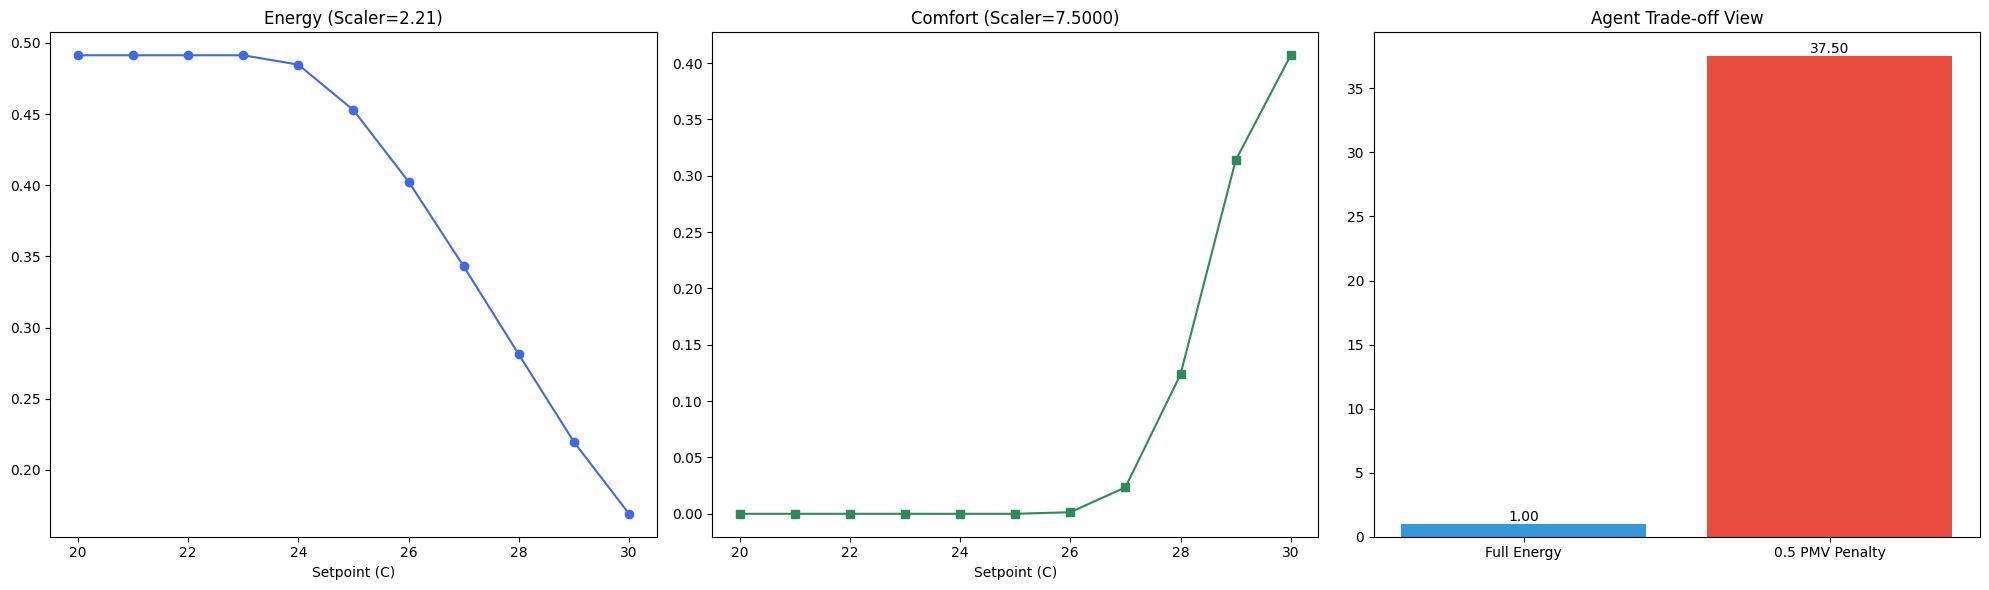

In [5]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import time

try:
    from pythermalcomfort.models import pmv_ppd_iso
except ImportError:
    pmv_ppd_iso = None

class HydronicScalerIdentifier:
    def __init__(self, config):
        self.config = config
        self.url = config.BOPTEST_URL
        self.case = config.CASE_NAME
        
        low = config.BASE_COOLING_SETPOINT - config.RESIDUAL_ACTION_SCALE
        high = config.BASE_COOLING_SETPOINT + config.RESIDUAL_ACTION_SCALE
        self.setpoint_range = np.arange(low, high + 1.0, 1.0)
        
        self.results = []
        self.PROBING_STEPS = 96 * 5 
        self.NOISE_STD = 0.25 

    def _get_clo(self, t_out_c):
        params = self.config.PHYSICAL_CONFIG['clo_dynamic_params']
        if t_out_c < params['temp_low']: return params['winter_clo']
        if t_out_c > params['temp_high']: return params['summer_clo']
        ratio = (t_out_c - params['temp_low']) / (params['temp_high'] - params['temp_low'])
        return params['winter_clo'] + ratio * (params['summer_clo'] - params['winter_clo'])

    def _safe_get(self, data, key, index=0, default=0.0):
        try:
            if key in data and data[key] is not None:
                val = data[key][index] if isinstance(data[key], list) else data[key]
                return float(val) if val is not None else default
            return default
        except:
            return default

    def run_probing(self):
        print(f"[*] 启动 Multizone Hydronic 系统标定 (Case: {self.case})")
        print(f"[*] 标定策略: 仅控制区域设定点，底层水路交由 BMS 托管")
        
        for sp in self.setpoint_range:
            print(f"    > 探测温度点: {sp} C ... ", end="", flush=True)
            tid = None
            try:
                # 1. 每次循环都重新 Select 一个新测试，确保环境纯净
                res_sel = requests.post(f"{self.url}/testcases/{self.case}/select").json()
                tid = res_sel['testid']
                
                requests.put(f"{self.url}/scenario/{tid}", json={'electricity_price': 'dynamic'})
                requests.put(f"{self.url}/step/{tid}", json={'step': self.config.CONTROL_PERIOD})
                
                # 初始化
                start_t = self.config.START_DAY * 24 * 3600
                requests.put(f"{self.url}/initialize/{tid}", json={
                    'start_time': start_t, 
                    'warmup_period': 7 * 24 * 3600
                })
                
                point_data = []
                prev_u_nz, prev_u_sz = sp, sp
                
                for step in range(self.PROBING_STEPS):
                    # 构造动作
                    u_nz = sp + np.random.normal(0, self.NOISE_STD)
                    u_sz = sp + np.random.normal(0, self.NOISE_STD)
                    
                    # === 关键修正: 移除底层水路控制，只控制 Agent 动作空间 ===
                    u_input = {
                        # Agent 的实际控制变量
                        'bms_oveTZonSetMaxNz_u': u_nz + 273.15, 'bms_oveTZonSetMaxNz_activate': 1,
                        'bms_oveTZonSetMaxSz_u': u_sz + 273.15, 'bms_oveTZonSetMaxSz_activate': 1,
                        
                        # 安全保障：确保加热设定点处于非活跃状态 (防止同时加热制冷)
                        # 将加热点设低一点 (例如 15度)，避免死区冲突
                        'bms_oveTZonSetMinNz_u': self.config.FIXED_HEATING_SETPOINT + 273.15, 'bms_oveTZonSetMinNz_activate': 1,
                        'bms_oveTZonSetMinSz_u': self.config.FIXED_HEATING_SETPOINT + 273.15, 'bms_oveTZonSetMinSz_activate': 1,
                    }
                    
                    # 获取预报
                    f_res = requests.put(f"{self.url}/forecast/{tid}", 
                                         json={'point_names': self.config.FORECAST_POINTS, 
                                               'horizon': self.config.CONTROL_PERIOD, 
                                               'interval': self.config.CONTROL_PERIOD}).json()['payload']
                    
                    price = self._safe_get(f_res, 'PriceElectricPowerDynamic')
                    occ_nz_ppl = self._safe_get(f_res, 'Occupancy[nZ]')
                    occ_sz_ppl = self._safe_get(f_res, 'Occupancy[sZ]')
                    
                    # 推进仿真
                    adv_req = requests.post(f"{self.url}/advance/{tid}", json=u_input)
                    adv_json = adv_req.json()
                    
                    # === 增强错误捕获 ===
                    if adv_req.status_code != 200 or 'payload' not in adv_json:
                        print(f"\n[Error Step {step}] BOPTEST 报错: {adv_json.get('message', 'Unknown Error')}")
                        break
                        
                    y = adv_json['payload']
                    
                    # 计算指标
                    p_sys = sum([self._safe_get(y, k) for k in [
                        'heating_cooling_reaPProCoo_y', 'heating_cooling_reaPProHea_y', 
                        'heating_cooling_reaPFcuNz_y', 'heating_cooling_reaPFcuSz_y']])
                    cost_step = (p_sys * self.config.CONTROL_PERIOD / 3600000) * price
                    
                    t_out = self._safe_get(y, 'weaSta_reaWeaTDryBul_y') - 273.15
                    clo = self._get_clo(t_out)
                    
                    # PMV
                    p_nz = 0
                    if pmv_ppd_iso and occ_nz_ppl > 0:
                        t_nz = self._safe_get(y, 'structure_reaTZonNz_y') - 273.15
                        res = pmv_ppd_iso(tdb=t_nz, tr=t_nz, vr=0.1, rh=50, met=1.1, clo=clo)
                        val = res['pmv'] if isinstance(res, dict) else res.pmv
                        p_nz = max(0, abs(val) - 0.5)**2
                    
                    p_sz = 0
                    if pmv_ppd_iso and occ_sz_ppl > 0:
                        t_sz = self._safe_get(y, 'structure_reaTZonSz_y') - 273.15
                        res = pmv_ppd_iso(tdb=t_sz, tr=t_sz, vr=0.1, rh=50, met=1.1, clo=clo)
                        val = res['pmv'] if isinstance(res, dict) else res.pmv
                        p_sz = max(0, abs(val) - 0.5)**2
                    
                    abs_du = abs(u_nz - prev_u_nz) + abs(u_sz - prev_u_sz)
                    prev_u_nz, prev_u_sz = u_nz, u_sz
                    
                    point_data.append({'cost': cost_step, 'pmv_p': p_nz + p_sz, 'abs_du': abs_du})
                
                # 循环结束，保存结果
                if point_data:
                    self.results.append({
                        'temp': sp,
                        'avg_cost': np.mean([d['cost'] for d in point_data]),
                        'avg_pmv_p': np.mean([d['pmv_p'] for d in point_data]),
                        'avg_abs_du': np.mean([d['abs_du'] for d in point_data])
                    })
                    print(f"完成 (Cost: {self.results[-1]['avg_cost']:.4f})")
                else:
                    print("无数据")

                if tid: requests.put(f"{self.url}/stop/{tid}")
                
            except Exception as e:
                print(f"失败: {e}")
                if tid: requests.put(f"{self.url}/stop/{tid}")

    # === 保持这个 Robust 逻辑不变，这是核心价值 ===
    def calculate_scalers_robust(self):
        """
        优化版 Scaler 计算：建立“舒适度防火墙”
        目标：让越界 0.1 PMV 的代价绝对超过节省任何电费带来的收益。
        """
        df = pd.DataFrame(self.results)
        if df.empty:
            return 1.0, 1.0, 1.0, df
            
        n = self.config.N_ZONES
        
        # 1. 提取基准能耗 (RBC at 25C)
        # 我们寻找最接近 25度的探测点作为归一化基准
        rbc_row = df.iloc[(df['temp']-25.0).abs().argsort()[:1]].iloc[0]
        avg_cost_per_zone = rbc_row['avg_cost'] / n
        
        # SCALER_ENERGY: 将单区域单步能耗归一化到 1.0 附近
        s_energy = 1.0 / avg_cost_per_zone if avg_cost_per_zone > 0 else 1.0
        
        # 获取 Config 中的基础权重
        w_energy = self.config.REWARD_WEIGHTS.get('w_energy', 1.0)
        w_comfort = self.config.REWARD_WEIGHTS.get('w_comfort', 20.0)
        w_smooth = self.config.REWARD_WEIGHTS.get('w_smooth', 0.1)
        
        # === 2. SCALER_COMFORT 计算 (核心逻辑) ===
        # 物理目标：
        # 如果 PMV 达到 0.6 (即超限 0.1)，我们希望该项的惩罚值 
        # 等于甚至大于 整个能耗项的权重值 (w_energy * 1.0)。
        # 这确保了代理为了节省 10% 电费而让 PMV 偏移 0.1 是“绝对亏本”的。
        
        violation_point = 0.1  # PMV = 0.6
        # 我们设定在 0.1 偏移时，产生的 Penalty 必须能抵消 1.5 倍的基准能耗奖励
        target_penalty_val = 1.5 * w_energy 
        
        # 基于平方项计算原始惩罚: (0.6 - 0.5)^2 = 0.01
        raw_penalty_at_point = violation_point ** 2 
        
        if w_comfort > 0:
            # 公式: w_comfort * s_comfort * raw_penalty = target_penalty_val
            s_comfort = target_penalty_val / (raw_penalty_at_point * w_comfort)
        else:
            s_comfort = 0.0
            
        # === 3. SCALER_SMOOTH 计算 ===
        # 物理目标：让设定点剧烈跳动 1K 的代价等于能效收益的 5%
        avg_abs_du_per_zone = rbc_row['avg_abs_du'] / n
        target_smooth_penalty = 0.05 * w_energy
        
        if avg_abs_du_per_zone > 0 and w_smooth > 0:
            s_smooth = target_smooth_penalty / (avg_abs_du_per_zone * w_smooth)
        else:
            s_smooth = 1.0

        # 打印诊断信息辅助确认
        print(f"\n[Calibration Diagnostic]")
        print(f"Base Energy Reward (normalized): {w_energy:.2f}")
        print(f"Penalty at PMV 0.6 (Boundary + 0.1): {target_penalty_val:.2f}")
        print(f"Penalty at PMV 1.0 (Severe): { ( (1.0-0.5)**2 ) * s_comfort * w_comfort:.2f}")
        
        return s_energy, s_comfort, s_smooth, df

    def plot_results(self, df, s_en, s_cm, s_sm):
        if df.empty: return
        fig, axes = plt.subplots(1, 3, figsize=(20, 6))
        n = self.config.N_ZONES
        
        axes[0].plot(df['temp'], df['avg_cost'] / n, 'o-', color='royalblue')
        axes[0].set_title(f"Energy (Scaler={s_en:.2f})")
        axes[0].set_xlabel("Setpoint (C)")
        
        axes[1].plot(df['temp'], df['avg_pmv_p'] / n, 's-', color='seagreen')
        axes[1].set_title(f"Comfort (Scaler={s_cm:.4f})")
        axes[1].set_xlabel("Setpoint (C)")

        w_en = self.config.REWARD_WEIGHTS.get('w_energy', 1.0)
        w_cm = self.config.REWARD_WEIGHTS.get('w_comfort', 20.0)
        best_idx = (df['temp'] - 25.0).abs().idxmin()
        rbc_row = df.loc[best_idx]
        
        val_en_full = (rbc_row['avg_cost'] / n) * s_en * w_en 
        val_cm_bad = (0.5**2) * s_cm * w_cm                  
        
        bars = axes[2].bar(['Full Energy', '0.5 PMV Penalty'], [val_en_full, val_cm_bad], color=['#3498db', '#e74c3c'])
        axes[2].set_title("Agent Trade-off View")
        axes[2].bar_label(bars, fmt='%.2f')
        
        plt.tight_layout()
        plt.savefig("calibration_multizone_hydronic_robust.png", dpi=300)
        plt.show()

if __name__ == "__main__":
    try:
        identifier = HydronicScalerIdentifier(config)
        identifier.run_probing()
        s_en, s_cm, s_sm, df = identifier.calculate_scalers_robust()
        print(f"\nSCALER_ENERGY: {s_en:.6f}\nSCALER_COMFORT: {s_cm:.6f}\nSCALER_SMOOTH: {s_sm:.6f}")
        identifier.plot_results(df, s_en, s_cm, s_sm)
    except NameError:
        print("请确保 'config' 对象已定义")

In [ ]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import time
import traceback

try:
    from pythermalcomfort.models import pmv_ppd_iso
except ImportError:
    pmv_ppd_iso = None

class HydronicScalerIdentifier:
    def __init__(self, config):
        self.config = config
        self.url = config.BOPTEST_URL
        self.case = config.CASE_NAME
        
        # 1. 动态计算探测范围
        low = config.BASE_COOLING_SETPOINT - config.RESIDUAL_ACTION_SCALE
        high = config.BASE_COOLING_SETPOINT + config.RESIDUAL_ACTION_SCALE
        self.setpoint_range = np.arange(low, high + 1.0, 1.0)
        
        self.results = []
        self.PROBING_STEPS = 96 * 5 
        self.NOISE_STD = 0.25 

    def _get_clo(self, t_out_c):
        params = self.config.PHYSICAL_CONFIG['clo_dynamic_params']
        if t_out_c < params['temp_low']: return params['winter_clo']
        if t_out_c > params['temp_high']: return params['summer_clo']
        ratio = (t_out_c - params['temp_low']) / (params['temp_high'] - params['temp_low'])
        return params['winter_clo'] + ratio * (params['summer_clo'] - params['winter_clo'])

    def _safe_get(self, data, key, index=0, default=0.0):
        """核心修复：安全提取 API 返回的数值"""
        try:
            if key in data and data[key] is not None:
                val = data[key][index] if isinstance(data[key], list) else data[key]
                return float(val) if val is not None else default
            return default
        except:
            return default

    def run_probing(self):
        print(f"[*] 启动 Multizone Hydronic 系统标定 (Case: {self.case})")
        
        for sp in self.setpoint_range:
            print(f"    > 探测温度点: {sp} C ... ", end="", flush=True)
            
            try:
                res_sel = requests.post(f"{self.url}/testcases/{self.case}/select").json()
                tid = res_sel['testid']
                
                requests.put(f"{self.url}/scenario/{tid}", json={'electricity_price': 'dynamic'})
                requests.put(f"{self.url}/step/{tid}", json={'step': self.config.CONTROL_PERIOD})
                
                start_t = self.config.START_DAY * 24 * 3600
                requests.put(f"{self.url}/initialize/{tid}", json={
                    'start_time': start_t, 
                    'warmup_period': 7 * 24 * 3600
                })
                
                point_data = []
                prev_u_nz, prev_u_sz = sp, sp
                
                for step in range(self.PROBING_STEPS):
                    # 1. 构造带噪声的动作
                    u_nz = sp + np.random.normal(0, self.NOISE_STD)
                    u_sz = sp + np.random.normal(0, self.NOISE_STD)
                    
                    u_input = {
                        'bms_oveTZonSetMaxNz_u': u_nz + 273.15, 'bms_oveTZonSetMaxNz_activate': 1,
                        'bms_oveTZonSetMaxSz_u': u_sz + 273.15, 'bms_oveTZonSetMaxSz_activate': 1,
                        'bms_oveTZonSetMinNz_u': self.config.FIXED_HEATING_SETPOINT + 273.15, 'bms_oveTZonSetMinNz_activate': 1,
                        'bms_oveTZonSetMinSz_u': self.config.FIXED_HEATING_SETPOINT + 273.15, 'bms_oveTZonSetMinSz_activate': 1,
                        # --- 新增：固定供水温度控制 ---
                        # 1. 生产侧 (Plant)
                        'bms_oveTProHea_u': 318.15, 'bms_oveTProHea_activate': 1, # 热泵固定 45C
                        'bms_oveTProCoo_u': 280.15, 'bms_oveTProCoo_activate': 1, # 冷机固定 7C
                        
                        # 2. 末端分配侧 (Emission/FCU)
                        # 固定供水温度可以覆盖掉模型内置的“室外温度补偿曲线”
                        'bms_oveTSupEmiHeaNz_u': 313.15, 'bms_oveTSupEmiHeaNz_activate': 1, # 北区加热 40C
                        'bms_oveTSupEmiHeaSz_u': 313.15, 'bms_oveTSupEmiHeaSz_activate': 1, # 南区加热 40C
                        'bms_oveTSupEmiCooNz_u': 283.15, 'bms_oveTSupEmiCooNz_activate': 1, # 北区冷却 10C
                        'bms_oveTSupEmiCooSz_u': 283.15, 'bms_oveTSupEmiCooSz_activate': 1, # 南区冷却 10C
                    }
                    
                    # 2. 获取预报 (Horizon 增加到 1 个步长以防空值)
                    f_res = requests.put(f"{self.url}/forecast/{tid}", 
                                         json={'point_names': self.config.FORECAST_POINTS, 
                                               'horizon': self.config.CONTROL_PERIOD, 
                                               'interval': self.config.CONTROL_PERIOD}).json()['payload']
                    
                    # 使用安全提取方法
                    price = self._safe_get(f_res, 'PriceElectricPowerDynamic')
                    occ_nz_ppl = self._safe_get(f_res, 'Occupancy[nZ]')
                    occ_sz_ppl = self._safe_get(f_res, 'Occupancy[sZ]')
                    
                    # 3. 推进环境
                    adv_res = requests.post(f"{self.url}/advance/{tid}", json=u_input).json()
                    y = adv_res['payload']
                    
                    if y is None: continue # 跳过空响应

                    # 4. 能耗计算
                    p_sys = sum([self._safe_get(y, k, index=None) for k in ['heating_cooling_reaPProCoo_y', 
                                                                          'heating_cooling_reaPProHea_y', 
                                                                          'heating_cooling_reaPFcuNz_y', 
                                                                          'heating_cooling_reaPFcuSz_y']])
                    cost_step = (p_sys * self.config.CONTROL_PERIOD / 3600000) * price
                    
                    # 5. PMV 惩罚
                    t_out = self._safe_get(y, 'weaSta_reaWeaTDryBul_y', index=None) - 273.15
                    clo = self._get_clo(t_out)
                    
                    p_nz = 0
                    if pmv_ppd_iso and occ_nz_ppl > 0:
                        t_nz = self._safe_get(y, 'structure_reaTZonNz_y', index=None) - 273.15
                        res = pmv_ppd_iso(tdb=t_nz, tr=t_nz, vr=0.1, rh=50, met=1.1, clo=clo)
                        p_nz = max(0, abs(res['pmv'] if isinstance(res, dict) else res.pmv) - 0.5)**2
                    
                    p_sz = 0
                    if pmv_ppd_iso and occ_sz_ppl > 0:
                        t_sz = self._safe_get(y, 'structure_reaTZonSz_y', index=None) - 273.15
                        res = pmv_ppd_iso(tdb=t_sz, tr=t_sz, vr=0.1, rh=50, met=1.1, clo=clo)
                        p_sz = max(0, abs(res['pmv'] if isinstance(res, dict) else res.pmv) - 0.5)**2
                    
                    abs_du = abs(u_nz - prev_u_nz) + abs(u_sz - prev_u_sz)
                    prev_u_nz, prev_u_sz = u_nz, u_sz
                    
                    point_data.append({'cost': cost_step, 'pmv_p': p_nz + p_sz, 'abs_du': abs_du})
                
                self.results.append({
                    'temp': sp,
                    'avg_cost': np.mean([d['cost'] for d in point_data]) if point_data else 0,
                    'avg_pmv_p': np.mean([d['pmv_p'] for d in point_data]) if point_data else 0,
                    'avg_abs_du': np.mean([d['abs_du'] for d in point_data]) if point_data else 0
                })
                requests.put(f"{self.url}/stop/{tid}")
                print(f"完成")
            except Exception as e:
                print(f"失败: {e}")
                # traceback.print_exc()

    def calculate_scalers(self):
        df = pd.DataFrame(self.results)
        n = self.config.N_ZONES
        # 查找最接近 25C 的行
        rbc_row = df.iloc[(df['temp']-25.0).abs().argsort()[:1]].iloc[0]
        
        avg_cost_per_zone = rbc_row['avg_cost'] / n
        s_energy = 1.0 / avg_cost_per_zone if avg_cost_per_zone > 0 else 1.0
        s_comfort = (s_energy * (0.10 * avg_cost_per_zone)) / 0.01
        
        total_ideal_budget_per_zone = (s_energy * avg_cost_per_zone) + (s_comfort * 0.01)
        avg_abs_du_per_zone = rbc_row['avg_abs_du'] / n
        s_smooth = (0.05 * total_ideal_budget_per_zone) / avg_abs_du_per_zone if avg_abs_du_per_zone > 0 else 1.0
        
        return s_energy, s_comfort, s_smooth, df

    def plot_results(self, df, s_en, s_cm, s_sm):
        fig, axes = plt.subplots(1, 3, figsize=(20, 6))
        n = self.config.N_ZONES
        axes[0].plot(df['temp'], df['avg_cost'] / n, 'o-', color='royalblue')
        axes[0].set_title("Avg Cost per Zone (Hydronic)")
        axes[0].set_xlabel("Setpoint (C)")
        
        axes[1].plot(df['temp'], df['avg_pmv_p'] / n, 's-', color='seagreen')
        axes[1].set_title("Avg PMV Penalty per Zone")
        axes[1].set_xlabel("Setpoint (C)")
        
        # 柱状图
        rbc_row = df.iloc[(df['temp']-25.0).abs().argsort()[:1]].iloc[0]
        v_en = (rbc_row['avg_cost'] / n) * s_en
        v_cm = 0.01 * s_cm
        v_sm = (rbc_row['avg_abs_du'] / n) * s_sm
        values = [v_en, v_cm, v_sm]
        axes[2].bar(['Energy', 'Comfort', 'Smooth'], values, color=['#3498db', '#2ecc71', '#e74c3c'])
        axes[2].set_title("Target Component Distribution")
        
        plt.tight_layout()
        plt.savefig("calibration_multizone_hydronic_2zone.png", dpi=300)
        plt.show()

if __name__ == "__main__":
    identifier = HydronicScalerIdentifier(config)
    identifier.run_probing()
    s_en, s_cm, s_sm, df = identifier.calculate_scalers()
    print(f"\nSCALER_ENERGY: {s_en:.6f}\nSCALER_COMFORT: {s_cm:.6f}\nSCALER_SMOOTH: {s_sm:.6f}")
    identifier.plot_results(df, s_en, s_cm, s_sm)

[*] 启动 Multizone Hydronic 系统标定 (Case: multizone_office_simple_hydronic)
    > 探测温度点: 20.0 C ... 

[*] 启动 Multizone Hydronic 系统标定 (Case: multizone_office_simple_hydronic)
    > 探测温度点: 20.0 C ... 完成
    > 探测温度点: 21.0 C ... 完成
    > 探测温度点: 22.0 C ... 完成
    > 探测温度点: 23.0 C ... 完成
    > 探测温度点: 24.0 C ... 完成
    > 探测温度点: 25.0 C ... 完成
    > 探测温度点: 26.0 C ... 完成
    > 探测温度点: 27.0 C ... 完成
    > 探测温度点: 28.0 C ... 完成
    > 探测温度点: 29.0 C ... 完成
    > 探测温度点: 30.0 C ... 完成

SCALER_ENERGY: 2.208483
SCALER_COMFORT: 10.000000
SCALER_SMOOTH: 0.193159


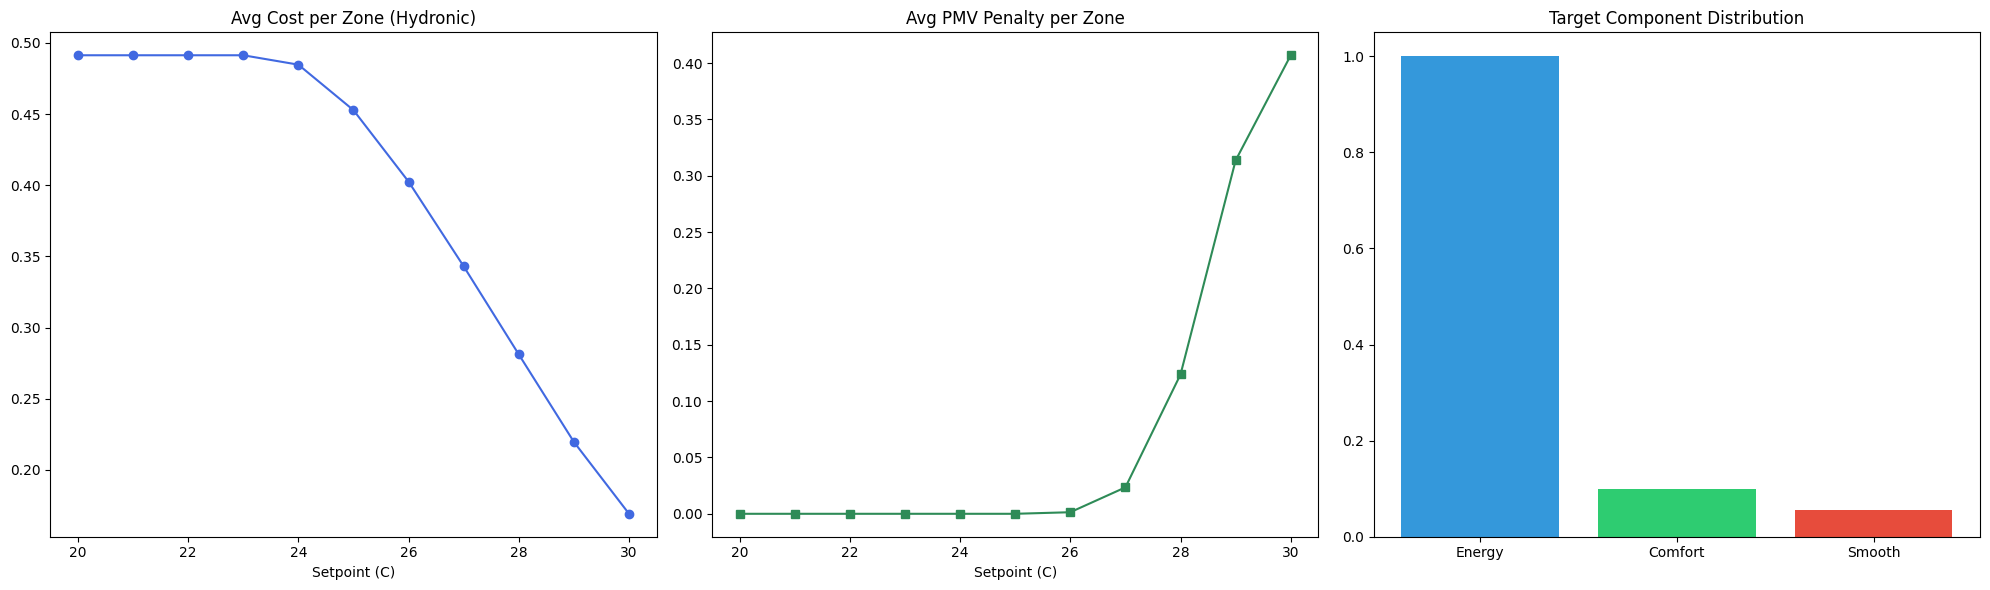

In [7]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import time
import traceback

try:
    from pythermalcomfort.models import pmv_ppd_iso
except ImportError:
    pmv_ppd_iso = None

class HydronicScalerIdentifier:
    def __init__(self, config):
        self.config = config
        self.url = config.BOPTEST_URL
        self.case = config.CASE_NAME
        
        # 1. 动态计算探测范围
        low = config.BASE_COOLING_SETPOINT - config.RESIDUAL_ACTION_SCALE
        high = config.BASE_COOLING_SETPOINT + config.RESIDUAL_ACTION_SCALE
        self.setpoint_range = np.arange(low, high + 1.0, 1.0)
        
        self.results = []
        self.PROBING_STEPS = 96 * 5 
        self.NOISE_STD = 0.25 

    def _get_clo(self, t_out_c):
        params = self.config.PHYSICAL_CONFIG['clo_dynamic_params']
        if t_out_c < params['temp_low']: return params['winter_clo']
        if t_out_c > params['temp_high']: return params['summer_clo']
        ratio = (t_out_c - params['temp_low']) / (params['temp_high'] - params['temp_low'])
        return params['winter_clo'] + ratio * (params['summer_clo'] - params['winter_clo'])

    def _safe_get(self, data, key, index=0, default=0.0):
        """核心修复：安全提取 API 返回的数值"""
        try:
            if key in data and data[key] is not None:
                val = data[key][index] if isinstance(data[key], list) else data[key]
                return float(val) if val is not None else default
            return default
        except:
            return default

    def run_probing(self):
        print(f"[*] 启动 Multizone Hydronic 系统标定 (Case: {self.case})")
        
        for sp in self.setpoint_range:
            print(f"    > 探测温度点: {sp} C ... ", end="", flush=True)
            
            try:
                res_sel = requests.post(f"{self.url}/testcases/{self.case}/select").json()
                tid = res_sel['testid']
                
                requests.put(f"{self.url}/scenario/{tid}", json={'electricity_price': 'dynamic'})
                requests.put(f"{self.url}/step/{tid}", json={'step': self.config.CONTROL_PERIOD})
                
                start_t = self.config.START_DAY * 24 * 3600
                requests.put(f"{self.url}/initialize/{tid}", json={
                    'start_time': start_t, 
                    'warmup_period': 7 * 24 * 3600
                })
                
                point_data = []
                prev_u_nz, prev_u_sz = sp, sp
                
                for step in range(self.PROBING_STEPS):
                    # 1. 构造带噪声的动作
                    u_nz = sp + np.random.normal(0, self.NOISE_STD)
                    u_sz = sp + np.random.normal(0, self.NOISE_STD)
                    
                    u_input = {
                        'bms_oveTZonSetMaxNz_u': u_nz + 273.15, 'bms_oveTZonSetMaxNz_activate': 1,
                        'bms_oveTZonSetMaxSz_u': u_sz + 273.15, 'bms_oveTZonSetMaxSz_activate': 1,
                        'bms_oveTZonSetMinNz_u': self.config.FIXED_HEATING_SETPOINT + 273.15, 'bms_oveTZonSetMinNz_activate': 1,
                        'bms_oveTZonSetMinSz_u': self.config.FIXED_HEATING_SETPOINT + 273.15, 'bms_oveTZonSetMinSz_activate': 1,
                        # --- 新增：固定供水温度控制 ---
                        # # 1. 生产侧 (Plant)
                        # 'bms_oveTProHea_u': 318.15, 'bms_oveTProHea_activate': 1, # 热泵固定 45C
                        # 'bms_oveTProCoo_u': 280.15, 'bms_oveTProCoo_activate': 1, # 冷机固定 7C
                        
                        # # 2. 末端分配侧 (Emission/FCU)
                        # # 固定供水温度可以覆盖掉模型内置的“室外温度补偿曲线”
                        # 'bms_oveTSupEmiHeaNz_u': 313.15, 'bms_oveTSupEmiHeaNz_activate': 1, # 北区加热 40C
                        # 'bms_oveTSupEmiHeaSz_u': 313.15, 'bms_oveTSupEmiHeaSz_activate': 1, # 南区加热 40C
                        # 'bms_oveTSupEmiCooNz_u': 283.15, 'bms_oveTSupEmiCooNz_activate': 1, # 北区冷却 10C
                        # 'bms_oveTSupEmiCooSz_u': 283.15, 'bms_oveTSupEmiCooSz_activate': 1, # 南区冷却 10C
                    }
                    
                    # 2. 获取预报 (Horizon 增加到 1 个步长以防空值)
                    f_res = requests.put(f"{self.url}/forecast/{tid}", 
                                         json={'point_names': self.config.FORECAST_POINTS, 
                                               'horizon': self.config.CONTROL_PERIOD, 
                                               'interval': self.config.CONTROL_PERIOD}).json()['payload']
                    
                    # 使用安全提取方法
                    price = self._safe_get(f_res, 'PriceElectricPowerDynamic')
                    occ_nz_ppl = self._safe_get(f_res, 'Occupancy[nZ]')
                    occ_sz_ppl = self._safe_get(f_res, 'Occupancy[sZ]')
                    
                    # 3. 推进环境
                    adv_res = requests.post(f"{self.url}/advance/{tid}", json=u_input).json()
                    y = adv_res['payload']
                    
                    if y is None: continue # 跳过空响应

                    # 4. 能耗计算
                    p_sys = sum([self._safe_get(y, k, index=None) for k in ['heating_cooling_reaPProCoo_y', 
                                                                          'heating_cooling_reaPProHea_y', 
                                                                          'heating_cooling_reaPFcuNz_y', 
                                                                          'heating_cooling_reaPFcuSz_y']])
                    cost_step = (p_sys * self.config.CONTROL_PERIOD / 3600000) * price
                    
                    # 5. PMV 惩罚
                    t_out = self._safe_get(y, 'weaSta_reaWeaTDryBul_y', index=None) - 273.15
                    clo = self._get_clo(t_out)
                    
                    p_nz = 0
                    if pmv_ppd_iso and occ_nz_ppl > 0:
                        t_nz = self._safe_get(y, 'structure_reaTZonNz_y', index=None) - 273.15
                        res = pmv_ppd_iso(tdb=t_nz, tr=t_nz, vr=0.1, rh=50, met=1.1, clo=clo)
                        p_nz = max(0, abs(res['pmv'] if isinstance(res, dict) else res.pmv) - 0.5)**2
                    
                    p_sz = 0
                    if pmv_ppd_iso and occ_sz_ppl > 0:
                        t_sz = self._safe_get(y, 'structure_reaTZonSz_y', index=None) - 273.15
                        res = pmv_ppd_iso(tdb=t_sz, tr=t_sz, vr=0.1, rh=50, met=1.1, clo=clo)
                        p_sz = max(0, abs(res['pmv'] if isinstance(res, dict) else res.pmv) - 0.5)**2
                    
                    abs_du = abs(u_nz - prev_u_nz) + abs(u_sz - prev_u_sz)
                    prev_u_nz, prev_u_sz = u_nz, u_sz
                    
                    point_data.append({'cost': cost_step, 'pmv_p': p_nz + p_sz, 'abs_du': abs_du})
                
                self.results.append({
                    'temp': sp,
                    'avg_cost': np.mean([d['cost'] for d in point_data]) if point_data else 0,
                    'avg_pmv_p': np.mean([d['pmv_p'] for d in point_data]) if point_data else 0,
                    'avg_abs_du': np.mean([d['abs_du'] for d in point_data]) if point_data else 0
                })
                requests.put(f"{self.url}/stop/{tid}")
                print(f"完成")
            except Exception as e:
                print(f"失败: {e}")
                # traceback.print_exc()

    def calculate_scalers(self):
        df = pd.DataFrame(self.results)
        n = self.config.N_ZONES
        # 查找最接近 25C 的行
        rbc_row = df.iloc[(df['temp']-25.0).abs().argsort()[:1]].iloc[0]
        
        avg_cost_per_zone = rbc_row['avg_cost'] / n
        s_energy = 1.0 / avg_cost_per_zone if avg_cost_per_zone > 0 else 1.0
        s_comfort = (s_energy * (0.10 * avg_cost_per_zone)) / 0.01
        
        total_ideal_budget_per_zone = (s_energy * avg_cost_per_zone) + (s_comfort * 0.01)
        avg_abs_du_per_zone = rbc_row['avg_abs_du'] / n
        s_smooth = (0.05 * total_ideal_budget_per_zone) / avg_abs_du_per_zone if avg_abs_du_per_zone > 0 else 1.0
        
        return s_energy, s_comfort, s_smooth, df

    def plot_results(self, df, s_en, s_cm, s_sm):
        fig, axes = plt.subplots(1, 3, figsize=(20, 6))
        n = self.config.N_ZONES
        axes[0].plot(df['temp'], df['avg_cost'] / n, 'o-', color='royalblue')
        axes[0].set_title("Avg Cost per Zone (Hydronic)")
        axes[0].set_xlabel("Setpoint (C)")
        
        axes[1].plot(df['temp'], df['avg_pmv_p'] / n, 's-', color='seagreen')
        axes[1].set_title("Avg PMV Penalty per Zone")
        axes[1].set_xlabel("Setpoint (C)")
        
        # 柱状图
        rbc_row = df.iloc[(df['temp']-25.0).abs().argsort()[:1]].iloc[0]
        v_en = (rbc_row['avg_cost'] / n) * s_en
        v_cm = 0.01 * s_cm
        v_sm = (rbc_row['avg_abs_du'] / n) * s_sm
        values = [v_en, v_cm, v_sm]
        axes[2].bar(['Energy', 'Comfort', 'Smooth'], values, color=['#3498db', '#2ecc71', '#e74c3c'])
        axes[2].set_title("Target Component Distribution")
        
        plt.tight_layout()
        plt.savefig("calibration_multizone_hydronic_2zone.png", dpi=300)
        plt.show()

if __name__ == "__main__":
    identifier = HydronicScalerIdentifier(config)
    identifier.run_probing()
    s_en, s_cm, s_sm, df = identifier.calculate_scalers()
    print(f"\nSCALER_ENERGY: {s_en:.6f}\nSCALER_COMFORT: {s_cm:.6f}\nSCALER_SMOOTH: {s_sm:.6f}")
    identifier.plot_results(df, s_en, s_cm, s_sm)

[*] 启动 Multizone Hydronic 系统标定 (Case: multizone_office_simple_hydronic)
    > 探测温度点: 20.0 C ... 完成
    > 探测温度点: 21.0 C ... 完成
    > 探测温度点: 22.0 C ... 完成
    > 探测温度点: 23.0 C ... 完成
    > 探测温度点: 24.0 C ... 完成
    > 探测温度点: 25.0 C ... 完成
    > 探测温度点: 26.0 C ... 完成
    > 探测温度点: 27.0 C ... 完成
    > 探测温度点: 28.0 C ... 完成
    > 探测温度点: 29.0 C ... 完成
    > 探测温度点: 30.0 C ... 完成

SCALER_ENERGY: 2.882186
SCALER_COMFORT: 10.000000
SCALER_SMOOTH: 0.191645


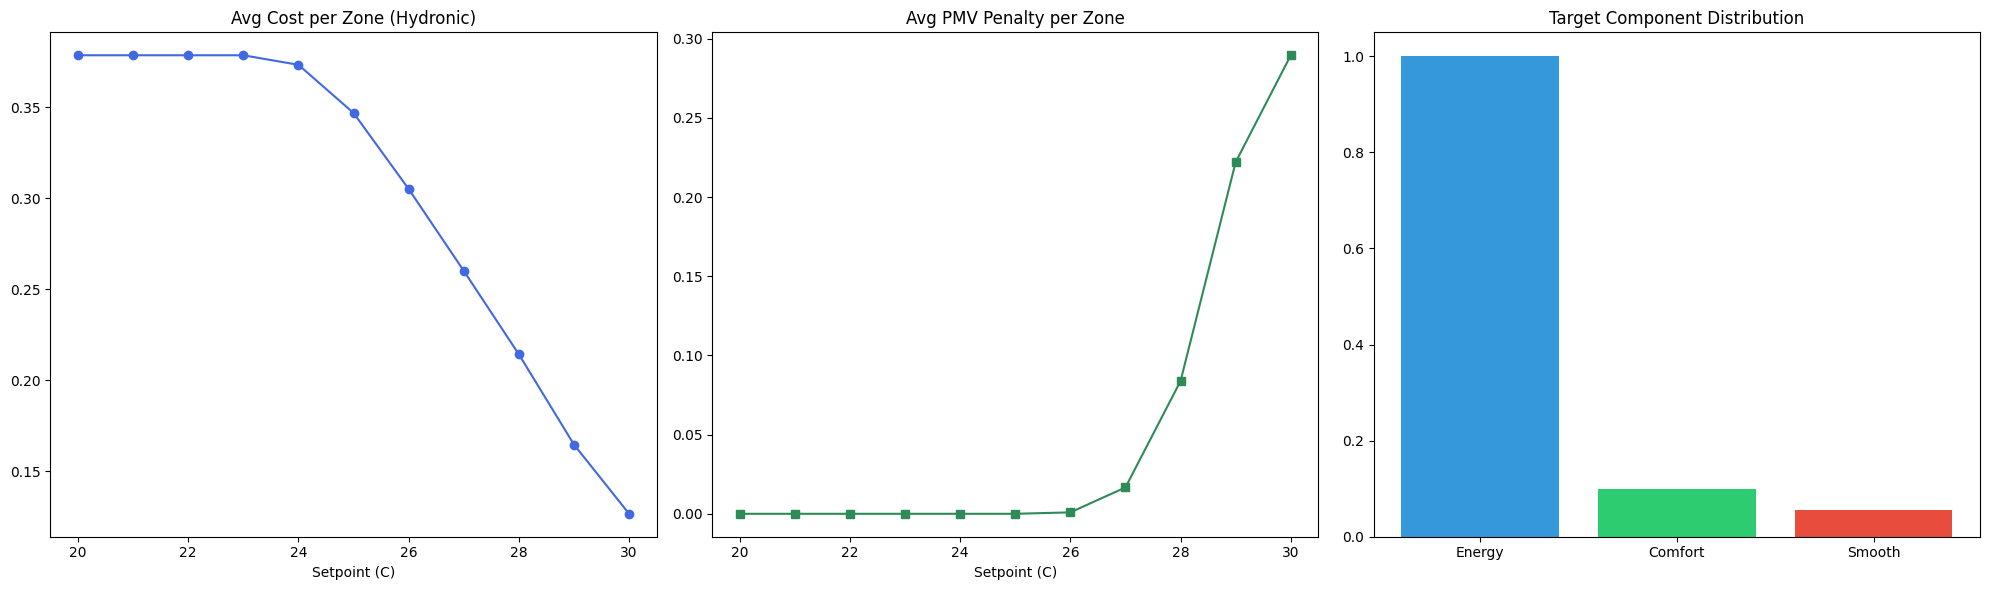

In [4]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import time
import traceback

try:
    from pythermalcomfort.models import pmv_ppd_iso
except ImportError:
    pmv_ppd_iso = None

class HydronicScalerIdentifier:
    def __init__(self, config):
        self.config = config
        self.url = config.BOPTEST_URL
        self.case = config.CASE_NAME
        
        # 1. 动态计算探测范围
        low = config.BASE_COOLING_SETPOINT - config.RESIDUAL_ACTION_SCALE
        high = config.BASE_COOLING_SETPOINT + config.RESIDUAL_ACTION_SCALE
        self.setpoint_range = np.arange(low, high + 1.0, 1.0)
        
        self.results = []
        self.PROBING_STEPS = 96 * 7 
        self.NOISE_STD = 0.25 

    def _get_clo(self, t_out_c):
        params = self.config.PHYSICAL_CONFIG['clo_dynamic_params']
        if t_out_c < params['temp_low']: return params['winter_clo']
        if t_out_c > params['temp_high']: return params['summer_clo']
        ratio = (t_out_c - params['temp_low']) / (params['temp_high'] - params['temp_low'])
        return params['winter_clo'] + ratio * (params['summer_clo'] - params['winter_clo'])

    def _safe_get(self, data, key, index=0, default=0.0):
        """核心修复：安全提取 API 返回的数值"""
        try:
            if key in data and data[key] is not None:
                val = data[key][index] if isinstance(data[key], list) else data[key]
                return float(val) if val is not None else default
            return default
        except:
            return default

    def run_probing(self):
        print(f"[*] 启动 Multizone Hydronic 系统标定 (Case: {self.case})")
        
        for sp in self.setpoint_range:
            print(f"    > 探测温度点: {sp} C ... ", end="", flush=True)
            
            try:
                res_sel = requests.post(f"{self.url}/testcases/{self.case}/select").json()
                tid = res_sel['testid']
                
                requests.put(f"{self.url}/scenario/{tid}", json={'electricity_price': 'dynamic'})
                requests.put(f"{self.url}/step/{tid}", json={'step': self.config.CONTROL_PERIOD})
                
                start_t = self.config.START_DAY * 24 * 3600
                requests.put(f"{self.url}/initialize/{tid}", json={
                    'start_time': start_t, 
                    'warmup_period': 7 * 24 * 3600
                })
                
                point_data = []
                prev_u_nz, prev_u_sz = sp, sp
                
                for step in range(self.PROBING_STEPS):
                    # 1. 构造带噪声的动作
                    u_nz = sp + np.random.normal(0, self.NOISE_STD)
                    u_sz = sp + np.random.normal(0, self.NOISE_STD)
                    
                    u_input = {
                        'bms_oveTZonSetMaxNz_u': u_nz + 273.15, 'bms_oveTZonSetMaxNz_activate': 1,
                        'bms_oveTZonSetMaxSz_u': u_sz + 273.15, 'bms_oveTZonSetMaxSz_activate': 1,
                        'bms_oveTZonSetMinNz_u': self.config.FIXED_HEATING_SETPOINT + 273.15, 'bms_oveTZonSetMinNz_activate': 1,
                        'bms_oveTZonSetMinSz_u': self.config.FIXED_HEATING_SETPOINT + 273.15, 'bms_oveTZonSetMinSz_activate': 1,
                    }
                    
                    # 2. 获取预报 (Horizon 增加到 1 个步长以防空值)
                    f_res = requests.put(f"{self.url}/forecast/{tid}", 
                                         json={'point_names': self.config.FORECAST_POINTS, 
                                               'horizon': self.config.CONTROL_PERIOD, 
                                               'interval': self.config.CONTROL_PERIOD}).json()['payload']
                    
                    # 使用安全提取方法
                    price = self._safe_get(f_res, 'PriceElectricPowerDynamic')
                    occ_nz_ppl = self._safe_get(f_res, 'Occupancy[nZ]')
                    occ_sz_ppl = self._safe_get(f_res, 'Occupancy[sZ]')
                    
                    # 3. 推进环境
                    adv_res = requests.post(f"{self.url}/advance/{tid}", json=u_input).json()
                    y = adv_res['payload']
                    
                    if y is None: continue # 跳过空响应

                    # 4. 能耗计算
                    p_sys = sum([self._safe_get(y, k, index=None) for k in ['heating_cooling_reaPProCoo_y', 
                                                                          'heating_cooling_reaPProHea_y', 
                                                                          'heating_cooling_reaPFcuNz_y', 
                                                                          'heating_cooling_reaPFcuSz_y']])
                    cost_step = (p_sys * self.config.CONTROL_PERIOD / 3600000) * price
                    
                    # 5. PMV 惩罚
                    t_out = self._safe_get(y, 'weaSta_reaWeaTDryBul_y', index=None) - 273.15
                    clo = self._get_clo(t_out)
                    
                    p_nz = 0
                    if pmv_ppd_iso and occ_nz_ppl > 0:
                        t_nz = self._safe_get(y, 'structure_reaTZonNz_y', index=None) - 273.15
                        res = pmv_ppd_iso(tdb=t_nz, tr=t_nz, vr=0.1, rh=50, met=1.1, clo=clo)
                        p_nz = max(0, abs(res['pmv'] if isinstance(res, dict) else res.pmv) - 0.5)**2
                    
                    p_sz = 0
                    if pmv_ppd_iso and occ_sz_ppl > 0:
                        t_sz = self._safe_get(y, 'structure_reaTZonSz_y', index=None) - 273.15
                        res = pmv_ppd_iso(tdb=t_sz, tr=t_sz, vr=0.1, rh=50, met=1.1, clo=clo)
                        p_sz = max(0, abs(res['pmv'] if isinstance(res, dict) else res.pmv) - 0.5)**2
                    
                    abs_du = abs(u_nz - prev_u_nz) + abs(u_sz - prev_u_sz)
                    prev_u_nz, prev_u_sz = u_nz, u_sz
                    
                    point_data.append({'cost': cost_step, 'pmv_p': p_nz + p_sz, 'abs_du': abs_du})
                
                self.results.append({
                    'temp': sp,
                    'avg_cost': np.mean([d['cost'] for d in point_data]) if point_data else 0,
                    'avg_pmv_p': np.mean([d['pmv_p'] for d in point_data]) if point_data else 0,
                    'avg_abs_du': np.mean([d['abs_du'] for d in point_data]) if point_data else 0
                })
                requests.put(f"{self.url}/stop/{tid}")
                print(f"完成")
            except Exception as e:
                print(f"失败: {e}")
                # traceback.print_exc()

    def calculate_scalers(self):
        df = pd.DataFrame(self.results)
        n = self.config.N_ZONES
        # 查找最接近 25C 的行
        rbc_row = df.iloc[(df['temp']-25.0).abs().argsort()[:1]].iloc[0]
        
        avg_cost_per_zone = rbc_row['avg_cost'] / n
        s_energy = 1.0 / avg_cost_per_zone if avg_cost_per_zone > 0 else 1.0
        s_comfort = (s_energy * (0.10 * avg_cost_per_zone)) / 0.01
        
        total_ideal_budget_per_zone = (s_energy * avg_cost_per_zone) + (s_comfort * 0.01)
        avg_abs_du_per_zone = rbc_row['avg_abs_du'] / n
        s_smooth = (0.05 * total_ideal_budget_per_zone) / avg_abs_du_per_zone if avg_abs_du_per_zone > 0 else 1.0
        
        return s_energy, s_comfort, s_smooth, df

    def plot_results(self, df, s_en, s_cm, s_sm):
        fig, axes = plt.subplots(1, 3, figsize=(20, 6))
        n = self.config.N_ZONES
        axes[0].plot(df['temp'], df['avg_cost'] / n, 'o-', color='royalblue')
        axes[0].set_title("Avg Cost per Zone (Hydronic)")
        axes[0].set_xlabel("Setpoint (C)")
        
        axes[1].plot(df['temp'], df['avg_pmv_p'] / n, 's-', color='seagreen')
        axes[1].set_title("Avg PMV Penalty per Zone")
        axes[1].set_xlabel("Setpoint (C)")
        
        # 柱状图
        rbc_row = df.iloc[(df['temp']-25.0).abs().argsort()[:1]].iloc[0]
        v_en = (rbc_row['avg_cost'] / n) * s_en
        v_cm = 0.01 * s_cm
        v_sm = (rbc_row['avg_abs_du'] / n) * s_sm
        values = [v_en, v_cm, v_sm]
        axes[2].bar(['Energy', 'Comfort', 'Smooth'], values, color=['#3498db', '#2ecc71', '#e74c3c'])
        axes[2].set_title("Target Component Distribution")
        
        plt.tight_layout()
        plt.savefig("calibration_multizone_hydronic_2zone.png", dpi=300)
        plt.show()

if __name__ == "__main__":
    identifier = HydronicScalerIdentifier(config)
    identifier.run_probing()
    s_en, s_cm, s_sm, df = identifier.calculate_scalers()
    print(f"\nSCALER_ENERGY: {s_en:.6f}\nSCALER_COMFORT: {s_cm:.6f}\nSCALER_SMOOTH: {s_sm:.6f}")
    identifier.plot_results(df, s_en, s_cm, s_sm)

# RBC

[System] pythermalcomfort 已加载。
[multizone_office_simple_hydronic] 启动 2-Zone RBC 验证运行...
    > 起始日: 220 | 时长: 5 天 | 步数: 480
    > TestID: 5e1d3d61-65d0-4c6e-8758-4fbd05418616
    > Step 0/480 | Reward: -0.09
    > Step 96/480 | Reward: -0.00
    > Step 192/480 | Reward: -0.00
    > Step 288/480 | Reward: -0.00
    > Step 384/480 | Reward: -0.00

[Success] RBC 数据已保存: multizone_office_simple_hydronic_residual_opt\data_rbc/rbc_validation_hydronic_2zone.csv

      RBC PERFORMANCE REPORT (2-ZONE)      
7天总成本        : $177.38
舒适度违规比例    : 1/240 步
单区域平均步能耗  : 0.365808
建议能量缩放因子  : 1.37 (目标项 ~0.5)


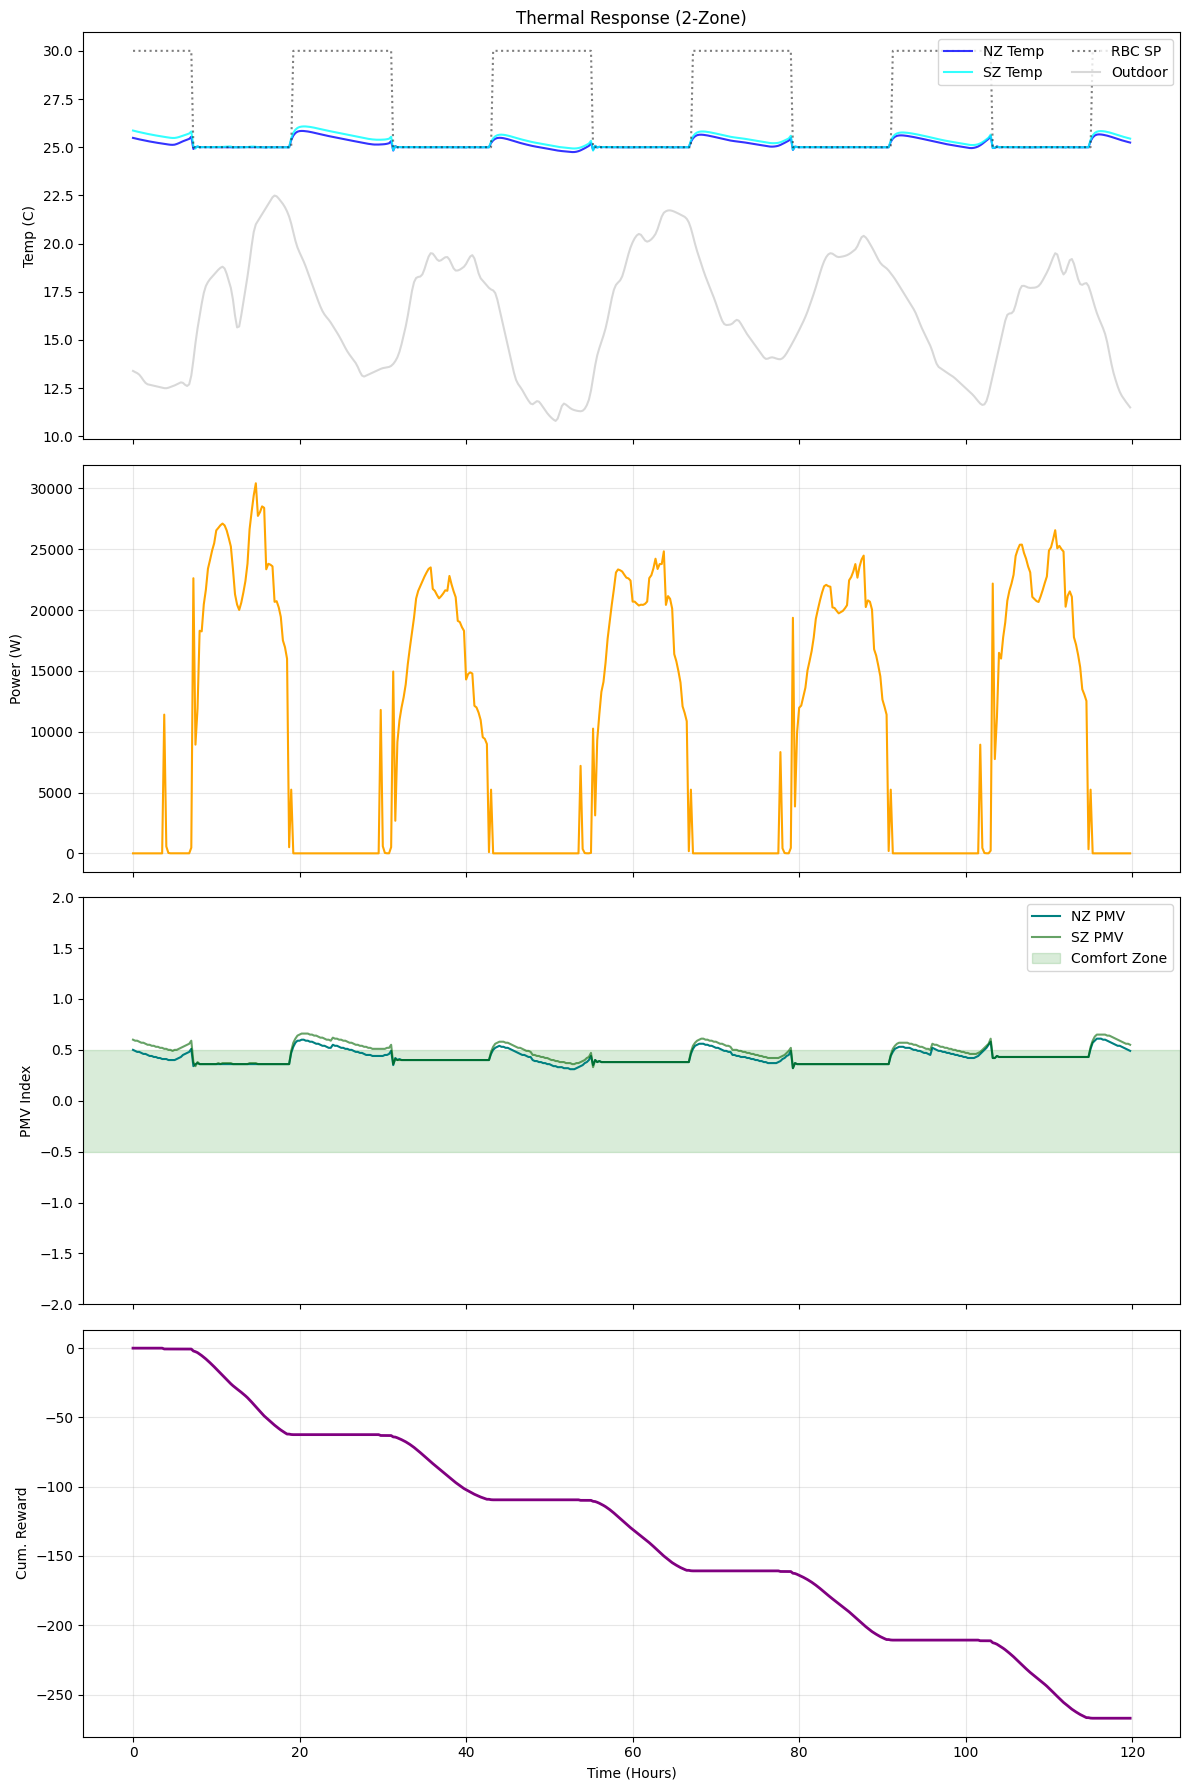

In [23]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
import os
import traceback
from collections import deque

# 导入物理计算库
try:
    from pythermalcomfort.models import pmv_ppd_iso
    print("[System] pythermalcomfort 已加载。")
except ImportError:
    print("[WARN] 未找到 pythermalcomfort。PMV 将默认为 0。")
    pmv_ppd_iso = None

# --- 工具函数：鲁棒请求 ---
def retry_request(method, url, max_retries=5, delay=1.0, **kwargs):
    for i in range(max_retries):
        try:
            resp = requests.request(method, url, **kwargs)
            resp.raise_for_status()
            if method.lower() == 'put' and 'stop' in url: return {'status': 'stopped'}
            return resp.json()
        except Exception as e:
            if i == max_retries - 1:
                print(f"[Error] 请求失败 ({max_retries} 次尝试): {url}")
                raise e
            time.sleep(delay * (2 ** i))

# --- 工具函数：物理计算 ---
def calc_pmv(t_air_k, phys_config, clo):
    if pmv_ppd_iso is None: return 0.0
    t_c = t_air_k - 273.15
    try:
        res = pmv_ppd_iso(
            tdb=t_c, tr=t_c, vr=phys_config['air_velocity'],
            rh=phys_config['relative_humidity'], met=phys_config['metabolic_rate'], clo=clo
        )
        return res['pmv'] if isinstance(res, dict) else res.pmv
    except: return 0.0

def get_clo(t_out_c, params):
    if t_out_c < params['temp_low']: return params['winter_clo']
    if t_out_c > params['temp_high']: return params['summer_clo']
    ratio = (t_out_c - params['temp_low']) / (params['temp_high'] - params['temp_low'])
    return params['winter_clo'] + ratio * (params['summer_clo'] - params['winter_clo'])

# ==============================================================================
# 主执行程序
# ==============================================================================
def run_rbc_hydronic_validation():
    # 1. 设置时间 (验证周：起始日 + 7天)
    VAL_START_DAY = config.START_DAY + 7 
    start_time = VAL_START_DAY * 24 * 3600
    duration = 5 * 24 * 3600
    steps = int(duration / config.CONTROL_PERIOD)
    
    print(f"[{config.CASE_NAME}] 启动 2-Zone RBC 验证运行...")
    print(f"    > 起始日: {VAL_START_DAY} | 时长: 5 天 | 步数: {steps}")

    testid = None
    try:
        # 2. 初始化 BOPTEST
        sel_res = retry_request('post', f'{config.BOPTEST_URL}/testcases/{config.CASE_NAME}/select')
        testid = sel_res['testid']
        print(f"    > TestID: {testid}")
        
        retry_request('put', f'{config.BOPTEST_URL}/scenario/{testid}', json={'electricity_price': 'dynamic'})
        retry_request('put', f'{config.BOPTEST_URL}/step/{testid}', json={'step': config.CONTROL_PERIOD})
        
        # 初始化与 7 天预热
        init_res = retry_request('put', f'{config.BOPTEST_URL}/initialize/{testid}', 
                                 json={'start_time': start_time, 'warmup_period': 7*24*3600})
        y_current = init_res['payload']
        
        # 3. 历史队列 (用于构建观测空间 CSV)
        h_temp_nz = deque([y_current['structure_reaTZonNz_y']]*4, maxlen=4)
        h_temp_sz = deque([y_current['structure_reaTZonSz_y']]*4, maxlen=4)
        h_act_nz = deque([config.BASE_COOLING_SETPOINT + 273.15]*4, maxlen=4)
        h_act_sz = deque([config.BASE_COOLING_SETPOINT + 273.15]*4, maxlen=4)
        h_power = deque([0.0]*4, maxlen=4)
        
        # 4. 仿真循环
        data_log = []
        total_cost = 0.0
        occupied_steps = 0
        comfort_viol_steps = 0
        current_clo = 0.5
        prev_day_idx = -1
        
        for i in range(steps):
            time_now = y_current['time']
            
            # --- A. 更新服装热阻 (每日更新) ---
            day_idx = int(time_now // 86400)
            if day_idx != prev_day_idx:
                f_res = retry_request('put', f'{config.BOPTEST_URL}/forecast/{testid}', 
                                     json={'point_names':['TDryBul'], 'horizon':86400, 'interval':3600})
                daily_mean = np.mean(f_res['payload']['TDryBul']) - 273.15
                current_clo = get_clo(daily_mean, config.PHYSICAL_CONFIG['clo_dynamic_params'])
                prev_day_idx = day_idx

            # --- B. 获取预报 ---
            f_res = retry_request('put', f'{config.BOPTEST_URL}/forecast/{testid}', 
                                 json={'point_names': config.FORECAST_POINTS, 
                                       'horizon': 4*config.CONTROL_PERIOD, 
                                       'interval': config.CONTROL_PERIOD})
            forecast = f_res['payload']
            
            # --- 关键修复：增加安全提取逻辑，防止 NoneType 导致比较错误 ---
            occ_nz = forecast['Occupancy[nZ]'][0] if forecast['Occupancy[nZ]'][0] is not None else 0.0
            occ_sz = forecast['Occupancy[sZ]'][0] if forecast['Occupancy[sZ]'][0] is not None else 0.0
            price_elec = forecast['PriceElectricPowerDynamic'][0] if forecast['PriceElectricPowerDynamic'][0] is not None else 0.0
            
            # --- C. RBC 逻辑 (25/30C) ---
            is_nz_occupied = occ_nz > 0
            is_sz_occupied = occ_sz > 0
            
            set_nz_c = 25.0 if is_nz_occupied else 30.0
            set_sz_c = 25.0 if is_sz_occupied else 30.0
            
            # --- D. 执行动作 ---
            u = {
                'bms_oveTZonSetMaxNz_u': set_nz_c + 273.15, 'bms_oveTZonSetMaxNz_activate': 1,
                'bms_oveTZonSetMaxSz_u': set_sz_c + 273.15, 'bms_oveTZonSetMaxSz_activate': 1,
                'bms_oveTZonSetMinNz_u': config.FIXED_HEATING_SETPOINT, 'bms_oveTZonSetMinNz_activate': 1,
                'bms_oveTZonSetMinSz_u': config.FIXED_HEATING_SETPOINT, 'bms_oveTZonSetMinSz_activate': 1,
                # --- 新增：固定供水温度控制 ---
                # # 1. 生产侧 (Plant)
                # 'bms_oveTProHea_u': 318.15, 'bms_oveTProHea_activate': 1, # 热泵固定 45C
                # 'bms_oveTProCoo_u': 280.15, 'bms_oveTProCoo_activate': 1, # 冷机固定 7C
                
                # # 2. 末端分配侧 (Emission/FCU)
                # # 固定供水温度可以覆盖掉模型内置的“室外温度补偿曲线”
                # 'bms_oveTSupEmiHeaNz_u': 313.15, 'bms_oveTSupEmiHeaNz_activate': 1, # 北区加热 40C
                # 'bms_oveTSupEmiHeaSz_u': 313.15, 'bms_oveTSupEmiHeaSz_activate': 1, # 南区加热 40C
                # 'bms_oveTSupEmiCooNz_u': 283.15, 'bms_oveTSupEmiCooNz_activate': 1, # 北区冷却 10C
                # 'bms_oveTSupEmiCooSz_u': 283.15, 'bms_oveTSupEmiCooSz_activate': 1, # 南区冷却 10C
            }
            res_step = retry_request('post', f'{config.BOPTEST_URL}/advance/{testid}', json=u)
            y_next = res_step['payload']
            
            # --- E. 指标计算 ---
            p_total = (y_next.get('heating_cooling_reaPProCoo_y', 0) + 
                       y_next.get('heating_cooling_reaPProHea_y', 0) + 
                       y_next.get('heating_cooling_reaPFcuNz_y', 0) + 
                       y_next.get('heating_cooling_reaPFcuSz_y', 0))
            
            step_cost = (p_total * config.SAMPLING_PERIOD / 3600000.0) * price_elec
            total_cost += step_cost
            
            # 两区域 PMV
            pmv_nz = calc_pmv(y_next['structure_reaTZonNz_y'], config.PHYSICAL_CONFIG, current_clo)
            pmv_sz = calc_pmv(y_next['structure_reaTZonSz_y'], config.PHYSICAL_CONFIG, current_clo)
            
            # 舒适度惩罚 (仅在有人时计算)
            p_nz = max(0, abs(pmv_nz) - 0.5)**2 if is_nz_occupied else 0
            p_sz = max(0, abs(pmv_sz) - 0.5)**2 if is_sz_occupied else 0
            total_pmv_p = p_nz + p_sz
            
            if is_nz_occupied or is_sz_occupied:
                occupied_steps += 1
                if p_nz > 0 or p_sz > 0: comfort_viol_steps += 1
            
            # 动作跳变 (L1)
            delta_u = abs((set_nz_c + 273.15) - h_act_nz[-1]) + abs((set_sz_c + 273.15) - h_act_sz[-1])
            
            # 统一奖励逻辑 (单区域平均)
            n_z = config.N_ZONES
            w = config.REWARD_WEIGHTS
            term_en = w['scaler_energy'] * (step_cost / n_z)
            term_cm = w['scaler_comfort'] * (total_pmv_p / n_z)
            term_sm = w['scaler_smooth'] * (delta_u / n_z)
            
            total_reward = - (w['w_energy'] * term_en + w['w_comfort'] * term_cm + w['w_smooth'] * term_sm)

            # --- F. 记录数据 ---
            row = {
                'time': time_now,
                'obs_sin_time': np.sin(2 * np.pi * (time_now % 86400) / 86400),
                'obs_cos_time': np.cos(2 * np.pi * (time_now % 86400) / 86400),
                'temp_nz': y_next['structure_reaTZonNz_y'] - 273.15,
                'temp_sz': y_next['structure_reaTZonSz_y'] - 273.15,
                'setpoint_nz': set_nz_c, 'setpoint_sz': set_sz_c,
                'temp_out': y_next['weaSta_reaWeaTDryBul_y'] - 273.15,
                'power_total': p_total,
                'cost': step_cost,
                'pmv_nz': pmv_nz, 'pmv_sz': pmv_sz,
                'reward': total_reward,
                'is_occupied': int(is_nz_occupied or is_sz_occupied),
                # 包含 4-Past 历史用于对齐 DRL 观测
                'obs_T_nz_p1': h_temp_nz[-1]-273.15, 'obs_T_nz_p2': h_temp_nz[-2]-273.15,
                'obs_T_sz_p1': h_temp_sz[-1]-273.15, 'obs_T_sz_p2': h_temp_sz[-2]-273.15,
                'obs_pow_p1': h_power[-1] / config.MAX_SYSTEM_POWER
            }
            data_log.append(row)
            
            # 更新状态
            h_temp_nz.append(y_next['structure_reaTZonNz_y'])
            h_temp_sz.append(y_next['structure_reaTZonSz_y'])
            h_act_nz.append(set_nz_c + 273.15)
            h_act_sz.append(set_sz_c + 273.15)
            h_power.append(p_total)
            y_current = y_next
            
            if i % 96 == 0: print(f"    > Step {i}/{steps} | Reward: {total_reward:.2f}")

        # 5. 保存与可视化
        df = pd.DataFrame(data_log)
        csv_path = os.path.join(config.LOG_DIRS['rbc_data'], 'rbc_validation_hydronic_2zone.csv')
        df.to_csv(csv_path, index=False)
        print(f"\n[Success] RBC 数据已保存: {csv_path}")
        
        # --- 标定报告 ---
        mean_cost_occ = df[df['is_occupied']==1]['cost'].mean() / config.N_ZONES
        suggested_s_en = 0.5 / mean_cost_occ if mean_cost_occ > 0 else 0
        
        print("\n" + "="*40)
        print("      RBC PERFORMANCE REPORT (2-ZONE)      ")
        print("="*40)
        print(f"7天总成本        : ${total_cost:.2f}")
        print(f"舒适度违规比例    : {comfort_viol_steps}/{occupied_steps} 步")
        print(f"单区域平均步能耗  : {mean_cost_occ:.6f}")
        print(f"建议能量缩放因子  : {suggested_s_en:.2f} (目标项 ~0.5)")
        print("="*40)
        
        # --- 绘图 ---
        fig, axes = plt.subplots(4, 1, figsize=(12, 18), sharex=True)
        time_h = np.arange(len(df)) * config.CONTROL_PERIOD / 3600
        
        # Ax1: 温度
        axes[0].plot(time_h, df['temp_nz'], label='NZ Temp', color='blue', alpha=0.8)
        axes[0].plot(time_h, df['temp_sz'], label='SZ Temp', color='cyan', alpha=0.8)
        axes[0].plot(time_h, df['setpoint_nz'], ':', label='RBC SP', color='black', alpha=0.5)
        axes[0].plot(time_h, df['temp_out'], label='Outdoor', color='gray', alpha=0.3)
        axes[0].set_ylabel('Temp (C)')
        axes[0].legend(loc='upper right', ncol=2)
        axes[0].set_title('Thermal Response (2-Zone)')

        # Ax2: 功率
        axes[1].plot(time_h, df['power_total'], label='System Power (W)', color='orange')
        axes[1].set_ylabel('Power (W)')
        axes[1].grid(True, alpha=0.3)

        # Ax3: PMV
        axes[2].plot(time_h, df['pmv_nz'], label='NZ PMV', color='teal')
        axes[2].plot(time_h, df['pmv_sz'], label='SZ PMV', color='darkgreen', alpha=0.6)
        axes[2].axhspan(-0.5, 0.5, color='green', alpha=0.15, label='Comfort Zone')
        axes[2].set_ylabel('PMV Index')
        axes[2].set_ylim(-2, 2)
        axes[2].legend()

        # Ax4: 累计奖励
        axes[3].plot(time_h, df['reward'].cumsum(), label='RBC Cumulative Reward', color='purple', linewidth=2)
        axes[3].set_ylabel('Cum. Reward')
        axes[3].set_xlabel('Time (Hours)')
        axes[3].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.savefig(os.path.join(config.LOG_DIRS['results'], 'rbc_validation_hydronic_plot.png'))
        plt.show()

    except Exception as e:
        print(f"\n[CRITICAL ERROR] {e}")
        traceback.print_exc()
    finally:
        if testid: retry_request('put', f'{config.BOPTEST_URL}/stop/{testid}')

if __name__ == '__main__':
    run_rbc_hydronic_validation()

# DRL


[ForecastProvider] 正在预取全量数据 (Horizon: 360.0h)...
[ForecastProvider] 预取成功。点位: ['time', 'Occupancy[nZ]', 'Occupancy[sZ]', 'PriceElectricPowerDynamic', 'TDryBul', 'HGloHor']
Using cpu device

>>> 目标总计: 500 Epochs (960000 步)
>>> 当前进度: 0 Epochs (0 步)
>>>> 剩余待训: 500 Epochs (960000 步)
Logging to multizone_office_simple_hydronic_residual_opt\tb_logs\PPO_0
| Comfort Vio Rate | 59.4% of time | (Goal: < 5%) |

[Epoch 1 Analysis]
---------------------------------------------------------------------------
| Component      | Raw Avg    | Weighted Avg (Contrib) |
---------------------------------------------------------------------------
| Energy         | $ 0.7325   | - 1.099  (77.5%) |
| Comfort        | 0.540 (PMV) | - 0.248  (17.5%) |
| Smoothness     | 4.071 (K)   | - 0.071  (5.0%) |
---------------------------------------------------------------------------
| TOTAL REWARD   |            | -680.970 |
---------------------------------------------------------------------------
[*] 发现更佳模型，已保存至: mu

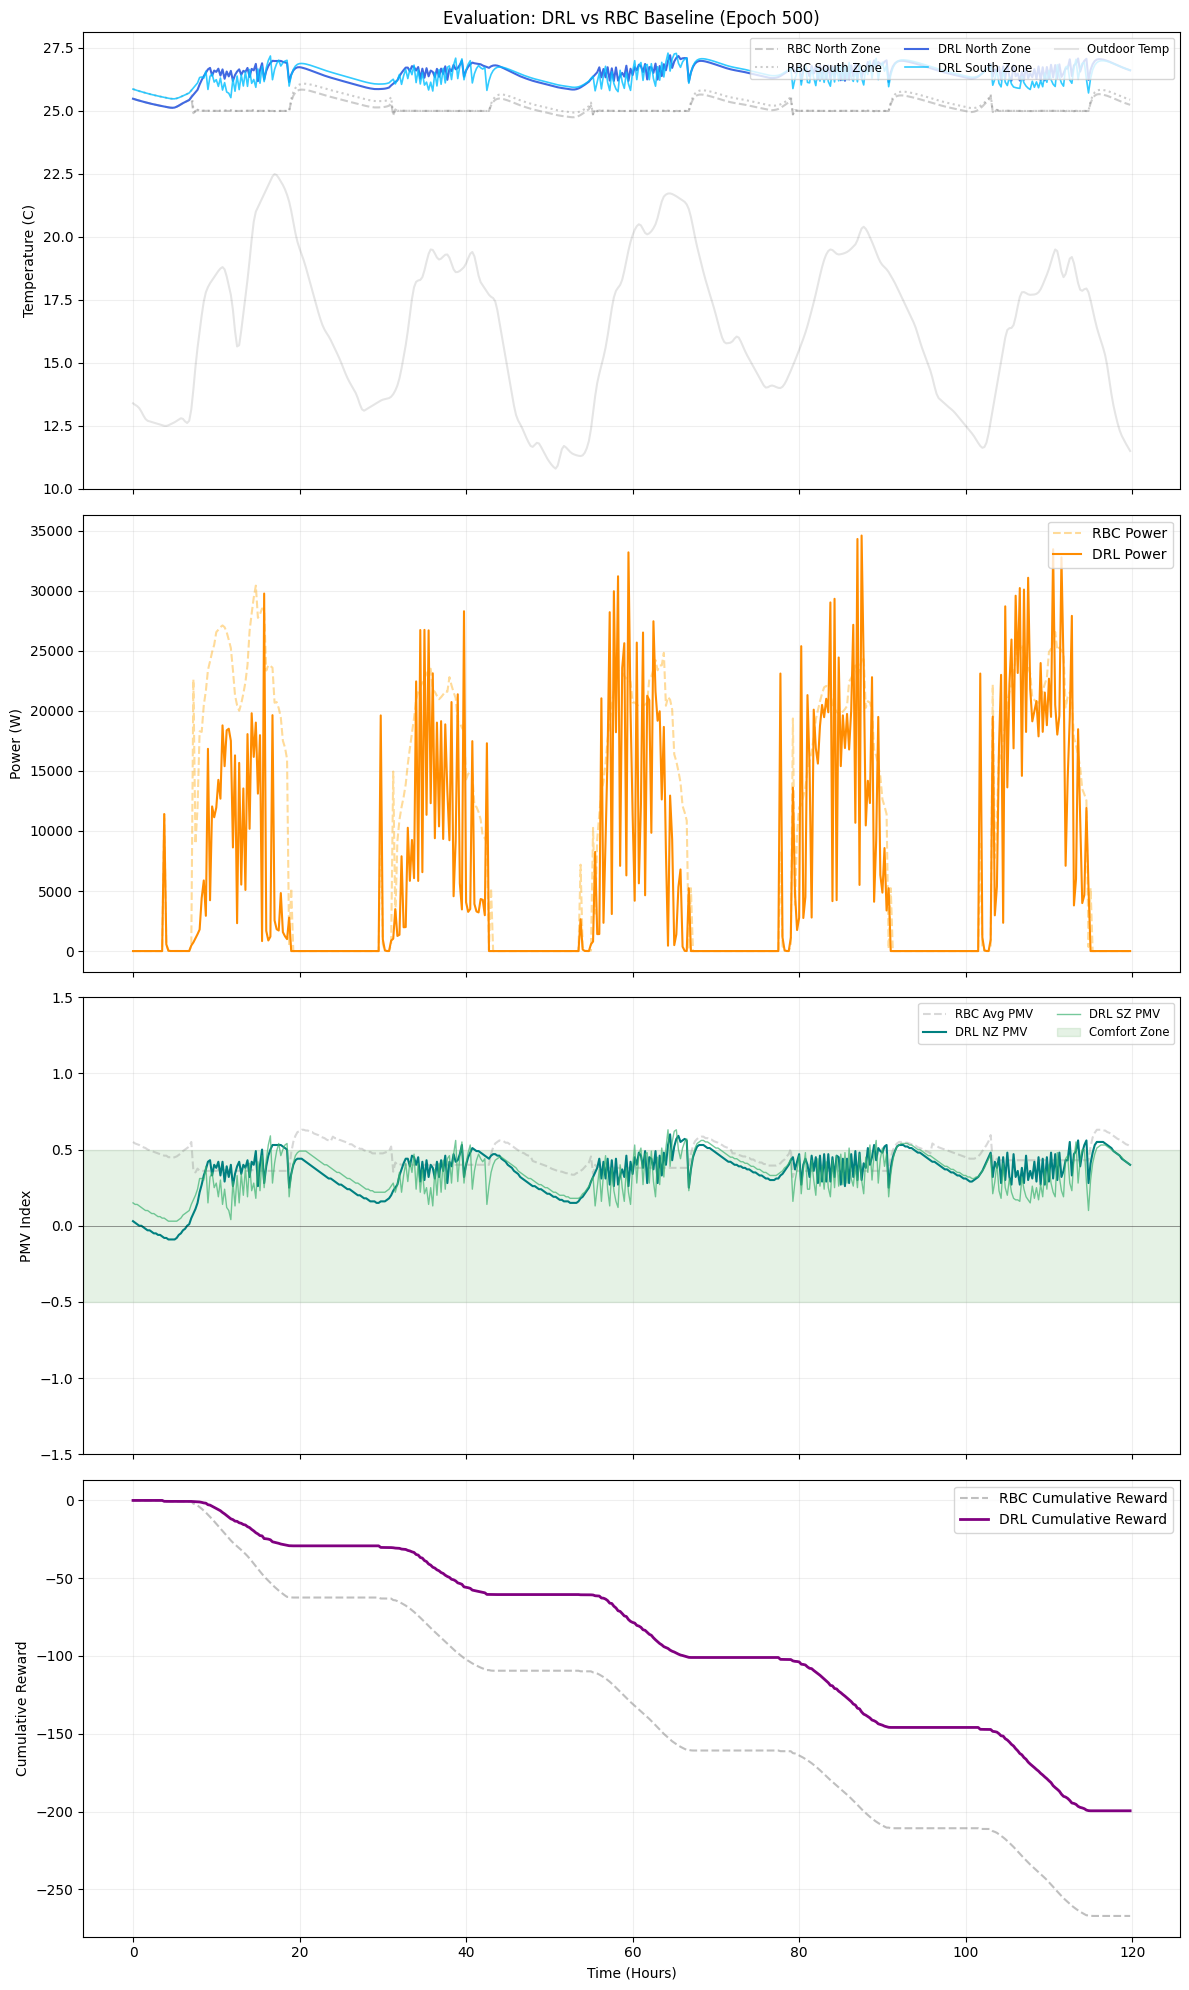

In [5]:
import os
import gymnasium as gym
import torch
import requests
import pandas as pd
import numpy as np
import time
import traceback
import json
import gc
import subprocess
import shlex
import sys
import math
import matplotlib.pyplot as plt
from collections import deque
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import SubprocVecEnv
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common.monitor import Monitor

# 引入物理计算库
try:
    from pythermalcomfort.models import pmv_ppd_iso
except ImportError:
    pmv_ppd_iso = None

# ==============================================================================
# 1. 核心辅助类与工具函数 (工程健壮性升级)
# ==============================================================================

def global_linear_schedule(initial_value):
    """学习率线性衰减调度器"""
    def func(progress_remaining):
        return initial_value * (0.9 * progress_remaining + 0.1)
    return func

def safe_float(val, default=0.0):
    try:
        if val is None: return default
        f = float(val)
        return f if not (math.isnan(f) or math.isinf(f)) else default
    except: return default

def _make_request_with_retry(method, url, rank, context_msg, max_retries=5, **kwargs):
    """带指数退避和错误过滤的健壮请求"""
    for attempt in range(max_retries):
        try:
            kwargs.setdefault('timeout', 90)
            response = requests.request(method, url, **kwargs)
            if response.status_code == 200:
                return response.json() if response.content else {'status': 'success'}
            # 忽略重复停止导致的 400 错误
            if response.status_code == 400 and "stop" in url:
                return {'status': 'ignored_error'}
        except Exception as e:
            if attempt < max_retries - 1:
                time.sleep(2 * (attempt + 1))
            else:
                print(f"[Rank {rank}] {context_msg} 最终失败: {e}")
    return None

def get_dynamic_clo(daily_mean_tout, params):
    """动态服装热阻计算逻辑"""
    t = safe_float(daily_mean_tout, 20.0)
    if t < params['temp_low']: return params['winter_clo']
    elif t > params['temp_high']: return params['summer_clo']
    else:
        ratio = (t - params['temp_low']) / (params['temp_high'] - params['temp_low'])
        return params['winter_clo'] + ratio * (params['summer_clo'] - params['winter_clo'])

def calculate_pmv_state(t_air_k, phys_config, clo_val):
    """物理 PMV 计算接口"""
    if pmv_ppd_iso is None: return 0.0
    t_c = safe_float(t_air_k, 298.15) - 273.15
    try:
        res = pmv_ppd_iso(tdb=t_c, tr=t_c, vr=phys_config['air_velocity'],
                         rh=phys_config['relative_humidity'], met=phys_config['metabolic_rate'], 
                         clo=safe_float(clo_val, 0.5))
        return safe_float(res['pmv'] if isinstance(res, dict) else res.pmv, 0.0)
    except: return 0.0

class ForecastProvider:
    """预取预测数据辅助类：针对 2 区域进行扩展"""
    def __init__(self, config_obj):
        self.config = config_obj
        self.data = {}
        self.start_time = config_obj.START_DAY * 24 * 3600
        self.total_horizon = (config_obj.RBC_COLLECT_DAYS + 1) * 24 * 3600 

    def prefetch_all(self):
        print(f"\n[ForecastProvider] 正在预取全量数据 (Horizon: {self.total_horizon/3600:.1f}h)...")
        try:
            sel_url = f"{self.config.BOPTEST_URL}/testcases/{self.config.CASE_NAME}/select"
            res_sel = requests.post(sel_url, timeout=60).json()
            tid = res_sel['testid']
            
            requests.put(f"{self.config.BOPTEST_URL}/scenario/{tid}", json={'electricity_price': 'dynamic'})
            requests.put(f"{self.config.BOPTEST_URL}/initialize/{tid}", 
                         json={'start_time': self.start_time, 'warmup_period': 0})
            
            f_payload = {
                'point_names': self.config.FORECAST_POINTS,
                'horizon': self.total_horizon,
                'interval': self.config.CONTROL_PERIOD
            }
            res_f = requests.put(f"{self.config.BOPTEST_URL}/forecast/{tid}", json=f_payload, timeout=120).json()
            
            if 'payload' in res_f:
                self.data = {k: np.array([x if x is not None else 0.0 for x in v]) 
                             for k, v in res_f['payload'].items()}
                print(f"[ForecastProvider] 预取成功。点位: {list(self.data.keys())}")
            
            requests.put(f"{self.config.BOPTEST_URL}/stop/{tid}")
        except Exception as e:
            print(f"[ForecastProvider] 预取失败: {e}")
            raise e

    def get_local_forecast(self, current_time, point_name, horizon_steps=5):
        rel_time = current_time - self.start_time
        idx = int(max(0, rel_time // self.config.CONTROL_PERIOD))
        full_series = self.data.get(point_name)
        if full_series is None: return np.zeros(horizon_steps)
        vals = full_series[idx : idx + horizon_steps]
        if len(vals) < horizon_steps:
            padding = [vals[-1]] * (horizon_steps - len(vals)) if len(vals) > 0 else [0.0] * horizon_steps
            vals = np.concatenate([vals, padding])
        return vals

# ==============================================================================
# 2. 2-Zone 环境类封装 (集成动态热阻与健壮通信)
# ==============================================================================

class HydronicResidualEnv(gym.Env):
    def __init__(self, config_obj, forecast_provider, is_validation=False, rank=0):
        super().__init__()
        self.config, self.fp, self.rank = config_obj, forecast_provider, rank
        self.url = self.config.BOPTEST_URL
        self.env_step_counter = 0  # 新增：用于步数追踪
        self.debug_freq = 96        # 新增：每仿真 1 天(96步)打印一次快照
        
        start_day = self.config.START_DAY + 7 if is_validation else self.config.START_DAY
        self.start_time = start_day * 24 * 3600
        self.max_episode_steps = int(self.config.SIMULATION_DAYS * 24 * 3600 / self.config.CONTROL_PERIOD)
        
        self.action_space = gym.spaces.Box(low=-1.0, high=1.0, shape=(2,), dtype=np.float32)
        
        # 解析 Config 中的观测空间物理边界
        self.obs_low, self.obs_high = self._build_obs_bounds()
        self.observation_space = gym.spaces.Box(low=self.obs_low, high=self.obs_high, dtype=np.float32)
        
        self.testid = None
        self.history_temp_nz = deque(maxlen=5); self.history_temp_sz = deque(maxlen=5)
        self.history_act_nz = deque(maxlen=5); self.history_act_sz = deque(maxlen=5)
        self.history_power = deque(maxlen=5)

    def _build_obs_bounds(self):
        """
        根据 Config 中的列名生成对应的物理上下界 (low, high)。
        修正点：增强了对简化列名 (obs_T_nz, obs_act_nz) 的识别逻辑。
        """
        lows, highs = [], []
        for col in self.config.OBSERVATION_COLUMNS:
            # 移除前缀，提取核心特征
            base_key = col.replace('obs_', '')
            
            # === 修正后的匹配逻辑 ===
            # 1. 显式匹配特殊物理量
            if 'Price' in base_key:
                key = 'Price'
            elif 'Occ' in base_key:
                key = 'Occ'
            elif 'HGloHor' in base_key:
                key = 'HGloHor'
            elif 'TDryBul' in base_key:
                key = 'TDryBul'
            elif 'pmv' in base_key:
                key = 'pmv'
            elif 'pow' in base_key:
                key = 'pow'
            # 2. 泛化匹配温度 (T_nz, T_sz, act_nz 等)
            # 只要包含 T_ 或 act_，且已经被前面的特殊量排除，就认为是室内/动作温度
            elif ('T_' in base_key or 'act_' in base_key):
                key = 'T'
            else:
                # 3. 兜底逻辑 (尝试剥离后缀)
                key = base_key.split('_past')[0].split('_future')[0].split('_current')[0]
            # =======================

            # 从 Config 获取范围，默认为 (0, 1)
            r = self.config.OBSERVATIONS_CONFIG.get(key, (0.0, 1.0))
            lows.append(r[0])
            highs.append(r[1])
            
        return np.array(lows, dtype=np.float32), np.array(highs, dtype=np.float32)

    def _get_observations(self, y):
        """
        根据 BOPTEST 返回的 y 构建观测向量。
        修正点：
        1. 历史队列索引偏移 (P1 应取 -2，因为 -1 是当前)。
        2. 室外温度 (TDryBul) 从 C 转换为 K。
        """
        cur_t = y.get('time', self.start_time)
        
        # --- 内部辅助函数：正确获取历史数据 ---
        # steps_back=1 代表 P1 (上一步), steps_back=2 代表 P2
        def get_hist(buffer, steps_back, default_val=298.15):
            # 因为 step() 中先执行了 append，所以 buffer[-1] 是当前步 (t)
            # 历史数据应该是 buffer[-(1 + steps_back)]
            idx = -(1 + steps_back)
            if len(buffer) >= (1 + steps_back):
                return buffer[idx]
            return default_val

        # 建立映射字典
        raw = {
            'obs_sin_time': np.sin(2*np.pi*(cur_t%86400)/86400),
            'obs_cos_time': np.cos(2*np.pi*(cur_t%86400)/86400),
            
            # --- North Zone (Current + History) ---
            'obs_T_nz': y.get('structure_reaTZonNz_y', 298.15),
            'obs_T_nz_p1': get_hist(self.history_temp_nz, 1), # P1 取倒数第2个
            'obs_T_nz_p2': get_hist(self.history_temp_nz, 2), # P2 取倒数第3个
            'obs_T_nz_p3': get_hist(self.history_temp_nz, 3),
            'obs_T_nz_p4': get_hist(self.history_temp_nz, 4),
            
            # --- South Zone (Current + History) ---
            'obs_T_sz': y.get('structure_reaTZonSz_y', 298.15),
            'obs_T_sz_p1': get_hist(self.history_temp_sz, 1),
            'obs_T_sz_p2': get_hist(self.history_temp_sz, 2),
            'obs_T_sz_p3': get_hist(self.history_temp_sz, 3),
            'obs_T_sz_p4': get_hist(self.history_temp_sz, 4),

            # --- System & PMV ---
            'obs_pmv_nz': self.current_pmv_nz,
            'obs_pmv_sz': self.current_pmv_sz,
            'obs_act_nz_p1': get_hist(self.history_act_nz, 1),
            'obs_act_sz_p1': get_hist(self.history_act_sz, 1),
            
            # Power 归一化 (Power 默认为 0)
            'obs_pow_p1': get_hist(self.history_power, 1, 0.0)/self.config.MAX_SYSTEM_POWER,
            'obs_pow_p2': get_hist(self.history_power, 2, 0.0)/self.config.MAX_SYSTEM_POWER,
            'obs_pow_p3': get_hist(self.history_power, 3, 0.0)/self.config.MAX_SYSTEM_POWER,
            'obs_pow_p4': get_hist(self.history_power, 4, 0.0)/self.config.MAX_SYSTEM_POWER,
        }
        
        # --- Forecasts 处理 ---
        forecast_map = {
            'Occupancy[nZ]': 'obs_Occ_nz', 
            'Occupancy[sZ]': 'obs_Occ_sz',
            'PriceElectricPowerDynamic': 'obs_Price',
            'TDryBul': 'obs_TDryBul',
            'HGloHor': 'obs_HGloHor'
        }
        
        for p_bop, p_obs in forecast_map.items():
            vals = self.fp.get_local_forecast(cur_t, p_bop, 5)
            
            # === 单位修正：TDryBul C -> K ===
            if p_bop == 'TDryBul':
                # 如果数值远小于 100 (比如 15C)，说明是摄氏度，转换为 K
                if np.mean(vals) < 100.0:
                    vals = vals + 273.15
            # ==============================

            raw[f'{p_obs}_0'] = vals[0]
            for i in range(1, 5):
                raw[f'{p_obs}_f{i}'] = vals[i]
                
        # 按照 Config 顺序组装向量
        obs_vector = []
        for col in self.config.OBSERVATION_COLUMNS:
            val = raw.get(col, 0.0)
            obs_vector.append(val)
            
        # DEBUG: 只有在检测到异常 NaN 时才打印，避免刷屏
        obs_np = np.array(obs_vector, dtype=np.float32)
        if self.env_step_counter % self.debug_freq == 0:
            if np.isnan(obs_np).any():
                print(f"[Rank {self.rank}][CRITICAL] Detected NaN in Observation!")
            
        return obs_np

    def reset(self, seed=None, options=None):
        if self.testid is None:
            res = _make_request_with_retry('post', f"{self.url}/testcases/{self.config.CASE_NAME}/select", self.rank, "select")
            self.testid = res['testid']
            _make_request_with_retry('put', f"{self.url}/step/{self.testid}", self.rank, "step", json={'step': self.config.CONTROL_PERIOD})
            _make_request_with_retry('put', f"{self.url}/scenario/{self.testid}", self.rank, "scen", json={'electricity_price': 'dynamic'})
            
        res_init = _make_request_with_retry('put', f"{self.url}/initialize/{self.testid}", self.rank, "init", 
                                          json={'start_time': self.start_time, 'warmup_period': 7*24*3600})
        y = res_init['payload']
        self.current_step, self.current_clo = 0, 0.5
        self.current_pmv_nz = 0.0; self.current_pmv_sz = 0.0
        self.history_temp_nz.clear(); self.history_temp_sz.clear()
        self.history_act_nz.clear(); self.history_act_sz.clear(); self.history_power.clear()
        
        self.history_temp_nz.append(y.get('structure_reaTZonNz_y', 298.15))
        self.history_temp_sz.append(y.get('structure_reaTZonSz_y', 298.15))
        self.history_act_nz.append(298.15); self.history_act_sz.append(298.15); self.history_power.append(0.0)
        return self._get_observations(y), {}

    def step(self, action_norm):
        cur_t = self.start_time + self.current_step * self.config.CONTROL_PERIOD
        
        # --- 1. 固定基准逻辑 (不再随 RBC 跳变) ---
        # 统一使用 25.0 C (298.15 K) 作为 DRL 的“零位”
        absolute_base_k = 298.15 
        
        # --- 2. 应用残差动作并进行严格限幅 ---
        # 范围：25C +/- 5C = [20C, 30C]，即 [293.15K, 303.15K]
        # 这样既符合你的逻辑，又绝对不会触发 BOPTEST 的 303.15K 上限警告
        set_nz_k = np.clip(absolute_base_k + float(action_norm[0]) * self.config.RESIDUAL_ACTION_SCALE, 293.15, 303.15)
        set_sz_k = np.clip(absolute_base_k + float(action_norm[1]) * self.config.RESIDUAL_ACTION_SCALE, 293.15, 303.15)
        
        # --- 3. 修正加热设定点单位 (15C -> 288.15K) ---
        heat_setpoint_k = self.config.FIXED_HEATING_SETPOINT + 273.15
        
        u = {
            'bms_oveTZonSetMaxNz_u': set_nz_k, 
            'bms_oveTZonSetMaxNz_activate': 1,
            'bms_oveTZonSetMaxSz_u': set_sz_k, 
            'bms_oveTZonSetMaxSz_activate': 1,
            # 确保不低于该案例的最小值约束
            'bms_oveTZonSetMinNz_u': max(heat_setpoint_k, 288.15), 
            'bms_oveTZonSetMinNz_activate': 1,
            'bms_oveTZonSetMinSz_u': max(heat_setpoint_k, 283.15), 
            'bms_oveTZonSetMinSz_activate': 1,
            # # --- 新增：固定供水温度控制 ---
            # # 1. 生产侧 (Plant)
            # 'bms_oveTProHea_u': 318.15, 'bms_oveTProHea_activate': 1, # 热泵固定 45C
            # 'bms_oveTProCoo_u': 280.15, 'bms_oveTProCoo_activate': 1, # 冷机固定 7C
            
            # # 2. 末端分配侧 (Emission/FCU)
            # # 固定供水温度可以覆盖掉模型内置的“室外温度补偿曲线”
            # 'bms_oveTSupEmiHeaNz_u': 313.15, 'bms_oveTSupEmiHeaNz_activate': 1, # 北区加热 40C
            # 'bms_oveTSupEmiHeaSz_u': 313.15, 'bms_oveTSupEmiHeaSz_activate': 1, # 南区加热 40C
            # 'bms_oveTSupEmiCooNz_u': 283.15, 'bms_oveTSupEmiCooNz_activate': 1, # 北区冷却 10C
            # 'bms_oveTSupEmiCooSz_u': 283.15, 'bms_oveTSupEmiCooSz_activate': 1, # 南区冷却 10C
        }
        
        # 执行环境推进
        res = _make_request_with_retry('post', f"{self.url}/advance/{self.testid}", self.rank, "adv", json=u)
        y_next = res['payload']
        
        # --- 4. 物理指标计算 (Reward 逻辑依然需要 Occupancy 来判定舒适度) ---
        p_tot = (y_next.get('heating_cooling_reaPProCoo_y', 0) + y_next.get('heating_cooling_reaPProHea_y', 0) +
                 y_next.get('heating_cooling_reaPFcuNz_y', 0) + y_next.get('heating_cooling_reaPFcuSz_y', 0))
        
        occ_nz = self.fp.get_local_forecast(cur_t, 'Occupancy[nZ]', 1)[0]
        occ_sz = self.fp.get_local_forecast(cur_t, 'Occupancy[sZ]', 1)[0]
        price = self.fp.get_local_forecast(cur_t, 'PriceElectricPowerDynamic', 1)[0]
        cost = (p_tot * self.config.CONTROL_PERIOD / 3600000.0) * price
        
        # PMV 状态更新
        self.current_pmv_nz = calculate_pmv_state(y_next['structure_reaTZonNz_y'], self.config.PHYSICAL_CONFIG, self.current_clo)
        self.current_pmv_sz = calculate_pmv_state(y_next['structure_reaTZonSz_y'], self.config.PHYSICAL_CONFIG, self.current_clo)
        
        # --- 5. 奖励函数 (单区域归一化) ---
        w, n = self.config.REWARD_WEIGHTS, self.config.N_ZONES
        en_r = (cost / n) * w['scaler_energy']
        
        # 舒适度惩罚：只有在有人时才罚款
        p_nz = max(0, abs(self.current_pmv_nz)-0.4)**2 if occ_nz > 0 else 0
        p_sz = max(0, abs(self.current_pmv_sz)-0.4)**2 if occ_sz > 0 else 0
        cm_r = ((p_nz + p_sz) / n) * w['scaler_comfort']
        
        # 平滑度惩罚：相对于上一时刻的设定值
        du_nz = abs(set_nz_k - self.history_act_nz[-1])
        du_sz = abs(set_sz_k - self.history_act_sz[-1])
        sm_r = ((du_nz + du_sz) / n) * w['scaler_smooth']
        
        reward = -1.0 * (w['w_energy']*en_r + w['w_comfort']*cm_r + w['w_smooth']*sm_r)

        # --- 2. 实时快照打印 ---
        if self.env_step_counter % self.debug_freq == 0:
            print(f"\n>>> [Rank {self.rank}][Step {self.env_step_counter}] Action Snapshot:")
            print(f"    Raw Action: NZ={action_norm[0]:.2f}, SZ={action_norm[1]:.2f}")
            print(f"    Mapped SP:  NZ={set_nz_k-273.15:.2f}C, SZ={set_sz_k-273.15:.2f}C")
            print(f"    Current PMV: NZ={self.current_pmv_nz:.2f}, SZ={self.current_pmv_sz:.2f}")
            print(f"    Rew Comp:   Energy={-en_r*w['w_energy']:.3f}, Comfort={-cm_r*w['w_comfort']:.3f}, Smooth={-sm_r*w['w_smooth']:.3f}")
            print(f"    Total Rew:  {reward:.3f}")

        self.env_step_counter += 1
        
        # 更新队列
        self.history_temp_nz.append(y_next['structure_reaTZonNz_y']); self.history_temp_sz.append(y_next['structure_reaTZonSz_y'])
        self.history_act_nz.append(set_nz_k); self.history_act_sz.append(set_sz_k); self.history_power.append(p_tot)
        self.current_step += 1
        
        info = {'rew_energy': w['w_energy']*en_r, 'rew_comfort': w['w_comfort']*cm_r, 'rew_smooth': w['w_smooth']*sm_r,
                'phys_cost': cost, 'phys_pmv_abs': (abs(self.current_pmv_nz)+abs(self.current_pmv_sz))/2,
                'phys_temp_nz': y_next['structure_reaTZonNz_y']-273.15, 'phys_temp_sz': y_next['structure_reaTZonSz_y']-273.15,
                'phys_act_diff': (du_nz + du_sz)/2}
        
        return self._get_observations(y_next), reward, False, self.current_step >= self.max_episode_steps, info

class NormalizedObservationWrapper(gym.ObservationWrapper):
    def __init__(self, env):
        super().__init__(env)
        self.low_b, self.high_b = env.observation_space.low, env.observation_space.high
        self.range_b = self.high_b - self.low_b
        self.range_b[self.range_b == 0] = 1.0 
        self.observation_space = gym.spaces.Box(low=-1.0, high=1.0, shape=self.observation_space.shape, dtype=np.float32)
    def observation(self, obs):
        obs = np.nan_to_num(obs, nan=0.0)
        return np.nan_to_num(2.0 * (obs - self.low_b) / self.range_b - 1.0, nan=0.0)

# ==============================================================================
# 3. 回调函数 (集成分析表格、CSV接续、历史最佳保留)
# ==============================================================================

class SaveOnBestTrainingRewardCallback(BaseCallback):
    def __init__(self, config_obj, verbose=1):
        super().__init__(verbose)
        self.config = config_obj
        self.save_path = os.path.join(self.config.LOG_DIRS['drl_models'], 'best_model_ppo')
        self.log_path = os.path.join(self.config.LOG_DIRS['drl_models'], 'ppo_training_log.csv')
        self.best_mean_reward = -np.inf
        self.epoch_count = 0
        self.training_log = []
        
        # 尝试接续现有日志
        if os.path.exists(self.log_path):
            try:
                existing_df = pd.read_csv(self.log_path)
                self.training_log = existing_df.to_dict('records')
                self.epoch_count = len(self.training_log)
                if not existing_df.empty:
                    self.best_mean_reward = existing_df['MeanReward'].max()
                print(f"[Log] 发现现有日志，接续 Epoch {self.epoch_count + 1}。历史最高: {self.best_mean_reward:.3f}")
            except Exception as e:
                print(f"[Log] 接续日志失败 ({e})，将创建新日志。")
                
        self.epoch_infos = []
        self.start_time = time.time()

    def _on_step(self) -> bool:
        for info in self.locals['infos']:
            if 'rew_energy' in info: self.epoch_infos.append(info)
        return True

    def _on_rollout_end(self) -> bool:
        self.epoch_count += 1
        # --- DEBUG: 物理违规统计 ---
        if self.epoch_infos:
            pmv_vals = [x['phys_pmv_abs'] for x in self.epoch_infos]
            # 计算 PMV 绝对值超过 0.5 的比例
            violation_rate = sum(1 for p in pmv_vals if p > 0.5) / len(pmv_vals)
            
            # 原有的打印逻辑中加入这一行
            print(f"| Comfort Vio Rate | {violation_rate*100:.1f}% of time | (Goal: < 5%) |")
        ep_rewards = [ep_info['r'] for ep_info in self.model.ep_info_buffer]
        mean_reward = np.mean(ep_rewards) if ep_rewards else -9999
        duration = time.time() - self.start_time

        # 打印详细诊断表格 (百分比占比)
        if self.epoch_infos:
            avg_cost = np.mean([x['phys_cost'] for x in self.epoch_infos])
            avg_pmv = np.mean([x['phys_pmv_abs'] for x in self.epoch_infos])
            avg_act = np.mean([x['phys_act_diff'] for x in self.epoch_infos])
            r_en = np.mean([x['rew_energy'] for x in self.epoch_infos])
            r_cm = np.mean([x['rew_comfort'] for x in self.epoch_infos])
            r_sm = np.mean([x['rew_smooth'] for x in self.epoch_infos])
            total_penalty = max(1e-6, r_en + r_cm + r_sm)

            print(f"\n[Epoch {self.epoch_count} Analysis]")
            print("-" * 75)
            print(f"| Component      | Raw Avg    | Weighted Avg (Contrib) |")
            print("-" * 75)
            print(f"| Energy         | $ {avg_cost:.4f}   | - {r_en:.3f}  ({r_en/total_penalty*100:.1f}%) |")
            print(f"| Comfort        | {avg_pmv:.3f} (PMV) | - {r_cm:.3f}  ({r_cm/total_penalty*100:.1f}%) |")
            print(f"| Smoothness     | {avg_act:.3f} (K)   | - {r_sm:.3f}  ({r_sm/total_penalty*100:.1f}%) |")
            print("-" * 75)
            print(f"| TOTAL REWARD   |            | {mean_reward:.3f} |")
            print("-" * 75)
            self.epoch_infos = []

        # 保存历史最佳模型
        if mean_reward > self.best_mean_reward:
            self.best_mean_reward = mean_reward
            self.model.save(self.save_path)
            print(f"[*] 发现更佳模型，已保存至: {self.save_path}")

        self.training_log.append({'Epoch': self.epoch_count, 'MeanReward': mean_reward, 'Time': duration})
        pd.DataFrame(self.training_log).to_csv(self.log_path, index=False)
        self.start_time = time.time()
        return True

# ==============================================================================
# 4. 评估逻辑与主循环
# ==============================================================================

def run_evaluation(model, epoch_idx, config_obj, fp, restart=False):
    """
    高级原位验证与对比绘图：
    展示 DRL 与 RBC 在温度、能耗、PMV 以及累计奖励上的全方位对比。
    """
    print(f"\n[Eval] 启动第 {epoch_idx} Epoch 的原位验证与直观对比...")
    
    # if restart:
    #     restart_boptest(config_obj)
    #     time.sleep(15)

    # 1. 初始化验证环境 (rank=-1 保证独立实例)
    raw_env = HydronicResidualEnv(config_obj, fp, is_validation=True, rank=-1)
    env = NormalizedObservationWrapper(raw_env)
    
    # 2. 加载 RBC 基准数据用于对比
    rbc_path = os.path.join(config_obj.LOG_DIRS['rbc_data'], 'rbc_validation_hydronic_2zone.csv')
    if not os.path.exists(rbc_path):
        print(f"[Error] 找不到 RBC 基准数据: {rbc_path}，请先运行 RBC 采集脚本。")
        return
    df_rbc = pd.read_csv(rbc_path)
    
    obs, _ = env.reset()
    done, logs = False, []
    
    # 3. 运行 DRL 验证仿真
    while not done:
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, term, trunc, info = env.step(action)
        done = term or trunc
        
        # 提取绘图所需信息
        info['reward_step'] = reward 
        info['power_total'] = raw_env.history_power[-1]
        info['pmv_nz_raw'] = raw_env.current_pmv_nz
        info['pmv_sz_raw'] = raw_env.current_pmv_sz
        # 同步室外温度记录
        info['temp_out'] = df_rbc['temp_out'].iloc[len(logs)] if len(logs) < len(df_rbc) else 0
        logs.append(info)
    
    df_drl = pd.DataFrame(logs)
    # 对齐 RBC 数据长度
    df_rbc_sync = df_rbc.iloc[:len(df_drl)].copy()
    time_h = np.arange(len(df_drl)) * config_obj.CONTROL_PERIOD / 3600
    
    # 4. 开启高级绘图 (4 面板对齐 RBC 风格)
    fig, axes = plt.subplots(4, 1, figsize=(12, 20), sharex=True)
    
    # --- Panel 1: 温度对比 (NZ & SZ) ---
    axes[0].plot(time_h, df_rbc_sync['temp_nz'], label='RBC North Zone', color='gray', linestyle='--', alpha=0.4)
    axes[0].plot(time_h, df_rbc_sync['temp_sz'], label='RBC South Zone', color='gray', linestyle=':', alpha=0.4)
    axes[0].plot(time_h, df_drl['phys_temp_nz'], label='DRL North Zone', color='royalblue', linewidth=1.5)
    axes[0].plot(time_h, df_drl['phys_temp_sz'], label='DRL South Zone', color='deepskyblue', linewidth=1.2, alpha=0.8)
    axes[0].plot(time_h, df_rbc_sync['temp_out'], label='Outdoor Temp', color='black', alpha=0.1, linestyle='-')
    axes[0].set_ylabel('Temperature (C)')
    axes[0].set_title(f'Evaluation: DRL vs RBC Baseline (Epoch {epoch_idx})')
    axes[0].legend(loc='upper right', ncol=3, fontsize='small')
    axes[0].grid(True, alpha=0.2)
    
    # --- Panel 2: 系统总功率对比 ---
    axes[1].plot(time_h, df_rbc_sync['power_total'], label='RBC Power', color='orange', linestyle='--', alpha=0.4)
    axes[1].plot(time_h, df_drl['power_total'], label='DRL Power', color='darkorange', linewidth=1.5)
    axes[1].set_ylabel('Power (W)')
    axes[1].legend(loc='upper right')
    axes[1].grid(True, alpha=0.2)
    
    # --- Panel 3: PMV 舒适度对比 (North & South) ---
    # 绘制 RBC 的 PMV 均值作为参考
    rbc_pmv_avg = (df_rbc_sync['pmv_nz'] + df_rbc_sync['pmv_sz']) / 2
    axes[2].plot(time_h, rbc_pmv_avg, label='RBC Avg PMV', color='gray', linestyle='--', alpha=0.3)
    axes[2].plot(time_h, df_drl['pmv_nz_raw'], label='DRL NZ PMV', color='teal', linewidth=1.5)
    axes[2].plot(time_h, df_drl['pmv_sz_raw'], label='DRL SZ PMV', color='mediumseagreen', linewidth=1.0, alpha=0.7)
    axes[2].axhspan(-0.5, 0.5, color='green', alpha=0.1, label='Comfort Zone') # 舒适带
    axes[2].axhline(0, color='black', linewidth=0.5, alpha=0.5)
    axes[2].set_ylabel('PMV Index')
    axes[2].set_ylim(-1.5, 1.5)
    axes[2].legend(loc='upper right', ncol=2, fontsize='small')
    axes[2].grid(True, alpha=0.2)
    
    # --- Panel 4: 累计奖励对比 (核心改进) ---
    axes[3].plot(time_h, df_rbc_sync['reward'].cumsum(), label='RBC Cumulative Reward', color='gray', linestyle='--', alpha=0.5)
    axes[3].plot(time_h, df_drl['reward_step'].cumsum(), label='DRL Cumulative Reward', color='purple', linewidth=2)
    axes[3].set_ylabel('Cumulative Reward')
    axes[3].set_xlabel('Time (Hours)')
    axes[3].legend(loc='upper right')
    axes[3].grid(True, alpha=0.2)
    
    plt.tight_layout()
    
    # 5. 保存图像与结果报告
    plot_filename = os.path.join(config_obj.LOG_DIRS['results'], f"eval_report_epoch_{epoch_idx}.png")
    plt.savefig(plot_filename, dpi=300)
    print(f"[Storage] 评估对比图已保存至: {plot_filename}")
    
    # 性能量化分析
    drl_cost = df_drl['phys_cost'].sum()
    rbc_cost = df_rbc_sync['cost'].sum()
    drl_reward = df_drl['reward_step'].sum()
    rbc_reward = df_rbc_sync['reward'].sum()
    savings = (1 - drl_cost / rbc_cost) * 100
    
    print(f"\n" + "="*50)
    print(f"      PERFORMANCE SUMMARY (Epoch {epoch_idx})      ")
    print(f"="*50)
    print(f"节能率 (Energy Savings)   : {savings:.2f}%")
    print(f"DRL 总奖励 (Total Reward) : {drl_reward:.2f}")
    print(f"RBC 总奖励 (Total Reward) : {rbc_reward:.2f}")
    print(f"奖励提升率 (Improvement)  : {((drl_reward - rbc_reward) / abs(rbc_reward)) * 100:.2f}%")
    print(f"="*50)

    if raw_env.testid: _make_request_with_retry('put', f"{config_obj.BOPTEST_URL}/stop/{raw_env.testid}", -1, "stop")


def main_training_loop():
    fp = ForecastProvider(config)
    fp.prefetch_all()
    
    vec_env = SubprocVecEnv([
        lambda i=i: Monitor(NormalizedObservationWrapper(HydronicResidualEnv(config, fp, rank=i))) 
        for i in range(4)
    ])
    
    # 1. 计算【绝对总步数】目标
    steps_per_epoch = config.PPO_PARAMS['n_steps'] * 4
    total_target_steps = steps_per_epoch * config.TOTAL_DRL_EPOCHS # 这里的 TOTAL_DRL_EPOCHS 为 300
    
    initial_lr = config.PPO_PARAMS.get('learning_rate', 0.0003)
    model_path = os.path.join(config.LOG_DIRS['drl_models'], 'best_model_ppo.zip')
    tb_log_dir = os.path.join(config.ROOT_DIR, "tb_logs")
    # 2. 载入模型并同步进度
    if os.path.exists(model_path):
        print(f"[System] 检测到已有模型，正在载入并准备接续训练...")
        model = PPO.load(model_path, env=vec_env, 
                         learning_rate=global_linear_schedule(initial_lr),
                         tensorboard_log=tb_log_dir)
        diag_callback = SaveOnBestTrainingRewardCallback(config)
        
        # 强制同步模型步数与日志步数 (取较大值防止回退)
        expected_steps = diag_callback.epoch_count * steps_per_epoch
        if model.num_timesteps < expected_steps:
            model.num_timesteps = expected_steps
    else:
        model = PPO('MlpPolicy', vec_env, verbose=1, seed=config.SEED, 
                    tensorboard_log=tb_log_dir,  # 新增
                    **{**config.PPO_PARAMS, 'learning_rate': global_linear_schedule(initial_lr)})
        diag_callback = SaveOnBestTrainingRewardCallback(config)

    # 3. 计算剩余步数并判断是否需要训练
    remaining_steps = total_target_steps - model.num_timesteps
    
    if remaining_steps <= 0:
        print(f"\n[Finished] 当前已完成 {model.num_timesteps // steps_per_epoch} Epochs，已达到目标 {config.TOTAL_DRL_EPOCHS}。跳过训练。")
    else:
        print(f"\n>>> 目标总计: {config.TOTAL_DRL_EPOCHS} Epochs ({total_target_steps} 步)")
        print(f">>> 当前进度: {model.num_timesteps // steps_per_epoch} Epochs ({model.num_timesteps} 步)")
        print(f">>>> 剩余待训: {remaining_steps // steps_per_epoch} Epochs ({remaining_steps} 步)")
        
        try:
            # 注意：total_timesteps 这里填 total_target_steps，配合 reset_num_timesteps=False
            # SB3 会在 num_timesteps 达到这个值时停止
            model.learn(total_timesteps=total_target_steps, callback=diag_callback, reset_num_timesteps=False)
        finally:
            vec_env.close()
    
    # 训练结束后从磁盘重新加载历史最佳模型进行评估
    if os.path.exists(model_path):
        print(f"\n[*] 训练完成。正在载入历史最佳权重进行最终绘图评估...")
        final_best_model = PPO.load(model_path)
        run_evaluation(final_best_model, diag_callback.epoch_count, config, fp)

if __name__ == '__main__':
    main_training_loop()


==================== 启动最佳模型手动评估 ====================
[*] 正在从磁盘加载最佳权重: multizone_office_simple_hydronic_residual_opt\models_drl/best_model_ppo.zip
[*] 检测到历史进度: 300 Epochs

[Eval] 启动第 300 Epoch 的原位验证与直观对比...

>>> [Rank -1][Step 0] Action Snapshot:
    Raw Action: NZ=1.00, SZ=1.00
    Mapped SP:  NZ=30.00C, SZ=30.00C
    Current PMV: NZ=0.03, SZ=0.15
    Rew Comp:   Energy=-0.000, Comfort=-0.000, Smooth=-0.088
    Total Rew:  -0.088

>>> [Rank -1][Step 96] Action Snapshot:
    Raw Action: NZ=1.00, SZ=1.00
    Mapped SP:  NZ=30.00C, SZ=30.00C
    Current PMV: NZ=0.25, SZ=0.34
    Rew Comp:   Energy=-0.000, Comfort=-0.000, Smooth=-0.000
    Total Rew:  -0.000

>>> [Rank -1][Step 192] Action Snapshot:
    Raw Action: NZ=1.00, SZ=1.00
    Mapped SP:  NZ=30.00C, SZ=30.00C
    Current PMV: NZ=0.21, SZ=0.29
    Rew Comp:   Energy=-0.000, Comfort=-0.000, Smooth=-0.000
    Total Rew:  -0.000

>>> [Rank -1][Step 288] Action Snapshot:
    Raw Action: NZ=1.00, SZ=1.00
    Mapped SP:  NZ=30.00C, SZ=3

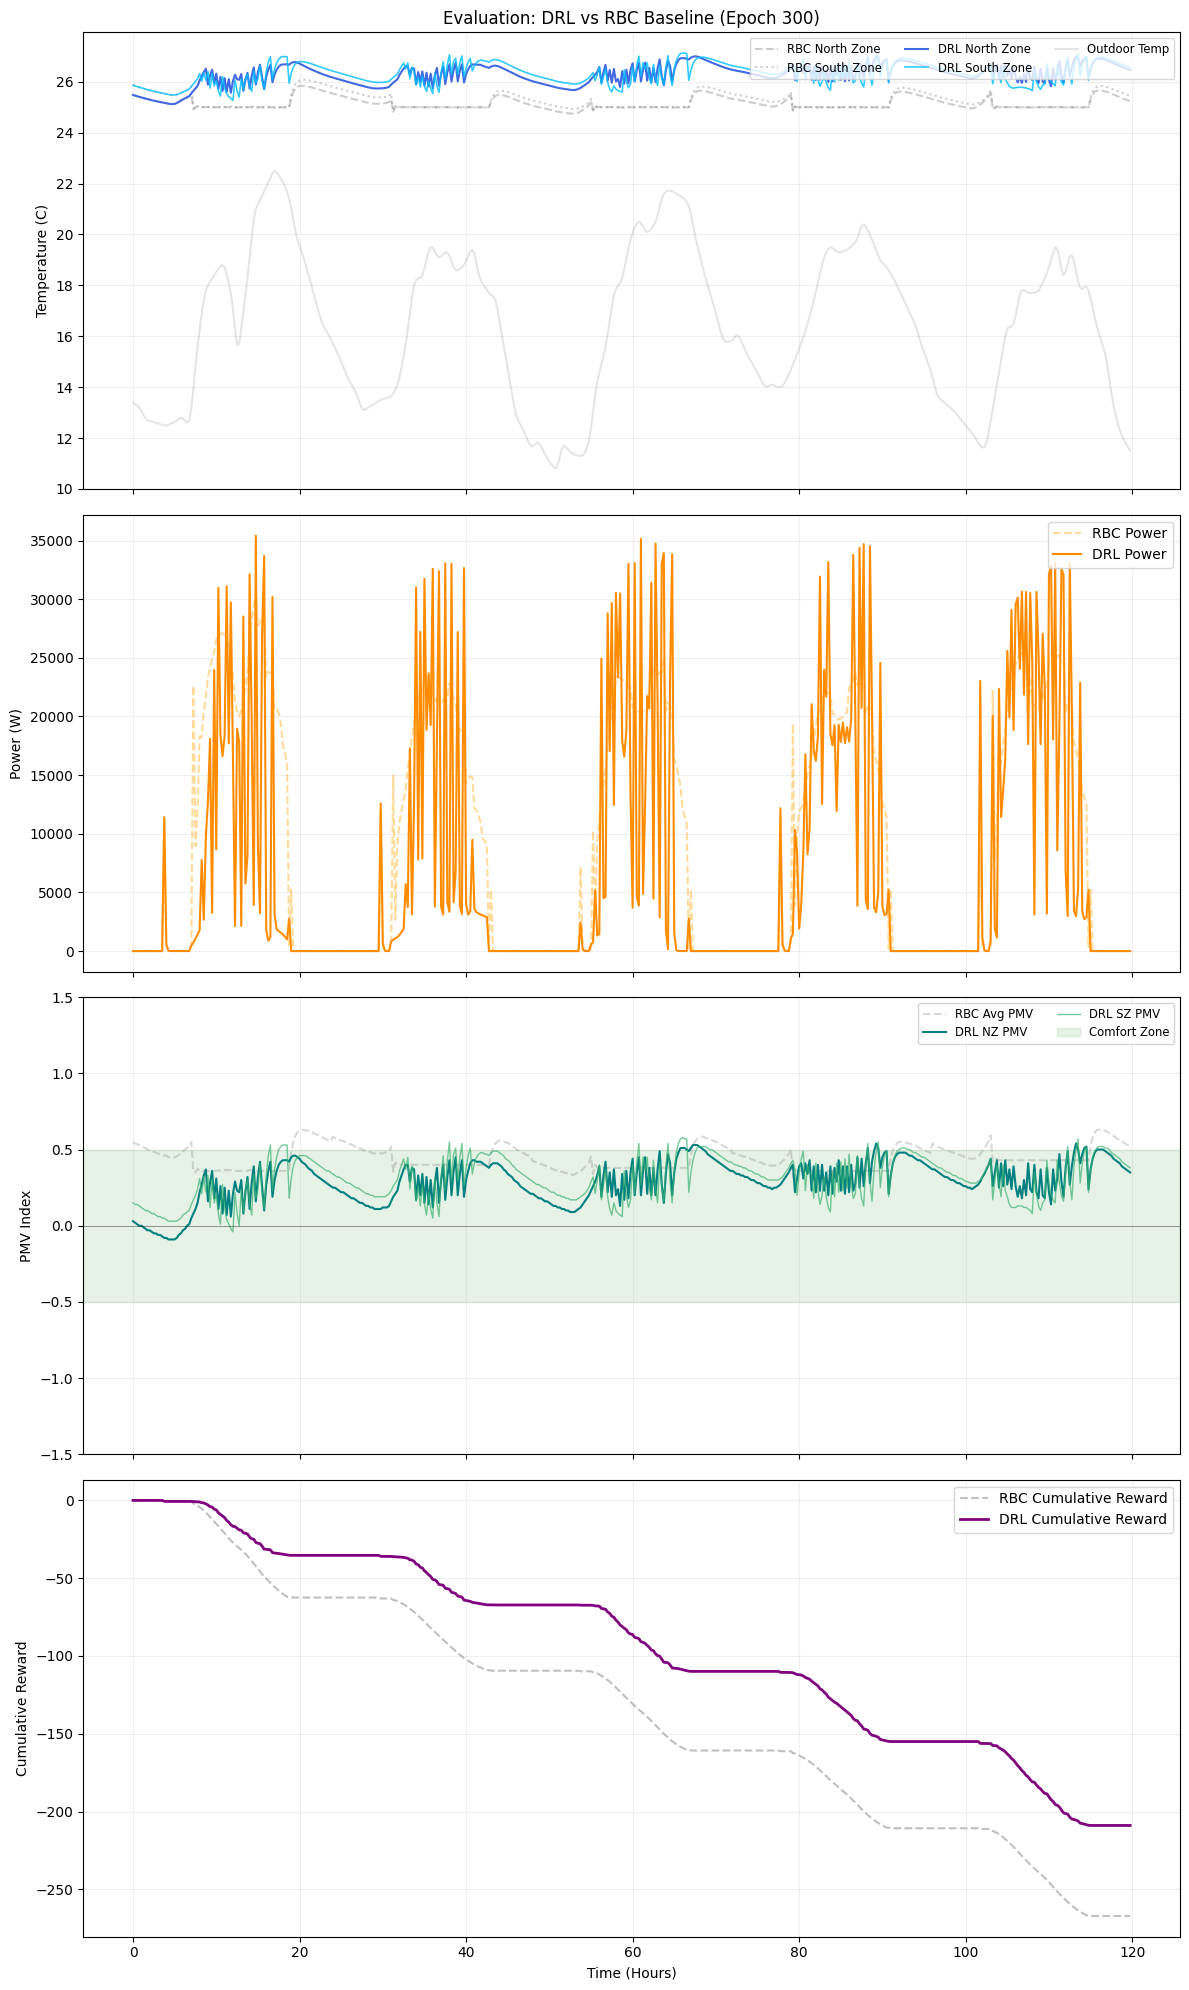

In [25]:
import os
import pandas as pd
from stable_baselines3 import PPO

import os
import gymnasium as gym
import torch
import requests
import pandas as pd
import numpy as np
import time
import traceback
import json
import gc
import subprocess
import shlex
import sys
import math
import matplotlib.pyplot as plt
from collections import deque
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import SubprocVecEnv
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common.monitor import Monitor

# 引入物理计算库
try:
    from pythermalcomfort.models import pmv_ppd_iso
except ImportError:
    pmv_ppd_iso = None

# ==============================================================================
# 1. 核心辅助类与工具函数 (工程健壮性升级)
# ==============================================================================

def global_linear_schedule(initial_value):
    """学习率线性衰减调度器"""
    def func(progress_remaining):
        return initial_value * (0.9 * progress_remaining + 0.1)
    return func

def safe_float(val, default=0.0):
    try:
        if val is None: return default
        f = float(val)
        return f if not (math.isnan(f) or math.isinf(f)) else default
    except: return default

def _make_request_with_retry(method, url, rank, context_msg, max_retries=5, **kwargs):
    """带指数退避和错误过滤的健壮请求"""
    for attempt in range(max_retries):
        try:
            kwargs.setdefault('timeout', 90)
            response = requests.request(method, url, **kwargs)
            if response.status_code == 200:
                return response.json() if response.content else {'status': 'success'}
            # 忽略重复停止导致的 400 错误
            if response.status_code == 400 and "stop" in url:
                return {'status': 'ignored_error'}
        except Exception as e:
            if attempt < max_retries - 1:
                time.sleep(2 * (attempt + 1))
            else:
                print(f"[Rank {rank}] {context_msg} 最终失败: {e}")
    return None

def get_dynamic_clo(daily_mean_tout, params):
    """动态服装热阻计算逻辑"""
    t = safe_float(daily_mean_tout, 20.0)
    if t < params['temp_low']: return params['winter_clo']
    elif t > params['temp_high']: return params['summer_clo']
    else:
        ratio = (t - params['temp_low']) / (params['temp_high'] - params['temp_low'])
        return params['winter_clo'] + ratio * (params['summer_clo'] - params['winter_clo'])

def calculate_pmv_state(t_air_k, phys_config, clo_val):
    """物理 PMV 计算接口"""
    if pmv_ppd_iso is None: return 0.0
    t_c = safe_float(t_air_k, 298.15) - 273.15
    try:
        res = pmv_ppd_iso(tdb=t_c, tr=t_c, vr=phys_config['air_velocity'],
                         rh=phys_config['relative_humidity'], met=phys_config['metabolic_rate'], 
                         clo=safe_float(clo_val, 0.5))
        return safe_float(res['pmv'] if isinstance(res, dict) else res.pmv, 0.0)
    except: return 0.0

class ForecastProvider:
    """预取预测数据辅助类：针对 2 区域进行扩展"""
    def __init__(self, config_obj):
        self.config = config_obj
        self.data = {}
        self.start_time = config_obj.START_DAY * 24 * 3600
        self.total_horizon = (config_obj.RBC_COLLECT_DAYS + 1) * 24 * 3600 

    def prefetch_all(self):
        print(f"\n[ForecastProvider] 正在预取全量数据 (Horizon: {self.total_horizon/3600:.1f}h)...")
        try:
            sel_url = f"{self.config.BOPTEST_URL}/testcases/{self.config.CASE_NAME}/select"
            res_sel = requests.post(sel_url, timeout=60).json()
            tid = res_sel['testid']
            
            requests.put(f"{self.config.BOPTEST_URL}/scenario/{tid}", json={'electricity_price': 'dynamic'})
            requests.put(f"{self.config.BOPTEST_URL}/initialize/{tid}", 
                         json={'start_time': self.start_time, 'warmup_period': 0})
            
            f_payload = {
                'point_names': self.config.FORECAST_POINTS,
                'horizon': self.total_horizon,
                'interval': self.config.CONTROL_PERIOD
            }
            res_f = requests.put(f"{self.config.BOPTEST_URL}/forecast/{tid}", json=f_payload, timeout=120).json()
            
            if 'payload' in res_f:
                self.data = {k: np.array([x if x is not None else 0.0 for x in v]) 
                             for k, v in res_f['payload'].items()}
                print(f"[ForecastProvider] 预取成功。点位: {list(self.data.keys())}")
            
            requests.put(f"{self.config.BOPTEST_URL}/stop/{tid}")
        except Exception as e:
            print(f"[ForecastProvider] 预取失败: {e}")
            raise e

    def get_local_forecast(self, current_time, point_name, horizon_steps=5):
        rel_time = current_time - self.start_time
        idx = int(max(0, rel_time // self.config.CONTROL_PERIOD))
        full_series = self.data.get(point_name)
        if full_series is None: return np.zeros(horizon_steps)
        vals = full_series[idx : idx + horizon_steps]
        if len(vals) < horizon_steps:
            padding = [vals[-1]] * (horizon_steps - len(vals)) if len(vals) > 0 else [0.0] * horizon_steps
            vals = np.concatenate([vals, padding])
        return vals

# ==============================================================================
# 2. 2-Zone 环境类封装 (集成动态热阻与健壮通信)
# ==============================================================================

class NormalizedObservationWrapper(gym.ObservationWrapper):
    def __init__(self, env):
        super().__init__(env)
        self.low_b, self.high_b = env.observation_space.low, env.observation_space.high
        self.range_b = self.high_b - self.low_b
        self.range_b[self.range_b == 0] = 1.0 
        self.observation_space = gym.spaces.Box(low=-1.0, high=1.0, shape=self.observation_space.shape, dtype=np.float32)
    def observation(self, obs):
        obs = np.nan_to_num(obs, nan=0.0)
        return np.nan_to_num(2.0 * (obs - self.low_b) / self.range_b - 1.0, nan=0.0)

# ==============================================================================
# 3. 回调函数 (集成分析表格、CSV接续、历史最佳保留)
# ==============================================================================

class SaveOnBestTrainingRewardCallback(BaseCallback):
    def __init__(self, config_obj, verbose=1):
        super().__init__(verbose)
        self.config = config_obj
        self.save_path = os.path.join(self.config.LOG_DIRS['drl_models'], 'best_model_ppo')
        self.log_path = os.path.join(self.config.LOG_DIRS['drl_models'], 'ppo_training_log.csv')
        self.best_mean_reward = -np.inf
        self.epoch_count = 0
        self.training_log = []
        
        # 尝试接续现有日志
        if os.path.exists(self.log_path):
            try:
                existing_df = pd.read_csv(self.log_path)
                self.training_log = existing_df.to_dict('records')
                self.epoch_count = len(self.training_log)
                if not existing_df.empty:
                    self.best_mean_reward = existing_df['MeanReward'].max()
                print(f"[Log] 发现现有日志，接续 Epoch {self.epoch_count + 1}。历史最高: {self.best_mean_reward:.3f}")
            except Exception as e:
                print(f"[Log] 接续日志失败 ({e})，将创建新日志。")
                
        self.epoch_infos = []
        self.start_time = time.time()

    def _on_step(self) -> bool:
        for info in self.locals['infos']:
            if 'rew_energy' in info: self.epoch_infos.append(info)
        return True

    def _on_rollout_end(self) -> bool:
        self.epoch_count += 1
        ep_rewards = [ep_info['r'] for ep_info in self.model.ep_info_buffer]
        mean_reward = np.mean(ep_rewards) if ep_rewards else -9999
        duration = time.time() - self.start_time

        # 打印详细诊断表格 (百分比占比)
        if self.epoch_infos:
            avg_cost = np.mean([x['phys_cost'] for x in self.epoch_infos])
            avg_pmv = np.mean([x['phys_pmv_abs'] for x in self.epoch_infos])
            avg_act = np.mean([x['phys_act_diff'] for x in self.epoch_infos])
            r_en = np.mean([x['rew_energy'] for x in self.epoch_infos])
            r_cm = np.mean([x['rew_comfort'] for x in self.epoch_infos])
            r_sm = np.mean([x['rew_smooth'] for x in self.epoch_infos])
            total_penalty = max(1e-6, r_en + r_cm + r_sm)

            print(f"\n[Epoch {self.epoch_count} Analysis]")
            print("-" * 75)
            print(f"| Component      | Raw Avg    | Weighted Avg (Contrib) |")
            print("-" * 75)
            print(f"| Energy         | $ {avg_cost:.4f}   | - {r_en:.3f}  ({r_en/total_penalty*100:.1f}%) |")
            print(f"| Comfort        | {avg_pmv:.3f} (PMV) | - {r_cm:.3f}  ({r_cm/total_penalty*100:.1f}%) |")
            print(f"| Smoothness     | {avg_act:.3f} (K)   | - {r_sm:.3f}  ({r_sm/total_penalty*100:.1f}%) |")
            print("-" * 75)
            print(f"| TOTAL REWARD   |            | {mean_reward:.3f} |")
            print("-" * 75)
            self.epoch_infos = []

        # 保存历史最佳模型
        if mean_reward > self.best_mean_reward:
            self.best_mean_reward = mean_reward
            self.model.save(self.save_path)
            print(f"[*] 发现更佳模型，已保存至: {self.save_path}")

        self.training_log.append({'Epoch': self.epoch_count, 'MeanReward': mean_reward, 'Time': duration})
        pd.DataFrame(self.training_log).to_csv(self.log_path, index=False)
        self.start_time = time.time()
        return True

# ==============================================================================
# 4. 评估逻辑与主循环
# ==============================================================================

def run_evaluation(model, epoch_idx, config_obj, fp, restart=False):
    """
    高级原位验证与对比绘图：
    展示 DRL 与 RBC 在温度、能耗、PMV 以及累计奖励上的全方位对比。
    """
    print(f"\n[Eval] 启动第 {epoch_idx} Epoch 的原位验证与直观对比...")
    
    # if restart:
    #     restart_boptest(config_obj)
    #     time.sleep(15)

    # 1. 初始化验证环境 (rank=-1 保证独立实例)
    raw_env = HydronicResidualEnv(config_obj, fp, is_validation=True, rank=-1)
    env = NormalizedObservationWrapper(raw_env)
    
    # 2. 加载 RBC 基准数据用于对比
    rbc_path = os.path.join(config_obj.LOG_DIRS['rbc_data'], 'rbc_validation_hydronic_2zone.csv')
    if not os.path.exists(rbc_path):
        print(f"[Error] 找不到 RBC 基准数据: {rbc_path}，请先运行 RBC 采集脚本。")
        return
    df_rbc = pd.read_csv(rbc_path)
    
    obs, _ = env.reset()
    done, logs = False, []
    
    # 3. 运行 DRL 验证仿真
    while not done:
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, term, trunc, info = env.step(action)
        done = term or trunc
        
        # 提取绘图所需信息
        info['reward_step'] = reward 
        info['power_total'] = raw_env.history_power[-1]
        info['pmv_nz_raw'] = raw_env.current_pmv_nz
        info['pmv_sz_raw'] = raw_env.current_pmv_sz
        # 同步室外温度记录
        info['temp_out'] = df_rbc['temp_out'].iloc[len(logs)] if len(logs) < len(df_rbc) else 0
        logs.append(info)
    
    df_drl = pd.DataFrame(logs)
    # 【核心修改】：取 DRL 和 RBC 数据的最小长度，确保绘图维度绝对一致
    min_len = min(len(df_drl), len(df_rbc))
    df_drl = df_drl.iloc[:min_len].copy()
    df_rbc_sync = df_rbc.iloc[:min_len].copy()
    time_h = np.arange(min_len) * config_obj.CONTROL_PERIOD / 3600
    
    # 4. 开启高级绘图 (4 面板对齐 RBC 风格)
    fig, axes = plt.subplots(4, 1, figsize=(12, 20), sharex=True)
    
    # --- Panel 1: 温度对比 (NZ & SZ) ---
    axes[0].plot(time_h, df_rbc_sync['temp_nz'], label='RBC North Zone', color='gray', linestyle='--', alpha=0.4)
    axes[0].plot(time_h, df_rbc_sync['temp_sz'], label='RBC South Zone', color='gray', linestyle=':', alpha=0.4)
    axes[0].plot(time_h, df_drl['phys_temp_nz'], label='DRL North Zone', color='royalblue', linewidth=1.5)
    axes[0].plot(time_h, df_drl['phys_temp_sz'], label='DRL South Zone', color='deepskyblue', linewidth=1.2, alpha=0.8)
    axes[0].plot(time_h, df_rbc_sync['temp_out'], label='Outdoor Temp', color='black', alpha=0.1, linestyle='-')
    axes[0].set_ylabel('Temperature (C)')
    axes[0].set_title(f'Evaluation: DRL vs RBC Baseline (Epoch {epoch_idx})')
    axes[0].legend(loc='upper right', ncol=3, fontsize='small')
    axes[0].grid(True, alpha=0.2)
    
    # --- Panel 2: 系统总功率对比 ---
    axes[1].plot(time_h, df_rbc_sync['power_total'], label='RBC Power', color='orange', linestyle='--', alpha=0.4)
    axes[1].plot(time_h, df_drl['power_total'], label='DRL Power', color='darkorange', linewidth=1.5)
    axes[1].set_ylabel('Power (W)')
    axes[1].legend(loc='upper right')
    axes[1].grid(True, alpha=0.2)
    
    # --- Panel 3: PMV 舒适度对比 (North & South) ---
    # 绘制 RBC 的 PMV 均值作为参考
    rbc_pmv_avg = (df_rbc_sync['pmv_nz'] + df_rbc_sync['pmv_sz']) / 2
    axes[2].plot(time_h, rbc_pmv_avg, label='RBC Avg PMV', color='gray', linestyle='--', alpha=0.3)
    axes[2].plot(time_h, df_drl['pmv_nz_raw'], label='DRL NZ PMV', color='teal', linewidth=1.5)
    axes[2].plot(time_h, df_drl['pmv_sz_raw'], label='DRL SZ PMV', color='mediumseagreen', linewidth=1.0, alpha=0.7)
    axes[2].axhspan(-0.5, 0.5, color='green', alpha=0.1, label='Comfort Zone') # 舒适带
    axes[2].axhline(0, color='black', linewidth=0.5, alpha=0.5)
    axes[2].set_ylabel('PMV Index')
    axes[2].set_ylim(-1.5, 1.5)
    axes[2].legend(loc='upper right', ncol=2, fontsize='small')
    axes[2].grid(True, alpha=0.2)
    
    # --- Panel 4: 累计奖励对比 (核心改进) ---
    axes[3].plot(time_h, df_rbc_sync['reward'].cumsum(), label='RBC Cumulative Reward', color='gray', linestyle='--', alpha=0.5)
    axes[3].plot(time_h, df_drl['reward_step'].cumsum(), label='DRL Cumulative Reward', color='purple', linewidth=2)
    axes[3].set_ylabel('Cumulative Reward')
    axes[3].set_xlabel('Time (Hours)')
    axes[3].legend(loc='upper right')
    axes[3].grid(True, alpha=0.2)
    
    plt.tight_layout()
    
    # 5. 保存图像与结果报告
    plot_filename = os.path.join(config_obj.LOG_DIRS['results'], f"eval_report_epoch_{epoch_idx}.png")
    plt.savefig(plot_filename, dpi=300)
    print(f"[Storage] 评估对比图已保存至: {plot_filename}")
    
    # 性能量化分析
    drl_cost = df_drl['phys_cost'].sum()
    rbc_cost = df_rbc_sync['cost'].sum()
    drl_reward = df_drl['reward_step'].sum()
    rbc_reward = df_rbc_sync['reward'].sum()
    savings = (1 - drl_cost / rbc_cost) * 100
    
    print(f"\n" + "="*50)
    print(f"      PERFORMANCE SUMMARY (Epoch {epoch_idx})      ")
    print(f"="*50)
    print(f"节能率 (Energy Savings)   : {savings:.2f}%")
    print(f"DRL 总奖励 (Total Reward) : {drl_reward:.2f}")
    print(f"RBC 总奖励 (Total Reward) : {rbc_reward:.2f}")
    print(f"奖励提升率 (Improvement)  : {((drl_reward - rbc_reward) / abs(rbc_reward)) * 100:.2f}%")
    print(f"="*50)

    if raw_env.testid: _make_request_with_retry('put', f"{config_obj.BOPTEST_URL}/stop/{raw_env.testid}", -1, "stop")

def restart_boptest(config_obj):
    cwd = "C:\\project1-boptest-master"
    subprocess.run(shlex.split("docker compose down -v"), cwd=cwd, stderr=subprocess.DEVNULL)
    subprocess.run(shlex.split("docker compose up web worker provision --scale worker=5 -d"), cwd=cwd, check=True)
    time.sleep(15)

def execute_standalone_evaluation(config_obj):
    """
    独立评估执行函数：
    增加了物理量感官检查，帮助识别是否存在“奖励欺诈”或“观测映射错误”。
    """
    print(f"\n{'='*20} 启动最佳模型手动评估 {'='*20}")
    
    # 1. 确定模型与日志路径
    model_path = os.path.join(config_obj.LOG_DIRS['drl_models'], 'best_model_ppo.zip')
    log_path = os.path.join(config_obj.LOG_DIRS['drl_models'], 'ppo_training_log.csv')
    
    if not os.path.exists(model_path):
        print(f"[Error] 找不到最佳模型文件: {model_path}")
        return

    # 2. 检查数据提供者 fp
    global fp
    if 'fp' not in globals() or fp is None:
        print("[System] 内存中未发现 fp 对象，正在重新初始化并预取数据...")
        try:
            fp = ForecastProvider(config_obj) 
            fp.prefetch_all()
        except NameError:
            print("[Fatal] 找不到 ForecastProvider 类定义，请确保已运行定义类单元格。")
            return

    # 3. 载入模型
    print(f"[*] 正在从磁盘加载最佳权重: {model_path}")
    best_model = PPO.load(model_path)

    # 4. 自动确定 Epoch 编号
    current_epoch = 0
    if os.path.exists(log_path):
        try:
            current_epoch = len(pd.read_csv(log_path))
            print(f"[*] 检测到历史进度: {current_epoch} Epochs")
        except: pass
    
    # 5. 执行验证与绘图
    try:
        # 这里会调用你定义的 run_evaluation
        # 注意：建议在 run_evaluation 结束后返回 df_drl 以便进行诊断
        run_evaluation(
            model=best_model, 
            epoch_idx=current_epoch, 
            config_obj=config_obj, 
            fp=fp, 
            restart=False 
        )
        
        # --- 诊断分析建议 ---
        print("\n" + "-"*30)
        print("      物理合理性诊断 (Sanity Check)      ")
        print("-"*30)
        print("[建议] 请观察生成的 PNG 图像：")
        print("1. Panel 1: DRL 温度是否始终在 30C 直线？如果是，节能率 76% 是靠牺牲舒适度换来的。")
        print("2. Panel 3: PMV 是否是 0 直线？如果是，说明 calculate_pmv 没拿到真实温度，代码有 bug。")
        print("3. 如果 PMV 在 0-0.5 波动且节能 76%，请检查 power_total 的计算单位是否从 W 变成了 kW。")
        print("-"*30)
        
        print("\n[Success] 独立验证任务完成，对比图表已更新。")
    except Exception as e:
        print(f"[Error] 评估过程发生异常: {e}")
        import traceback
        traceback.print_exc()

# --- 单元格执行入口 ---
if __name__ == '__main__':
    execute_standalone_evaluation(config)

In [18]:
class HydronicResidualEnv(gym.Env):
    def __init__(self, config_obj, forecast_provider, is_validation=False, rank=0):
        super().__init__()
        self.config, self.fp, self.rank = config_obj, forecast_provider, rank
        self.url = self.config.BOPTEST_URL
        self.env_step_counter = 0  # 新增：用于步数追踪
        self.debug_freq = 96        # 新增：每仿真 1 天(96步)打印一次快照
        
        start_day = self.config.START_DAY + 7 if is_validation else self.config.START_DAY
        self.start_time = start_day * 24 * 3600
        self.max_episode_steps = int(self.config.SIMULATION_DAYS * 24 * 3600 / self.config.CONTROL_PERIOD)
        
        self.action_space = gym.spaces.Box(low=-1.0, high=1.0, shape=(2,), dtype=np.float32)
        
        # 解析 Config 中的观测空间物理边界
        self.obs_low, self.obs_high = self._build_obs_bounds()
        self.observation_space = gym.spaces.Box(low=self.obs_low, high=self.obs_high, dtype=np.float32)
        
        self.testid = None
        self.history_temp_nz = deque(maxlen=5); self.history_temp_sz = deque(maxlen=5)
        self.history_act_nz = deque(maxlen=5); self.history_act_sz = deque(maxlen=5)
        self.history_power = deque(maxlen=5)

    def _build_obs_bounds(self):
        """
        根据 Config 中的列名生成对应的物理上下界 (low, high)。
        修正点：增强了对简化列名 (obs_T_nz, obs_act_nz) 的识别逻辑。
        """
        lows, highs = [], []
        for col in self.config.OBSERVATION_COLUMNS:
            # 移除前缀，提取核心特征
            base_key = col.replace('obs_', '')
            
            # === 修正后的匹配逻辑 ===
            # 1. 显式匹配特殊物理量
            if 'Price' in base_key:
                key = 'Price'
            elif 'Occ' in base_key:
                key = 'Occ'
            elif 'HGloHor' in base_key:
                key = 'HGloHor'
            elif 'TDryBul' in base_key:
                key = 'TDryBul'
            elif 'pmv' in base_key:
                key = 'pmv'
            elif 'pow' in base_key:
                key = 'pow'
            # 2. 泛化匹配温度 (T_nz, T_sz, act_nz 等)
            # 只要包含 T_ 或 act_，且已经被前面的特殊量排除，就认为是室内/动作温度
            elif ('T_' in base_key or 'act_' in base_key):
                key = 'T'
            else:
                # 3. 兜底逻辑 (尝试剥离后缀)
                key = base_key.split('_past')[0].split('_future')[0].split('_current')[0]
            # =======================

            # 从 Config 获取范围，默认为 (0, 1)
            r = self.config.OBSERVATIONS_CONFIG.get(key, (0.0, 1.0))
            lows.append(r[0])
            highs.append(r[1])
            
        return np.array(lows, dtype=np.float32), np.array(highs, dtype=np.float32)

    def _get_observations(self, y):
        """
        根据 BOPTEST 返回的 y 构建观测向量。
        修正点：
        1. 历史队列索引偏移 (P1 应取 -2，因为 -1 是当前)。
        2. 室外温度 (TDryBul) 从 C 转换为 K。
        """
        cur_t = y.get('time', self.start_time)
        
        # --- 内部辅助函数：正确获取历史数据 ---
        # steps_back=1 代表 P1 (上一步), steps_back=2 代表 P2
        def get_hist(buffer, steps_back, default_val=298.15):
            # 因为 step() 中先执行了 append，所以 buffer[-1] 是当前步 (t)
            # 历史数据应该是 buffer[-(1 + steps_back)]
            idx = -(1 + steps_back)
            if len(buffer) >= (1 + steps_back):
                return buffer[idx]
            return default_val

        # 建立映射字典
        raw = {
            'obs_sin_time': np.sin(2*np.pi*(cur_t%86400)/86400),
            'obs_cos_time': np.cos(2*np.pi*(cur_t%86400)/86400),
            
            # --- North Zone (Current + History) ---
            'obs_T_nz': y.get('structure_reaTZonNz_y', 298.15),
            'obs_T_nz_p1': get_hist(self.history_temp_nz, 1), # P1 取倒数第2个
            'obs_T_nz_p2': get_hist(self.history_temp_nz, 2), # P2 取倒数第3个
            'obs_T_nz_p3': get_hist(self.history_temp_nz, 3),
            'obs_T_nz_p4': get_hist(self.history_temp_nz, 4),
            
            # --- South Zone (Current + History) ---
            'obs_T_sz': y.get('structure_reaTZonSz_y', 298.15),
            'obs_T_sz_p1': get_hist(self.history_temp_sz, 1),
            'obs_T_sz_p2': get_hist(self.history_temp_sz, 2),
            'obs_T_sz_p3': get_hist(self.history_temp_sz, 3),
            'obs_T_sz_p4': get_hist(self.history_temp_sz, 4),

            # --- System & PMV ---
            'obs_pmv_nz': self.current_pmv_nz,
            'obs_pmv_sz': self.current_pmv_sz,
            'obs_act_nz_p1': get_hist(self.history_act_nz, 1),
            'obs_act_sz_p1': get_hist(self.history_act_sz, 1),
            
            # Power 归一化 (Power 默认为 0)
            'obs_pow_p1': get_hist(self.history_power, 1, 0.0)/self.config.MAX_SYSTEM_POWER,
            'obs_pow_p2': get_hist(self.history_power, 2, 0.0)/self.config.MAX_SYSTEM_POWER,
            'obs_pow_p3': get_hist(self.history_power, 3, 0.0)/self.config.MAX_SYSTEM_POWER,
            'obs_pow_p4': get_hist(self.history_power, 4, 0.0)/self.config.MAX_SYSTEM_POWER,
        }
        
        # --- Forecasts 处理 ---
        forecast_map = {
            'Occupancy[nZ]': 'obs_Occ_nz', 
            'Occupancy[sZ]': 'obs_Occ_sz',
            'PriceElectricPowerDynamic': 'obs_Price',
            'TDryBul': 'obs_TDryBul',
            'HGloHor': 'obs_HGloHor'
        }
        
        for p_bop, p_obs in forecast_map.items():
            vals = self.fp.get_local_forecast(cur_t, p_bop, 5)
            
            # === 单位修正：TDryBul C -> K ===
            if p_bop == 'TDryBul':
                # 如果数值远小于 100 (比如 15C)，说明是摄氏度，转换为 K
                if np.mean(vals) < 100.0:
                    vals = vals + 273.15
            # ==============================

            raw[f'{p_obs}_0'] = vals[0]
            for i in range(1, 5):
                raw[f'{p_obs}_f{i}'] = vals[i]
                
        # 按照 Config 顺序组装向量
        obs_vector = []
        for col in self.config.OBSERVATION_COLUMNS:
            val = raw.get(col, 0.0)
            obs_vector.append(val)
            
        # DEBUG: 只有在检测到异常 NaN 时才打印，避免刷屏
        obs_np = np.array(obs_vector, dtype=np.float32)
        if self.env_step_counter % self.debug_freq == 0:
            if np.isnan(obs_np).any():
                print(f"[Rank {self.rank}][CRITICAL] Detected NaN in Observation!")
            
        return obs_np

    def reset(self, seed=None, options=None):
        if self.testid is None:
            res = _make_request_with_retry('post', f"{self.url}/testcases/{self.config.CASE_NAME}/select", self.rank, "select")
            self.testid = res['testid']
            _make_request_with_retry('put', f"{self.url}/step/{self.testid}", self.rank, "step", json={'step': self.config.CONTROL_PERIOD})
            _make_request_with_retry('put', f"{self.url}/scenario/{self.testid}", self.rank, "scen", json={'electricity_price': 'dynamic'})
            
        res_init = _make_request_with_retry('put', f"{self.url}/initialize/{self.testid}", self.rank, "init", 
                                          json={'start_time': self.start_time, 'warmup_period': 7*24*3600})
        y = res_init['payload']
        self.current_step, self.current_clo = 0, 0.5
        self.current_pmv_nz = 0.0; self.current_pmv_sz = 0.0
        self.history_temp_nz.clear(); self.history_temp_sz.clear()
        self.history_act_nz.clear(); self.history_act_sz.clear(); self.history_power.clear()
        
        self.history_temp_nz.append(y.get('structure_reaTZonNz_y', 298.15))
        self.history_temp_sz.append(y.get('structure_reaTZonSz_y', 298.15))
        self.history_act_nz.append(298.15); self.history_act_sz.append(298.15); self.history_power.append(0.0)
        return self._get_observations(y), {}

    def step(self, action_norm):
        cur_t = self.start_time + self.current_step * self.config.CONTROL_PERIOD
        
        # --- 1. 固定基准逻辑 (不再随 RBC 跳变) ---
        # 统一使用 25.0 C (298.15 K) 作为 DRL 的“零位”
        absolute_base_k = 298.15 
        
        # --- 2. 应用残差动作并进行严格限幅 ---
        # 范围：25C +/- 5C = [20C, 30C]，即 [293.15K, 303.15K]
        # 这样既符合你的逻辑，又绝对不会触发 BOPTEST 的 303.15K 上限警告
        set_nz_k = np.clip(absolute_base_k + float(action_norm[0]) * self.config.RESIDUAL_ACTION_SCALE, 293.15, 303.15)
        set_sz_k = np.clip(absolute_base_k + float(action_norm[1]) * self.config.RESIDUAL_ACTION_SCALE, 293.15, 303.15)
        
        # --- 3. 修正加热设定点单位 (15C -> 288.15K) ---
        heat_setpoint_k = self.config.FIXED_HEATING_SETPOINT + 273.15
        
        u = {
            'bms_oveTZonSetMaxNz_u': set_nz_k, 
            'bms_oveTZonSetMaxNz_activate': 1,
            'bms_oveTZonSetMaxSz_u': set_sz_k, 
            'bms_oveTZonSetMaxSz_activate': 1,
            # 确保不低于该案例的最小值约束
            'bms_oveTZonSetMinNz_u': max(heat_setpoint_k, 288.15), 
            'bms_oveTZonSetMinNz_activate': 1,
            'bms_oveTZonSetMinSz_u': max(heat_setpoint_k, 283.15), 
            'bms_oveTZonSetMinSz_activate': 1,
            # # --- 新增：固定供水温度控制 ---
            # # 1. 生产侧 (Plant)
            # 'bms_oveTProHea_u': 318.15, 'bms_oveTProHea_activate': 1, # 热泵固定 45C
            # 'bms_oveTProCoo_u': 280.15, 'bms_oveTProCoo_activate': 1, # 冷机固定 7C
            
            # # 2. 末端分配侧 (Emission/FCU)
            # # 固定供水温度可以覆盖掉模型内置的“室外温度补偿曲线”
            # 'bms_oveTSupEmiHeaNz_u': 313.15, 'bms_oveTSupEmiHeaNz_activate': 1, # 北区加热 40C
            # 'bms_oveTSupEmiHeaSz_u': 313.15, 'bms_oveTSupEmiHeaSz_activate': 1, # 南区加热 40C
            # 'bms_oveTSupEmiCooNz_u': 283.15, 'bms_oveTSupEmiCooNz_activate': 1, # 北区冷却 10C
            # 'bms_oveTSupEmiCooSz_u': 283.15, 'bms_oveTSupEmiCooSz_activate': 1, # 南区冷却 10C
        }
        
        # 执行环境推进
        res = _make_request_with_retry('post', f"{self.url}/advance/{self.testid}", self.rank, "adv", json=u)
        y_next = res['payload']
        
        # --- 4. 物理指标计算 (Reward 逻辑依然需要 Occupancy 来判定舒适度) ---
        p_tot = (y_next.get('heating_cooling_reaPProCoo_y', 0) + y_next.get('heating_cooling_reaPProHea_y', 0) +
                 y_next.get('heating_cooling_reaPFcuNz_y', 0) + y_next.get('heating_cooling_reaPFcuSz_y', 0))
        
        occ_nz = self.fp.get_local_forecast(cur_t, 'Occupancy[nZ]', 1)[0]
        occ_sz = self.fp.get_local_forecast(cur_t, 'Occupancy[sZ]', 1)[0]
        price = self.fp.get_local_forecast(cur_t, 'PriceElectricPowerDynamic', 1)[0]
        cost = (p_tot * self.config.CONTROL_PERIOD / 3600000.0) * price
        
        # PMV 状态更新
        self.current_pmv_nz = calculate_pmv_state(y_next['structure_reaTZonNz_y'], self.config.PHYSICAL_CONFIG, self.current_clo)
        self.current_pmv_sz = calculate_pmv_state(y_next['structure_reaTZonSz_y'], self.config.PHYSICAL_CONFIG, self.current_clo)
        
        # --- 5. 奖励函数 (单区域归一化) ---
        w, n = self.config.REWARD_WEIGHTS, self.config.N_ZONES
        en_r = (cost / n) * w['scaler_energy']
        
        # 舒适度惩罚：只有在有人时才罚款
        p_nz = max(0, abs(self.current_pmv_nz)-0.4)**2 if occ_nz > 0 else 0
        p_sz = max(0, abs(self.current_pmv_sz)-0.4)**2 if occ_sz > 0 else 0
        cm_r = ((p_nz + p_sz) / n) * w['scaler_comfort']
        
        # 平滑度惩罚：相对于上一时刻的设定值
        du_nz = abs(set_nz_k - self.history_act_nz[-1])
        du_sz = abs(set_sz_k - self.history_act_sz[-1])
        sm_r = ((du_nz + du_sz) / n) * w['scaler_smooth']
        
        reward = -1.0 * (w['w_energy']*en_r + w['w_comfort']*cm_r + w['w_smooth']*sm_r)

        # --- 2. 实时快照打印 ---
        if self.env_step_counter % self.debug_freq == 0:
            print(f"\n>>> [Rank {self.rank}][Step {self.env_step_counter}] Action Snapshot:")
            print(f"    Raw Action: NZ={action_norm[0]:.2f}, SZ={action_norm[1]:.2f}")
            print(f"    Mapped SP:  NZ={set_nz_k-273.15:.2f}C, SZ={set_sz_k-273.15:.2f}C")
            print(f"    Current PMV: NZ={self.current_pmv_nz:.2f}, SZ={self.current_pmv_sz:.2f}")
            print(f"    Rew Comp:   Energy={-en_r*w['w_energy']:.3f}, Comfort={-cm_r*w['w_comfort']:.3f}, Smooth={-sm_r*w['w_smooth']:.3f}")
            print(f"    Total Rew:  {reward:.3f}")

        self.env_step_counter += 1
        
        # 更新队列
        self.history_temp_nz.append(y_next['structure_reaTZonNz_y']); self.history_temp_sz.append(y_next['structure_reaTZonSz_y'])
        self.history_act_nz.append(set_nz_k); self.history_act_sz.append(set_sz_k); self.history_power.append(p_tot)
        self.current_step += 1
        
        info = {'rew_energy': w['w_energy']*en_r, 'rew_comfort': w['w_comfort']*cm_r, 'rew_smooth': w['w_smooth']*sm_r,
                'phys_cost': cost, 'phys_pmv_abs': (abs(self.current_pmv_nz)+abs(self.current_pmv_sz))/2,
                'phys_temp_nz': y_next['structure_reaTZonNz_y']-273.15, 'phys_temp_sz': y_next['structure_reaTZonSz_y']-273.15,
                'phys_act_diff': (du_nz + du_sz)/2}
        
        return self._get_observations(y_next), reward, False, self.current_step >= self.max_episode_steps, info

In [19]:
import numpy as np
import pandas as pd
import time
import requests

def verify_environment_logic():
    print("="*60)
    print("STARTING ENVIRONMENT SANITY CHECK (验证环境逻辑)")
    print("="*60)

    # --- 1. 初始化环境 ---
    print("\n[1] Initializing Environment...")
    try:
        # 实例化配置和预测器
        # 注意：这里假设 Config 类已经在你的上下文中定义
        test_config = Config() 
        fp = ForecastProvider(test_config)
        fp.prefetch_all() # 获取预测数据

        # 创建环境 (Rank 99 用于测试，避免冲突)
        raw_env = HydronicResidualEnv(test_config, fp, is_validation=True, rank=99)
        env = NormalizedObservationWrapper(raw_env)
        
        # 重置环境
        obs, _ = env.reset()
        print("  -> Environment reset successful.")
        print(f"  -> Observation Shape: {obs.shape} (Expected: {len(test_config.OBSERVATION_COLUMNS)})")
        assert obs.shape[0] == len(test_config.OBSERVATION_COLUMNS), "Observation dimension mismatch!"
    except Exception as e:
        print(f"  -> [CRITICAL FAIL] Init failed: {e}")
        return

    # --- 2. 动作映射验证 (Action Mapping) ---
    print("\n[2] Verifying Action Mapping (Residual Logic)...")
    print(f"  -> Base Setpoint: {test_config.BASE_COOLING_SETPOINT} C")
    print(f"  -> Scale: +/- {test_config.RESIDUAL_ACTION_SCALE} K")
    
    # 定义测试动作序列: [Zero(基准), Max(上限), Min(下限)]
    test_actions = [
        {'u': [0.0, 0.0],   'desc': 'Zero Action (Base)', 'expect_setpoint': 25.0},
        {'u': [1.0, 1.0],   'desc': 'Max Positive (+5K)', 'expect_setpoint': 30.0},
        {'u': [-1.0, -1.0], 'desc': 'Max Negative (-5K)', 'expect_setpoint': 20.0},
    ]

    for i, case in enumerate(test_actions):
        action = np.array(case['u'], dtype=np.float32)
        obs, rew, done, trunc, info = env.step(action)
        
        # 从 raw_env 的历史记录中获取实际下发的物理设定点 (Kelvin -> Celsius)
        # history_act_nz[-1] 存储的是上一步的设定点
        actual_set_nz_k = raw_env.history_act_nz[-1]
        actual_set_sz_k = raw_env.history_act_sz[-1]
        actual_set_nz_c = actual_set_nz_k - 273.15
        
        # 验证误差
        diff = abs(actual_set_nz_c - case['expect_setpoint'])
        status = "PASS" if diff < 0.1 else "FAIL"
        
        print(f"  Step {i+1} [{case['desc']}]:")
        print(f"    Input Action: {case['u']}")
        print(f"    Expected SP : {case['expect_setpoint']:.2f} C")
        print(f"    Actual SP   : {actual_set_nz_c:.2f} C (North), {actual_set_sz_k-273.15:.2f} C (South)")
        print(f"    Result      : [{status}]")

    # --- 3. 历史队列逻辑验证 (History Queue) ---
    print("\n[3] Verifying Observation History Queue...")
    # 获取 obs_T_nz 和 obs_T_nz_p1 的索引
    cols = test_config.OBSERVATION_COLUMNS
    idx_now = cols.index('obs_T_nz')
    idx_prev = cols.index('obs_T_nz_p1')
    
    # 记录当前的 T_nz (归一化值)
    val_now_step_3 = obs[idx_now]
    print(f"  Current Step (t)   -> obs_T_nz    : {val_now_step_3:.4f}")
    
    # 执行下一步
    obs_next, _, _, _, _ = env.step(np.array([0.0, 0.0], dtype=np.float32))
    val_prev_step_4 = obs_next[idx_prev]
    print(f"  Next Step    (t+1) -> obs_T_nz_p1 : {val_prev_step_4:.4f}")
    
    # 比较 t 时刻的 T_nz 是否等于 t+1 时刻的 T_nz_p1
    if abs(val_now_step_3 - val_prev_step_4) < 1e-5:
        print("  -> [PASS] History shift logic confirms (T_nz moved to T_nz_p1 correctly).")
    else:
        print(f"  -> [FAIL] History logic mismatch! Diff: {abs(val_now_step_3 - val_prev_step_4)}")

    # --- 4. 归一化边界检查 ---
    print("\n[4] Verifying Normalization Bounds...")
    # 检查 obs 是否都在 [-1, 1] 范围内 (允许微小误差)
    max_val = np.max(np.abs(obs_next))
    if max_val <= 1.0001:
        print(f"  -> [PASS] All observations within range [-1, 1]. Max abs val: {max_val:.4f}")
    else:
        # 找出越界的列
        print(f"  -> [WARNING] Some observations out of bound. Max: {max_val:.4f}")
        for idx, val in enumerate(obs_next):
            if abs(val) > 1.0:
                print(f"     - Col '{cols[idx]}': {val:.4f}")

    # --- 5. 物理合理性检查 (Physics Info) ---
    print("\n[5] Verifying Physical Metrics in Info...")
    print(f"  -> Current Outdoor Temp (Forecast): {raw_env.fp.get_local_forecast(raw_env.start_time + raw_env.current_step*900, 'TDryBul', 1)[0]-273.15:.2f} C")
    print(f"  -> Info Content: {list(info.keys())}")
    
    if info['phys_cost'] >= 0:
        print(f"  -> [PASS] Cost is non-negative: ${info['phys_cost']:.4f}")
    
    # 检查 PMV 是否是数字
    if not np.isnan(info['phys_pmv_abs']):
        print(f"  -> [PASS] PMV calculation valid: {info['phys_pmv_abs']:.4f}")
    else:
        print("  -> [FAIL] PMV is NaN. Check pythermalcomfort installation.")

    # --- 停止测试 ---
    print("\n" + "="*60)
    print("SANITY CHECK COMPLETE")
    print("="*60)
    # 停止 BOPTEST 实例以免占用端口
    if raw_env.testid:
        requests.put(f"{test_config.BOPTEST_URL}/stop/{raw_env.testid}")

# 执行验证
if __name__ == "__main__":
    verify_environment_logic()

STARTING ENVIRONMENT SANITY CHECK (验证环境逻辑)

[1] Initializing Environment...

[ForecastProvider] 正在预取全量数据 (Horizon: 360.0h)...
[ForecastProvider] 预取成功。点位: ['time', 'Occupancy[nZ]', 'Occupancy[sZ]', 'PriceElectricPowerDynamic', 'TDryBul', 'HGloHor']
  -> Environment reset successful.
  -> Observation Shape: (45,) (Expected: 45)

[2] Verifying Action Mapping (Residual Logic)...
  -> Base Setpoint: 25.0 C
  -> Scale: +/- 5.0 K

>>> [Rank 99][Step 0] Action Snapshot:
    Raw Action: NZ=0.00, SZ=0.00
    Mapped SP:  NZ=25.00C, SZ=25.00C
    Current PMV: NZ=0.03, SZ=0.15
    Rew Comp:   Energy=-2.274, Comfort=-0.000, Smooth=-0.000
    Total Rew:  -2.274
  Step 1 [Zero Action (Base)]:
    Input Action: [0.0, 0.0]
    Expected SP : 25.00 C
    Actual SP   : 25.00 C (North), 25.00 C (South)
    Result      : [PASS]
  Step 2 [Max Positive (+5K)]:
    Input Action: [1.0, 1.0]
    Expected SP : 30.00 C
    Actual SP   : 30.00 C (North), 30.00 C (South)
    Result      : [PASS]
  Step 3 [Max Negativ

# MAPPO


[ForecastProvider] 正在预取全量数据 (Horizon: 360.0h)...
[ForecastProvider] 预取成功。点位: ['time', 'Occupancy[nZ]', 'Occupancy[sZ]', 'PriceElectricPowerDynamic', 'TDryBul', 'HGloHor']

[System] 正在创建 4 个并行环境...
  Env[0] 创建完成 (rank=0)
  Env[1] 创建完成 (rank=1)
  Env[2] 创建完成 (rank=2)
  Env[3] 创建完成 (rank=3)
[MAPPO] 使用设备: cpu, 并行环境数: 4
[MAPPO] Actor 'nz': obs_dim=33, params=75778
[MAPPO] Actor 'sz': obs_dim=33, params=75778
[MAPPO] Critic: global_obs_dim=45, params=78849

  MAPPO Training: 300 Epochs remaining
  Target: 300 | Current: 0
  Rollout: 480 steps x 4 envs = 1920 steps/epoch


>>> [Rank 0][Step 0] MAPPO Action Snapshot:
    Raw Action: NZ=0.02, SZ=0.11
    Mapped SP:  NZ=25.12C, SZ=25.54C
    Current PMV: NZ=0.74, SZ=0.95
    Rew Comp:   Energy=-0.271, Comfort=-0.000, Smooth=-0.006
    Total Rew:  -0.276

>>> [Rank 1][Step 0] MAPPO Action Snapshot:
    Raw Action: NZ=0.31, SZ=0.26
    Mapped SP:  NZ=26.57C, SZ=26.29C
    Current PMV: NZ=0.74, SZ=0.95
    Rew Comp:   Energy=-0.271, Comfort=-0.000

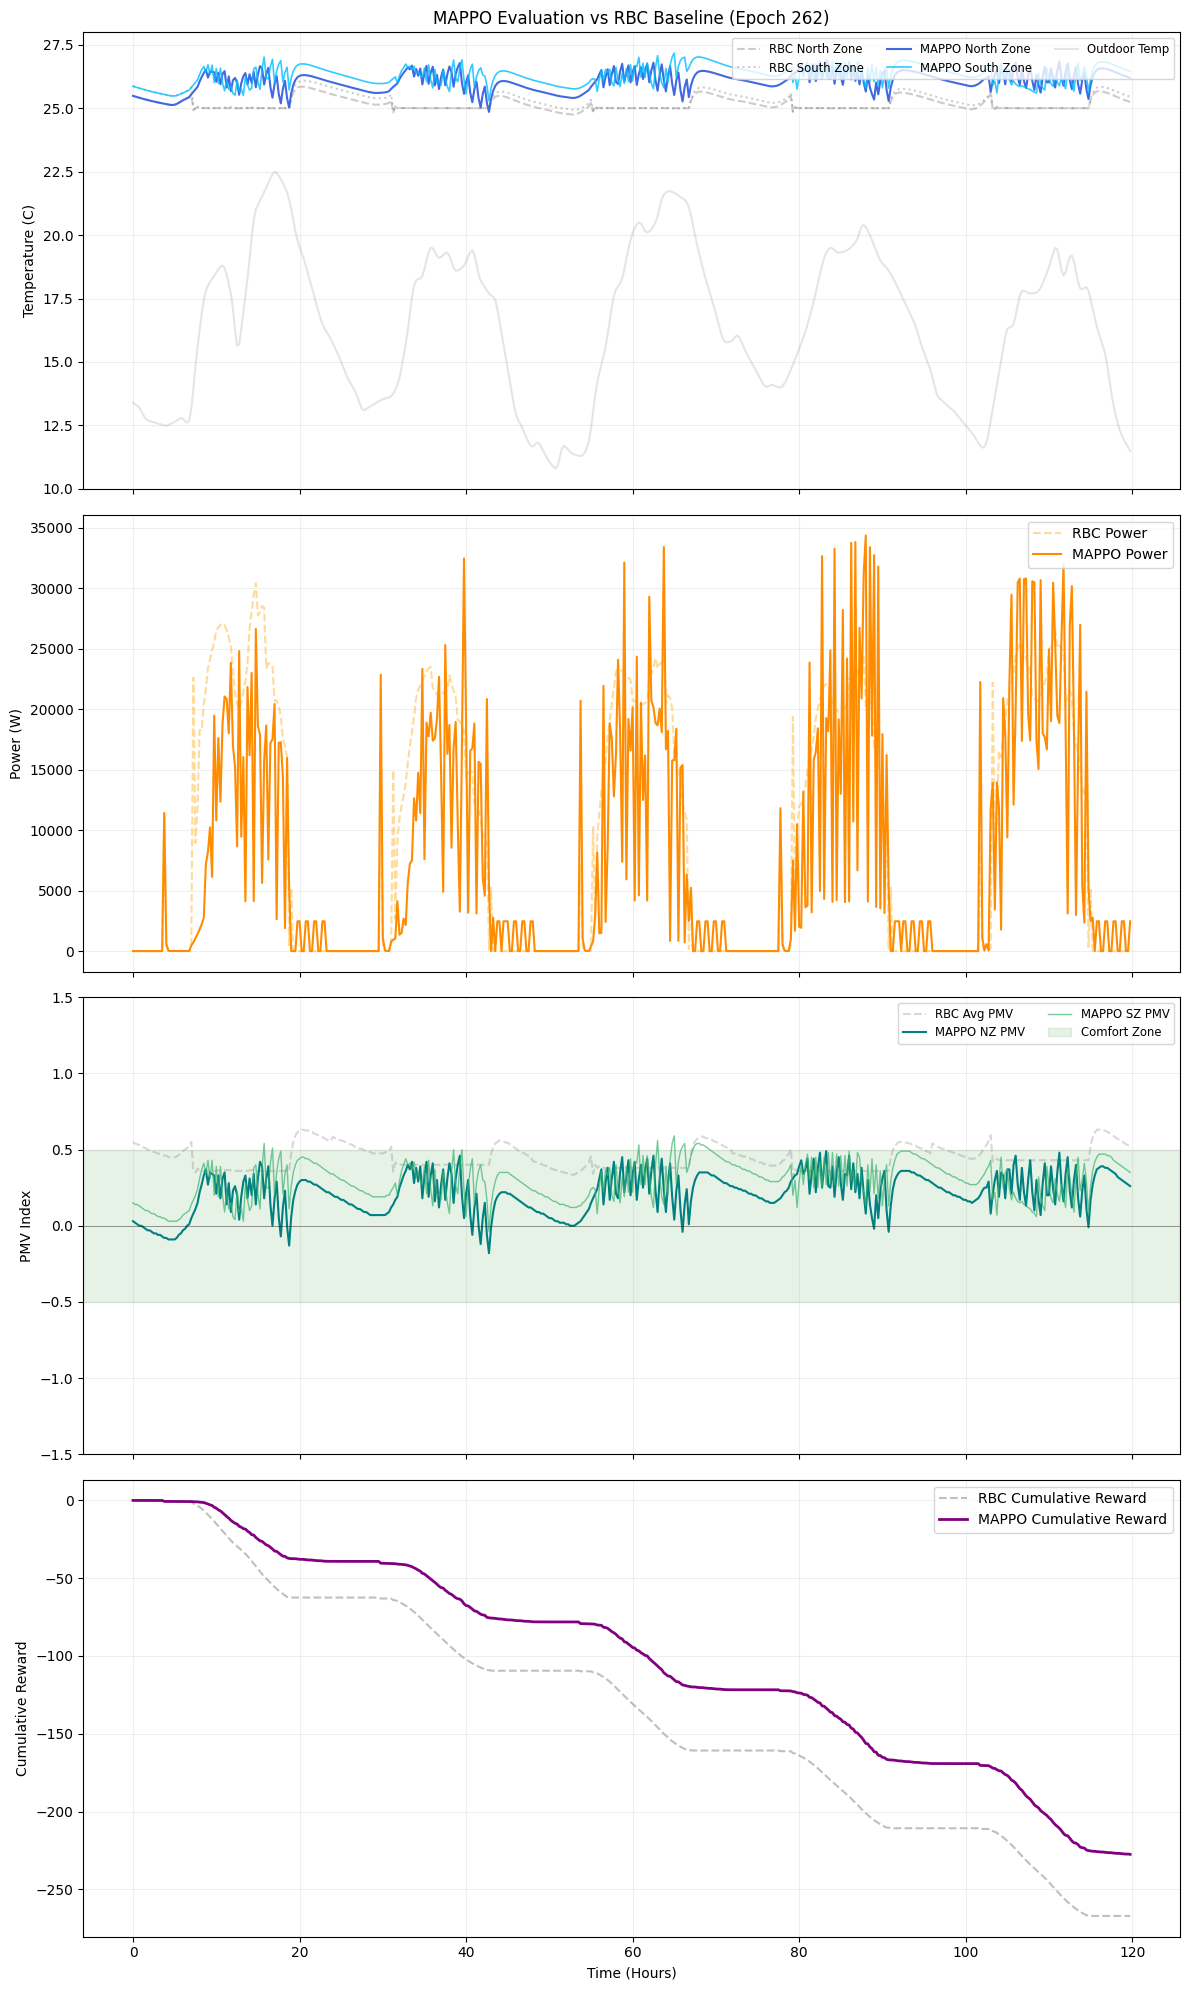

In [15]:
import os
import gymnasium as gym
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Normal
import requests
import pandas as pd
import numpy as np
import time
import traceback
import json
import gc
import sys
import math
import matplotlib.pyplot as plt
from collections import deque
from concurrent.futures import ThreadPoolExecutor, as_completed

# 引入物理计算库
try:
    from pythermalcomfort.models import pmv_ppd_iso
except ImportError:
    pmv_ppd_iso = None

# ==============================================================================
# 1. 核心辅助类与工具函数 (与原版完全一致)
# ==============================================================================

def safe_float(val, default=0.0):
    try:
        if val is None: return default
        f = float(val)
        return f if not (math.isnan(f) or math.isinf(f)) else default
    except: return default

def _make_request_with_retry(method, url, rank, context_msg, max_retries=5, **kwargs):
    """带指数退避和错误过滤的健壮请求"""
    for attempt in range(max_retries):
        try:
            kwargs.setdefault('timeout', 90)
            response = requests.request(method, url, **kwargs)
            if response.status_code == 200:
                return response.json() if response.content else {'status': 'success'}
            if response.status_code == 400 and "stop" in url:
                return {'status': 'ignored_error'}
        except Exception as e:
            if attempt < max_retries - 1:
                time.sleep(2 * (attempt + 1))
            else:
                print(f"[Rank {rank}] {context_msg} 最终失败: {e}")
    return None

def get_dynamic_clo(daily_mean_tout, params):
    """动态服装热阻计算逻辑"""
    t = safe_float(daily_mean_tout, 20.0)
    if t < params['temp_low']: return params['winter_clo']
    elif t > params['temp_high']: return params['summer_clo']
    else:
        ratio = (t - params['temp_low']) / (params['temp_high'] - params['temp_low'])
        return params['winter_clo'] + ratio * (params['summer_clo'] - params['winter_clo'])

def calculate_pmv_state(t_air_k, phys_config, clo_val):
    """物理 PMV 计算接口"""
    if pmv_ppd_iso is None: return 0.0
    t_c = safe_float(t_air_k, 298.15) - 273.15
    try:
        res = pmv_ppd_iso(tdb=t_c, tr=t_c, vr=phys_config['air_velocity'],
                         rh=phys_config['relative_humidity'], met=phys_config['metabolic_rate'], 
                         clo=safe_float(clo_val, 0.5))
        return safe_float(res['pmv'] if isinstance(res, dict) else res.pmv, 0.0)
    except: return 0.0


class ForecastProvider:
    """预取预测数据辅助类：针对 2 区域进行扩展 (与原版完全一致)"""
    def __init__(self, config_obj):
        self.config = config_obj
        self.data = {}
        self.start_time = config_obj.START_DAY * 24 * 3600
        self.total_horizon = (config_obj.RBC_COLLECT_DAYS + 1) * 24 * 3600 

    def prefetch_all(self):
        print(f"\n[ForecastProvider] 正在预取全量数据 (Horizon: {self.total_horizon/3600:.1f}h)...")
        try:
            sel_url = f"{self.config.BOPTEST_URL}/testcases/{self.config.CASE_NAME}/select"
            res_sel = requests.post(sel_url, timeout=60).json()
            tid = res_sel['testid']
            
            requests.put(f"{self.config.BOPTEST_URL}/scenario/{tid}", json={'electricity_price': 'dynamic'})
            requests.put(f"{self.config.BOPTEST_URL}/initialize/{tid}", 
                         json={'start_time': self.start_time, 'warmup_period': 0})
            
            f_payload = {
                'point_names': self.config.FORECAST_POINTS,
                'horizon': self.total_horizon,
                'interval': self.config.CONTROL_PERIOD
            }
            res_f = requests.put(f"{self.config.BOPTEST_URL}/forecast/{tid}", json=f_payload, timeout=120).json()
            
            if 'payload' in res_f:
                self.data = {k: np.array([x if x is not None else 0.0 for x in v]) 
                             for k, v in res_f['payload'].items()}
                print(f"[ForecastProvider] 预取成功。点位: {list(self.data.keys())}")
            
            requests.put(f"{self.config.BOPTEST_URL}/stop/{tid}")
        except Exception as e:
            print(f"[ForecastProvider] 预取失败: {e}")
            raise e

    def get_local_forecast(self, current_time, point_name, horizon_steps=5):
        rel_time = current_time - self.start_time
        idx = int(max(0, rel_time // self.config.CONTROL_PERIOD))
        full_series = self.data.get(point_name)
        if full_series is None: return np.zeros(horizon_steps)
        vals = full_series[idx : idx + horizon_steps]
        if len(vals) < horizon_steps:
            padding = [vals[-1]] * (horizon_steps - len(vals)) if len(vals) > 0 else [0.0] * horizon_steps
            vals = np.concatenate([vals, padding])
        return vals


# ==============================================================================
# 2. MAPPO 环境 (与单环境版完全一致，无任何修改)
# ==============================================================================

class HydronicMAPPOEnv:
    """
    MAPPO 环境封装。
    - 内部维护与 BOPTEST 的通信 (与原版一致)
    - step() 接收联合动作 [action_nz, action_sz]
    - 返回全局 obs + 共享 reward + info
    - 新增 get_agent_obs() 用于提取每个 agent 的局部观测
    """
    def __init__(self, config_obj, forecast_provider, is_validation=False, rank=0):
        self.config, self.fp, self.rank = config_obj, forecast_provider, rank
        self.url = self.config.BOPTEST_URL
        self.env_step_counter = 0
        self.debug_freq = 96  # 每仿真 1 天打印一次
        
        start_day = self.config.START_DAY + 7 if is_validation else self.config.START_DAY
        self.start_time = start_day * 24 * 3600
        self.max_episode_steps = int(self.config.SIMULATION_DAYS * 24 * 3600 / self.config.CONTROL_PERIOD)
        
        # --- 观测空间边界 (用于归一化) ---
        self.obs_low, self.obs_high = self._build_obs_bounds(self.config.OBSERVATION_COLUMNS)
        self.obs_range = self.obs_high - self.obs_low
        self.obs_range[self.obs_range == 0] = 1.0
        
        # 每个 agent 的局部观测索引 (预计算，避免每步重复查找)
        self.agent_obs_indices = {}
        for agent_name in self.config.AGENT_NAMES:
            indices = []
            for col in self.config.AGENT_OBS_COLUMNS[agent_name]:
                idx = self.config.OBSERVATION_COLUMNS.index(col)
                indices.append(idx)
            self.agent_obs_indices[agent_name] = np.array(indices, dtype=np.int64)
        
        # 维度信息 (供外部查询)
        self.global_obs_dim = len(self.config.OBSERVATION_COLUMNS)
        self.agent_obs_dims = {
            name: len(self.config.AGENT_OBS_COLUMNS[name]) for name in self.config.AGENT_NAMES
        }
        
        self.testid = None
        self.history_temp_nz = deque(maxlen=5); self.history_temp_sz = deque(maxlen=5)
        self.history_act_nz = deque(maxlen=5); self.history_act_sz = deque(maxlen=5)
        self.history_power = deque(maxlen=5)

    def _build_obs_bounds(self, columns):
        """根据列名生成物理上下界 (与原版逻辑一致)"""
        lows, highs = [], []
        for col in columns:
            base_key = col.replace('obs_', '')
            if 'Price' in base_key: key = 'Price'
            elif 'Occ' in base_key: key = 'Occ'
            elif 'HGloHor' in base_key: key = 'HGloHor'
            elif 'TDryBul' in base_key: key = 'TDryBul'
            elif 'pmv' in base_key: key = 'pmv'
            elif 'pow' in base_key: key = 'pow'
            elif ('T_' in base_key or 'act_' in base_key): key = 'T'
            else: key = base_key.split('_past')[0].split('_future')[0].split('_current')[0]
            r = self.config.OBSERVATIONS_CONFIG.get(key, (0.0, 1.0))
            lows.append(r[0]); highs.append(r[1])
        return np.array(lows, dtype=np.float32), np.array(highs, dtype=np.float32)

    def _normalize_obs(self, obs_raw):
        """将原始物理obs归一化到 [-1, 1]"""
        obs = np.nan_to_num(obs_raw, nan=0.0)
        return np.nan_to_num(2.0 * (obs - self.obs_low) / self.obs_range - 1.0, nan=0.0).astype(np.float32)

    def get_agent_obs(self, global_obs_normalized, agent_name):
        """从归一化后的全局obs中提取 agent 的局部观测"""
        return global_obs_normalized[self.agent_obs_indices[agent_name]].copy()

    def _get_observations_raw(self, y):
        """构建原始(未归一化)全局观测向量 (与原版逻辑一致)"""
        cur_t = y.get('time', self.start_time)
        
        def get_hist(buffer, steps_back, default_val=298.15):
            idx = -(1 + steps_back)
            if len(buffer) >= (1 + steps_back):
                return buffer[idx]
            return default_val

        raw = {
            'obs_sin_time': np.sin(2*np.pi*(cur_t%86400)/86400),
            'obs_cos_time': np.cos(2*np.pi*(cur_t%86400)/86400),
            'obs_T_nz': y.get('structure_reaTZonNz_y', 298.15),
            'obs_T_nz_p1': get_hist(self.history_temp_nz, 1),
            'obs_T_nz_p2': get_hist(self.history_temp_nz, 2),
            'obs_T_nz_p3': get_hist(self.history_temp_nz, 3),
            'obs_T_nz_p4': get_hist(self.history_temp_nz, 4),
            'obs_T_sz': y.get('structure_reaTZonSz_y', 298.15),
            'obs_T_sz_p1': get_hist(self.history_temp_sz, 1),
            'obs_T_sz_p2': get_hist(self.history_temp_sz, 2),
            'obs_T_sz_p3': get_hist(self.history_temp_sz, 3),
            'obs_T_sz_p4': get_hist(self.history_temp_sz, 4),
            'obs_pmv_nz': self.current_pmv_nz,
            'obs_pmv_sz': self.current_pmv_sz,
            'obs_act_nz_p1': get_hist(self.history_act_nz, 1),
            'obs_act_sz_p1': get_hist(self.history_act_sz, 1),
            'obs_pow_p1': get_hist(self.history_power, 1, 0.0)/self.config.MAX_SYSTEM_POWER,
            'obs_pow_p2': get_hist(self.history_power, 2, 0.0)/self.config.MAX_SYSTEM_POWER,
            'obs_pow_p3': get_hist(self.history_power, 3, 0.0)/self.config.MAX_SYSTEM_POWER,
            'obs_pow_p4': get_hist(self.history_power, 4, 0.0)/self.config.MAX_SYSTEM_POWER,
        }
        
        forecast_map = {
            'Occupancy[nZ]': 'obs_Occ_nz', 'Occupancy[sZ]': 'obs_Occ_sz',
            'PriceElectricPowerDynamic': 'obs_Price',
            'TDryBul': 'obs_TDryBul', 'HGloHor': 'obs_HGloHor'
        }
        for p_bop, p_obs in forecast_map.items():
            vals = self.fp.get_local_forecast(cur_t, p_bop, 5)
            if p_bop == 'TDryBul':
                if np.mean(vals) < 100.0:
                    vals = vals + 273.15
            raw[f'{p_obs}_0'] = vals[0]
            for i in range(1, 5):
                raw[f'{p_obs}_f{i}'] = vals[i]
                
        obs_vector = [raw.get(col, 0.0) for col in self.config.OBSERVATION_COLUMNS]
        obs_np = np.array(obs_vector, dtype=np.float32)
        
        if self.env_step_counter % self.debug_freq == 0:
            if np.isnan(obs_np).any():
                print(f"[Rank {self.rank}][CRITICAL] Detected NaN in Observation!")
        return obs_np

    def reset(self):
        """重置环境，返回归一化后的全局obs"""
        if self.testid is None:
            res = _make_request_with_retry('post', f"{self.url}/testcases/{self.config.CASE_NAME}/select", self.rank, "select")
            self.testid = res['testid']
            _make_request_with_retry('put', f"{self.url}/step/{self.testid}", self.rank, "step", json={'step': self.config.CONTROL_PERIOD})
            _make_request_with_retry('put', f"{self.url}/scenario/{self.testid}", self.rank, "scen", json={'electricity_price': 'dynamic'})
            
        res_init = _make_request_with_retry('put', f"{self.url}/initialize/{self.testid}", self.rank, "init", 
                                          json={'start_time': self.start_time, 'warmup_period': 7*24*3600})
        y = res_init['payload']
        self.current_step, self.current_clo = 0, 0.5
        self.current_pmv_nz = 0.0; self.current_pmv_sz = 0.0
        self.env_step_counter = 0
        self.history_temp_nz.clear(); self.history_temp_sz.clear()
        self.history_act_nz.clear(); self.history_act_sz.clear(); self.history_power.clear()
        
        self.history_temp_nz.append(y.get('structure_reaTZonNz_y', 298.15))
        self.history_temp_sz.append(y.get('structure_reaTZonSz_y', 298.15))
        self.history_act_nz.append(298.15); self.history_act_sz.append(298.15); self.history_power.append(0.0)
        
        obs_raw = self._get_observations_raw(y)
        return self._normalize_obs(obs_raw)

    def step(self, joint_action):
        """
        执行一步仿真。
        joint_action: np.array of shape (2,), 每个元素 in [-1, 1]
        返回: (global_obs_normalized, shared_reward, done, info)
        """
        cur_t = self.start_time + self.current_step * self.config.CONTROL_PERIOD
        
        # --- 1. 残差动作映射 (与原版一致) ---
        absolute_base_k = 298.15 
        set_nz_k = np.clip(absolute_base_k + float(joint_action[0]) * self.config.RESIDUAL_ACTION_SCALE, 293.15, 303.15)
        set_sz_k = np.clip(absolute_base_k + float(joint_action[1]) * self.config.RESIDUAL_ACTION_SCALE, 293.15, 303.15)
        
        heat_setpoint_k = self.config.FIXED_HEATING_SETPOINT + 273.15
        
        u = {
            'bms_oveTZonSetMaxNz_u': set_nz_k, 'bms_oveTZonSetMaxNz_activate': 1,
            'bms_oveTZonSetMaxSz_u': set_sz_k, 'bms_oveTZonSetMaxSz_activate': 1,
            'bms_oveTZonSetMinNz_u': max(heat_setpoint_k, 288.15), 'bms_oveTZonSetMinNz_activate': 1,
            'bms_oveTZonSetMinSz_u': max(heat_setpoint_k, 283.15), 'bms_oveTZonSetMinSz_activate': 1,
        }
        
        res = _make_request_with_retry('post', f"{self.url}/advance/{self.testid}", self.rank, "adv", json=u)
        y_next = res['payload']
        
        # --- 2. 物理指标计算 (与原版一致) ---
        p_tot = (y_next.get('heating_cooling_reaPProCoo_y', 0) + y_next.get('heating_cooling_reaPProHea_y', 0) +
                 y_next.get('heating_cooling_reaPFcuNz_y', 0) + y_next.get('heating_cooling_reaPFcuSz_y', 0))
        
        occ_nz = self.fp.get_local_forecast(cur_t, 'Occupancy[nZ]', 1)[0]
        occ_sz = self.fp.get_local_forecast(cur_t, 'Occupancy[sZ]', 1)[0]
        price = self.fp.get_local_forecast(cur_t, 'PriceElectricPowerDynamic', 1)[0]
        cost = (p_tot * self.config.CONTROL_PERIOD / 3600000.0) * price
        
        self.current_pmv_nz = calculate_pmv_state(y_next['structure_reaTZonNz_y'], self.config.PHYSICAL_CONFIG, self.current_clo)
        self.current_pmv_sz = calculate_pmv_state(y_next['structure_reaTZonSz_y'], self.config.PHYSICAL_CONFIG, self.current_clo)
        
        # --- 3. 共享奖励 (与原版一致) ---
        w, n = self.config.REWARD_WEIGHTS, self.config.N_ZONES
        en_r = (cost / n) * w['scaler_energy']
        
        p_nz = max(0, abs(self.current_pmv_nz)-0.4)**2 if occ_nz > 0 else 0
        p_sz = max(0, abs(self.current_pmv_sz)-0.4)**2 if occ_sz > 0 else 0
        cm_r = ((p_nz + p_sz) / n) * w['scaler_comfort']
        
        du_nz = abs(set_nz_k - self.history_act_nz[-1])
        du_sz = abs(set_sz_k - self.history_act_sz[-1])
        sm_r = ((du_nz + du_sz) / n) * w['scaler_smooth']
        
        reward = -1.0 * (w['w_energy']*en_r + w['w_comfort']*cm_r + w['w_smooth']*sm_r)

        # --- 4. Debug 打印 ---
        if self.env_step_counter % self.debug_freq == 0:
            print(f"\n>>> [Rank {self.rank}][Step {self.env_step_counter}] MAPPO Action Snapshot:")
            print(f"    Raw Action: NZ={joint_action[0]:.2f}, SZ={joint_action[1]:.2f}")
            print(f"    Mapped SP:  NZ={set_nz_k-273.15:.2f}C, SZ={set_sz_k-273.15:.2f}C")
            print(f"    Current PMV: NZ={self.current_pmv_nz:.2f}, SZ={self.current_pmv_sz:.2f}")
            print(f"    Rew Comp:   Energy={-en_r*w['w_energy']:.3f}, Comfort={-cm_r*w['w_comfort']:.3f}, Smooth={-sm_r*w['w_smooth']:.3f}")
            print(f"    Total Rew:  {reward:.3f}")

        self.env_step_counter += 1
        
        # 更新队列
        self.history_temp_nz.append(y_next['structure_reaTZonNz_y'])
        self.history_temp_sz.append(y_next['structure_reaTZonSz_y'])
        self.history_act_nz.append(set_nz_k); self.history_act_sz.append(set_sz_k)
        self.history_power.append(p_tot)
        self.current_step += 1
        
        done = self.current_step >= self.max_episode_steps
        
        info = {
            'rew_energy': w['w_energy']*en_r, 'rew_comfort': w['w_comfort']*cm_r, 'rew_smooth': w['w_smooth']*sm_r,
            'phys_cost': cost, 'phys_pmv_abs': (abs(self.current_pmv_nz)+abs(self.current_pmv_sz))/2,
            'phys_temp_nz': y_next['structure_reaTZonNz_y']-273.15, 
            'phys_temp_sz': y_next['structure_reaTZonSz_y']-273.15,
            'phys_act_diff': (du_nz + du_sz)/2,
        }
        
        obs_raw = self._get_observations_raw(y_next)
        return self._normalize_obs(obs_raw), reward, done, info

    def close(self):
        if self.testid:
            _make_request_with_retry('put', f"{self.config.BOPTEST_URL}/stop/{self.testid}", self.rank, "stop")
            self.testid = None


# ==============================================================================
# 3. MAPPO 神经网络定义 (与单环境版完全一致)
# ==============================================================================

class ActorNetwork(nn.Module):
    """
    高斯策略网络 (连续动作空间)。
    输入: 局部观测 (agent_obs_dim)
    输出: 动作均值 (通过 Tanh 约束在 [-1,1])，对数标准差 (可学习参数)
    
    关键设计：
    - mean_head 使用 Tanh 输出，天然约束在 [-1, 1]，避免 action saturation
    - log_prob 基于原始采样动作计算（非裁剪后），保证 PPO ratio 的数学正确性
    - buffer 中存储的是原始动作，发送给环境时才 clip
    """
    def __init__(self, obs_dim, action_dim=1, hidden_sizes=[256, 256]):
        super().__init__()
        layers = []
        prev_dim = obs_dim
        for h in hidden_sizes:
            layers.append(nn.Linear(prev_dim, h))
            layers.append(nn.LayerNorm(h))
            layers.append(nn.ReLU())
            prev_dim = h
        self.backbone = nn.Sequential(*layers)
        self.mean_linear = nn.Linear(prev_dim, action_dim)
        self.log_std = nn.Parameter(torch.full((action_dim,), -1.0))  # std = exp(-1.0) ≈ 0.368
        
        # 权重初始化
        for m in self.backbone:
            if isinstance(m, nn.Linear):
                nn.init.orthogonal_(m.weight, gain=np.sqrt(2))
                nn.init.zeros_(m.bias)
        nn.init.orthogonal_(self.mean_linear.weight, gain=0.01)
        nn.init.zeros_(self.mean_linear.bias)
    
    def forward(self, obs):
        """返回动作分布。mean 通过 Tanh 约束在 [-1, 1]"""
        features = self.backbone(obs)
        mean = torch.tanh(self.mean_linear(features))  # [-1, 1]
        std = torch.clamp(self.log_std.exp(), min=0.01, max=1.0)
        return Normal(mean, std)
    
    def get_action(self, obs, deterministic=False):
        """
        采样动作并返回 log_prob。
        返回的 action 是原始采样值（可能略超 [-1,1]），
        log_prob 基于原始动作计算，保证 PPO ratio 数学正确。
        调用者负责在发送给环境前 clip。
        """
        dist = self.forward(obs)
        if deterministic:
            action = dist.mean
        else:
            action = dist.rsample()
        # log_prob 必须基于原始 action，不能对 clipped action 计算
        log_prob = dist.log_prob(action).sum(dim=-1)
        entropy = dist.entropy().sum(dim=-1)
        return action, log_prob, entropy
    
    def evaluate_action(self, obs, action):
        """给定 obs 和 action (buffer 中的原始动作)，计算 log_prob 和 entropy"""
        dist = self.forward(obs)
        log_prob = dist.log_prob(action).sum(dim=-1)
        entropy = dist.entropy().sum(dim=-1)
        return log_prob, entropy


class CentralizedCritic(nn.Module):
    """
    Centralized Critic: 输入全局状态，输出状态价值 V(s)。
    所有 agent 共享同一个 Critic 网络。
    """
    def __init__(self, global_obs_dim, hidden_sizes=[256, 256]):
        super().__init__()
        layers = []
        prev_dim = global_obs_dim
        for h in hidden_sizes:
            layers.append(nn.Linear(prev_dim, h))
            layers.append(nn.LayerNorm(h))
            layers.append(nn.ReLU())
            prev_dim = h
        layers.append(nn.Linear(prev_dim, 1))
        self.network = nn.Sequential(*layers)
        
        for m in self.network:
            if isinstance(m, nn.Linear):
                nn.init.orthogonal_(m.weight, gain=np.sqrt(2))
                nn.init.zeros_(m.bias)
        final_layer = [m for m in self.network if isinstance(m, nn.Linear)][-1]
        nn.init.orthogonal_(final_layer.weight, gain=1.0)
    
    def forward(self, global_obs):
        return self.network(global_obs).squeeze(-1)


# ==============================================================================
# 4. MAPPO Rollout Buffer (支持多环境并行)
# ==============================================================================

class MAPPORolloutBuffer:
    """
    存储 MAPPO rollout 数据，支持 N 个并行环境。
    
    数据维度:
      agent_obs:      {name: (n_steps, n_envs, obs_dim)}
      agent_actions:  {name: (n_steps, n_envs, 1)}
      agent_log_probs:{name: (n_steps, n_envs)}
      global_obs:     (n_steps, n_envs, global_obs_dim)
      rewards:        (n_steps, n_envs)
      values:         (n_steps, n_envs)
      dones:          (n_steps, n_envs)
      advantages:     (n_steps, n_envs)
      returns:        (n_steps, n_envs)
    
    get_batches() 将 (n_steps, n_envs) 展平为 (n_steps * n_envs,) 后随机采样。
    """
    def __init__(self, n_steps, n_envs, n_agents, agent_obs_dims, global_obs_dim, device='cpu'):
        self.n_steps = n_steps
        self.n_envs = n_envs
        self.n_agents = n_agents
        self.device = device
        self.ptr = 0
        
        # 每个 agent 的数据
        self.agent_obs = {}
        self.agent_actions = {}
        self.agent_log_probs = {}
        
        for name, dim in agent_obs_dims.items():
            self.agent_obs[name] = np.zeros((n_steps, n_envs, dim), dtype=np.float32)
            self.agent_actions[name] = np.zeros((n_steps, n_envs, 1), dtype=np.float32)
            self.agent_log_probs[name] = np.zeros((n_steps, n_envs), dtype=np.float32)
        
        # 共享数据
        self.global_obs = np.zeros((n_steps, n_envs, global_obs_dim), dtype=np.float32)
        self.rewards = np.zeros((n_steps, n_envs), dtype=np.float32)
        self.values = np.zeros((n_steps, n_envs), dtype=np.float32)
        self.dones = np.zeros((n_steps, n_envs), dtype=np.float32)
        self.advantages = np.zeros((n_steps, n_envs), dtype=np.float32)
        self.returns = np.zeros((n_steps, n_envs), dtype=np.float32)
    
    def add(self, agent_obs_dict, agent_actions_dict, agent_log_probs_dict,
            global_obs, rewards, values, dones):
        """
        添加一步数据 (所有环境同时添加)。
        global_obs: (n_envs, global_obs_dim)
        rewards/values/dones: (n_envs,)
        agent_obs_dict[name]: (n_envs, obs_dim)
        agent_actions_dict[name]: (n_envs, 1)
        agent_log_probs_dict[name]: (n_envs,)
        """
        idx = self.ptr
        for name in agent_obs_dict:
            self.agent_obs[name][idx] = agent_obs_dict[name]
            self.agent_actions[name][idx] = agent_actions_dict[name]
            self.agent_log_probs[name][idx] = agent_log_probs_dict[name]
        self.global_obs[idx] = global_obs
        self.rewards[idx] = rewards
        self.values[idx] = values
        self.dones[idx] = dones
        self.ptr += 1
    
    def compute_gae(self, last_values, gamma=0.99, gae_lambda=0.95):
        """
        计算 GAE 优势估计 (向量化，同时处理所有环境)。
        last_values: (n_envs,) 最后一步的 V(s)
        """
        last_gae = np.zeros(self.n_envs, dtype=np.float32)
        for t in reversed(range(self.ptr)):
            if t == self.ptr - 1:
                next_values = last_values
            else:
                next_values = self.values[t + 1]
            
            next_non_terminal = 1.0 - self.dones[t]
            delta = self.rewards[t] + gamma * next_values * next_non_terminal - self.values[t]
            last_gae = delta + gamma * gae_lambda * next_non_terminal * last_gae
            self.advantages[t] = last_gae
        
        self.returns[:self.ptr] = self.advantages[:self.ptr] + self.values[:self.ptr]
    
    def get_batches(self, batch_size, agent_names):
        """
        将 (n_steps, n_envs) 展平后生成随机 mini-batch。
        总数据量 = n_steps * n_envs
        """
        total = self.ptr * self.n_envs
        indices = np.random.permutation(total)
        
        # 预先展平所有数据
        flat_global_obs = self.global_obs[:self.ptr].reshape(-1, self.global_obs.shape[-1])
        flat_rewards = self.rewards[:self.ptr].reshape(-1)
        flat_values = self.values[:self.ptr].reshape(-1)
        flat_advantages = self.advantages[:self.ptr].reshape(-1)
        flat_returns = self.returns[:self.ptr].reshape(-1)
        
        flat_agent = {}
        for name in agent_names:
            flat_agent[f'obs_{name}'] = self.agent_obs[name][:self.ptr].reshape(-1, self.agent_obs[name].shape[-1])
            flat_agent[f'actions_{name}'] = self.agent_actions[name][:self.ptr].reshape(-1, 1)
            flat_agent[f'log_probs_{name}'] = self.agent_log_probs[name][:self.ptr].reshape(-1)
        
        for start in range(0, total, batch_size):
            end = min(start + batch_size, total)
            batch_idx = indices[start:end]
            
            batch = {
                'global_obs': torch.FloatTensor(flat_global_obs[batch_idx]).to(self.device),
                'rewards': torch.FloatTensor(flat_rewards[batch_idx]).to(self.device),
                'values': torch.FloatTensor(flat_values[batch_idx]).to(self.device),
                'advantages': torch.FloatTensor(flat_advantages[batch_idx]).to(self.device),
                'returns': torch.FloatTensor(flat_returns[batch_idx]).to(self.device),
            }
            for name in agent_names:
                batch[f'obs_{name}'] = torch.FloatTensor(flat_agent[f'obs_{name}'][batch_idx]).to(self.device)
                batch[f'actions_{name}'] = torch.FloatTensor(flat_agent[f'actions_{name}'][batch_idx]).to(self.device)
                batch[f'log_probs_{name}'] = torch.FloatTensor(flat_agent[f'log_probs_{name}'][batch_idx]).to(self.device)
            
            yield batch
    
    def reset(self):
        self.ptr = 0


# ==============================================================================
# 5. MAPPO Trainer (支持多环境并行)
# ==============================================================================

class MAPPOTrainer:
    """
    MAPPO 训练器：封装完整的训练循环。
    - 管理 2 个 Actor + 1 个 Centralized Critic
    - 支持 N 个并行环境同时收集 rollout
    - Rollout 收集 + GAE + PPO 更新
    - 日志/Checkpoint/评估
    """
    def __init__(self, config_obj, envs, device=None):
        """
        envs: list[HydronicMAPPOEnv]，并行环境列表
        """
        self.config = config_obj
        self.envs = envs  # 并行环境列表
        self.n_envs = len(envs)
        self.params = config_obj.MAPPO_PARAMS
        self.device = device or ('cuda' if torch.cuda.is_available() else 'cpu')
        print(f"[MAPPO] 使用设备: {self.device}, 并行环境数: {self.n_envs}")
        
        # 使用第一个环境获取维度信息 (所有环境结构相同)
        ref_env = envs[0]
        
        # 设置随机种子
        torch.manual_seed(config_obj.SEED)
        np.random.seed(config_obj.SEED)
        
        # --- 初始化网络 ---
        self.actors = {}
        self.actor_optimizers = {}
        for name in config_obj.AGENT_NAMES:
            obs_dim = ref_env.agent_obs_dims[name]
            actor = ActorNetwork(obs_dim, action_dim=1, hidden_sizes=self.params['actor_arch']).to(self.device)
            optimizer = optim.Adam(actor.parameters(), lr=self.params['learning_rate_actor'], eps=1e-5)
            self.actors[name] = actor
            self.actor_optimizers[name] = optimizer
            print(f"[MAPPO] Actor '{name}': obs_dim={obs_dim}, params={sum(p.numel() for p in actor.parameters())}")
        
        self.critic = CentralizedCritic(ref_env.global_obs_dim, hidden_sizes=self.params['critic_arch']).to(self.device)
        self.critic_optimizer = optim.Adam(self.critic.parameters(), lr=self.params['learning_rate_critic'], eps=1e-5)
        print(f"[MAPPO] Critic: global_obs_dim={ref_env.global_obs_dim}, params={sum(p.numel() for p in self.critic.parameters())}")
        
        # --- Rollout Buffer (多环境) ---
        self.buffer = MAPPORolloutBuffer(
            n_steps=self.params['n_steps'],
            n_envs=self.n_envs,
            n_agents=config_obj.N_AGENTS,
            agent_obs_dims=ref_env.agent_obs_dims,
            global_obs_dim=ref_env.global_obs_dim,
            device=self.device
        )
        
        # --- 训练状态 ---
        self.total_steps = 0
        self.epoch_count = 0
        self.best_mean_reward = -np.inf
        self.training_log = []
        self.epoch_infos = []
        
        # --- 学习率调度 ---
        total_updates = config_obj.TOTAL_DRL_EPOCHS
        self.actor_schedulers = {
            name: optim.lr_scheduler.LambdaLR(
                self.actor_optimizers[name], 
                lr_lambda=lambda epoch, tu=total_updates: max(0.1, 1.0 - 0.9 * epoch / tu)
            ) for name in config_obj.AGENT_NAMES
        }
        self.critic_scheduler = optim.lr_scheduler.LambdaLR(
            self.critic_optimizer, 
            lr_lambda=lambda epoch: max(0.1, 1.0 - 0.9 * epoch / total_updates)
        )
        
        # --- 日志路径 ---
        self.save_dir = config_obj.LOG_DIRS['drl_models']
        self.log_path = os.path.join(self.save_dir, 'mappo_training_log.csv')
        
        # 尝试接续日志
        if os.path.exists(self.log_path):
            try:
                existing_df = pd.read_csv(self.log_path)
                self.training_log = existing_df.to_dict('records')
                self.epoch_count = len(self.training_log)
                if not existing_df.empty:
                    self.best_mean_reward = existing_df['MeanReward'].max()
                print(f"[Log] 发现现有日志，接续 Epoch {self.epoch_count + 1}。历史最高: {self.best_mean_reward:.3f}")
            except Exception as e:
                print(f"[Log] 接续日志失败 ({e})，将创建新日志。")

    @staticmethod
    def _env_step_worker(env, action):
        """线程工作函数：执行单个环境的 step，返回结果"""
        return env.step(action)

    @staticmethod
    def _env_reset_worker(env):
        """线程工作函数：执行单个环境的 reset，返回结果"""
        return env.reset()

    def _collect_rollout(self, global_obs_all):
        """
        从 N 个并行环境收集 rollout 数据。
        
        使用 ThreadPoolExecutor 并行执行 env.step() 的 HTTP 请求，
        与 SubprocVecEnv 效果等价（BOPTEST 通信为 I/O-bound，线程可绕过 GIL）。
        
        global_obs_all: np.array (n_envs, global_obs_dim)
        返回: (更新后的 global_obs_all, episode_rewards列表)
        """
        self.buffer.reset()
        episode_rewards = []
        current_episode_rewards = np.zeros(self.n_envs, dtype=np.float32)
        
        # 创建线程池（与环境数等大，每个线程独占一个 env）
        with ThreadPoolExecutor(max_workers=self.n_envs) as executor:
            for step in range(self.params['n_steps']):
                # 1. 批量推理：所有环境一起前传 (纯 CPU/GPU 计算，不需要并行)
                agent_obs_batch = {}
                agent_actions_batch = {}
                agent_lp_batch = {}
                joint_actions = np.zeros((self.n_envs, 2), dtype=np.float32)
                
                with torch.no_grad():
                    global_obs_t = torch.FloatTensor(global_obs_all).to(self.device)
                    values = self.critic(global_obs_t).cpu().numpy()
                    
                    for i, name in enumerate(self.config.AGENT_NAMES):
                        local_obs_list = []
                        for e in range(self.n_envs):
                            local_obs_list.append(self.envs[e].get_agent_obs(global_obs_all[e], name))
                        local_obs_np = np.array(local_obs_list, dtype=np.float32)
                        local_obs_t = torch.FloatTensor(local_obs_np).to(self.device)
                        
                        actions, log_probs, _ = self.actors[name].get_action(local_obs_t, deterministic=False)
                        
                        act_np = actions.cpu().numpy()  # 原始动作（未裁剪），存入 buffer
                        lp_np = log_probs.cpu().numpy()
                        
                        agent_obs_batch[name] = local_obs_np
                        agent_actions_batch[name] = act_np      # buffer 存原始动作
                        agent_lp_batch[name] = lp_np             # log_prob 基于原始动作
                        joint_actions[:, i] = np.clip(act_np.flatten(), -1.0, 1.0)  # 发给环境时才 clip
                
                # 2. 并行推进所有环境 (I/O-bound HTTP 请求，线程真正并行)
                futures = {
                    executor.submit(self._env_step_worker, self.envs[e], joint_actions[e]): e
                    for e in range(self.n_envs)
                }
                
                rewards = np.zeros(self.n_envs, dtype=np.float32)
                dones = np.zeros(self.n_envs, dtype=np.float32)
                next_global_obs_all = np.zeros_like(global_obs_all)
                step_infos = [None] * self.n_envs
                
                for future in as_completed(futures):
                    e = futures[future]
                    next_obs, reward, done, info = future.result()
                    rewards[e] = reward
                    dones[e] = float(done)
                    next_global_obs_all[e] = next_obs
                    step_infos[e] = info
                    current_episode_rewards[e] += reward
                
                # 3. 处理 episode 结束 (需要 reset 的环境也并行执行)
                reset_envs = [e for e in range(self.n_envs) if dones[e] > 0.5]
                if reset_envs:
                    reset_futures = {
                        executor.submit(self._env_reset_worker, self.envs[e]): e
                        for e in reset_envs
                    }
                    for future in as_completed(reset_futures):
                        e = reset_futures[future]
                        next_global_obs_all[e] = future.result()
                        episode_rewards.append(current_episode_rewards[e])
                        current_episode_rewards[e] = 0.0
                
                # 4. 收集 info (保持顺序)
                for e in range(self.n_envs):
                    self.epoch_infos.append(step_infos[e])
                
                # 5. 存储到 buffer
                self.buffer.add(
                    agent_obs_batch, agent_actions_batch, agent_lp_batch,
                    global_obs_all, rewards, values, dones
                )
                
                self.total_steps += self.n_envs
                global_obs_all = next_global_obs_all
        
        # 6. GAE bootstrap
        with torch.no_grad():
            last_obs_t = torch.FloatTensor(global_obs_all).to(self.device)
            last_values = self.critic(last_obs_t).cpu().numpy()
        
        self.buffer.compute_gae(last_values, self.params['gamma'], self.params['gae_lambda'])
        
        return global_obs_all, episode_rewards

    def _update(self):
        """执行 PPO 策略更新"""
        clip_range = self.params['clip_range']
        ent_coef = self.params['ent_coef']
        vf_coef = self.params['value_loss_coef']
        max_grad_norm = self.params['max_grad_norm']
        
        total_actor_losses = {name: 0.0 for name in self.config.AGENT_NAMES}
        total_critic_loss = 0.0
        total_entropy = 0.0
        n_updates = 0
        
        for epoch_i in range(self.params['n_epochs']):
            for batch in self.buffer.get_batches(self.params['batch_size'], self.config.AGENT_NAMES):
                # --- Critic 更新 ---
                new_values = self.critic(batch['global_obs'])
                value_loss = 0.5 * ((new_values - batch['returns']) ** 2).mean()
                
                self.critic_optimizer.zero_grad()
                value_loss.backward()
                nn.utils.clip_grad_norm_(self.critic.parameters(), max_grad_norm)
                self.critic_optimizer.step()
                total_critic_loss += value_loss.item()
                
                # --- 每个 Actor 分别更新 ---
                adv = batch['advantages']
                adv = (adv - adv.mean()) / (adv.std() + 1e-8)
                
                for name in self.config.AGENT_NAMES:
                    obs_agent = batch[f'obs_{name}']
                    actions_agent = batch[f'actions_{name}']  # buffer 中的原始动作
                    old_log_probs = batch[f'log_probs_{name}']
                    
                    # evaluate_action 对同一个原始动作计算 new_log_prob
                    # 由于 action 未被 clamp，log_prob 数值稳定，ratio 不会爆炸
                    new_log_probs, entropy = self.actors[name].evaluate_action(obs_agent, actions_agent)
                    
                    ratio = torch.exp(new_log_probs - old_log_probs)
                    surr1 = ratio * adv
                    surr2 = torch.clamp(ratio, 1.0 - clip_range, 1.0 + clip_range) * adv
                    policy_loss = -torch.min(surr1, surr2).mean()
                    entropy_loss = -entropy.mean()
                    
                    actor_loss = policy_loss + ent_coef * entropy_loss
                    
                    self.actor_optimizers[name].zero_grad()
                    actor_loss.backward()
                    nn.utils.clip_grad_norm_(self.actors[name].parameters(), max_grad_norm)
                    self.actor_optimizers[name].step()
                    
                    total_actor_losses[name] += actor_loss.item()
                    total_entropy += (-entropy_loss.item())
                
                n_updates += 1
        
        # 学习率衰减
        for name in self.config.AGENT_NAMES:
            self.actor_schedulers[name].step()
        self.critic_scheduler.step()
        
        return {
            'actor_losses': {k: v/max(n_updates,1) for k,v in total_actor_losses.items()},
            'critic_loss': total_critic_loss / max(n_updates, 1),
            'entropy': total_entropy / max(n_updates * self.config.N_AGENTS, 1),
            'lr_actor': self.actor_optimizers[self.config.AGENT_NAMES[0]].param_groups[0]['lr'],
            'lr_critic': self.critic_optimizer.param_groups[0]['lr'],
        }

    def _log_epoch(self, ep_rewards, update_info, duration):
        """打印诊断表格并保存日志"""
        self.epoch_count += 1
        mean_reward = np.mean(ep_rewards) if ep_rewards else -9999
        
        if self.epoch_infos:
            avg_cost = np.mean([x['phys_cost'] for x in self.epoch_infos])
            avg_pmv = np.mean([x['phys_pmv_abs'] for x in self.epoch_infos])
            avg_act = np.mean([x['phys_act_diff'] for x in self.epoch_infos])
            r_en = np.mean([x['rew_energy'] for x in self.epoch_infos])
            r_cm = np.mean([x['rew_comfort'] for x in self.epoch_infos])
            r_sm = np.mean([x['rew_smooth'] for x in self.epoch_infos])
            total_penalty = max(1e-6, r_en + r_cm + r_sm)
            pmv_vals = [x['phys_pmv_abs'] for x in self.epoch_infos]
            violation_rate = sum(1 for p in pmv_vals if p > 0.5) / len(pmv_vals)

            print(f"\n[MAPPO Epoch {self.epoch_count} Analysis | {self.n_envs} Envs]")
            print("-" * 80)
            print(f"| Component      | Raw Avg    | Weighted Avg (Contrib)     |")
            print("-" * 80)
            print(f"| Energy         | $ {avg_cost:.4f}   | - {r_en:.3f}  ({r_en/total_penalty*100:.1f}%)      |")
            print(f"| Comfort        | {avg_pmv:.3f} (PMV) | - {r_cm:.3f}  ({r_cm/total_penalty*100:.1f}%)      |")
            print(f"| Smoothness     | {avg_act:.3f} (K)   | - {r_sm:.3f}  ({r_sm/total_penalty*100:.1f}%)      |")
            print("-" * 80)
            print(f"| TOTAL REWARD   |            | {mean_reward:.3f}                    |")
            print(f"| Comfort Vio    | {violation_rate*100:.1f}%       | (Goal: < 5%)               |")
            print("-" * 80)
            print(f"| Actor Loss (NZ)| {update_info['actor_losses']['nz']:.4f}     |")
            print(f"| Actor Loss (SZ)| {update_info['actor_losses']['sz']:.4f}     |")
            print(f"| Critic Loss    | {update_info['critic_loss']:.4f}     |")
            print(f"| Entropy        | {update_info['entropy']:.4f}     |")
            print(f"| LR (Actor)     | {update_info['lr_actor']:.6f}  |")
            print(f"| LR (Critic)    | {update_info['lr_critic']:.6f} |")
            print(f"| Steps/Epoch    | {self.params['n_steps']} x {self.n_envs} = {self.params['n_steps']*self.n_envs} |")
            print(f"| Duration       | {duration:.1f}s       |")
            print("-" * 80)
            self.epoch_infos = []
        
        if mean_reward > self.best_mean_reward:
            self.best_mean_reward = mean_reward
            self.save_checkpoint('best')
            print(f"[*] 发现更佳模型 (Reward: {mean_reward:.3f})，已保存。")
        
        if self.epoch_count % 50 == 0:
            self.save_checkpoint(f'epoch_{self.epoch_count}')
        
        self.training_log.append({
            'Epoch': self.epoch_count, 'MeanReward': mean_reward, 
            'Time': duration, 'Steps': self.total_steps,
            'CriticLoss': update_info['critic_loss'], 'Entropy': update_info['entropy'],
        })
        pd.DataFrame(self.training_log).to_csv(self.log_path, index=False)
    
    def save_checkpoint(self, tag='latest'):
        """保存所有网络权重"""
        ckpt = {
            'epoch': self.epoch_count,
            'total_steps': self.total_steps,
            'best_mean_reward': self.best_mean_reward,
            'critic_state_dict': self.critic.state_dict(),
            'critic_optimizer': self.critic_optimizer.state_dict(),
        }
        for name in self.config.AGENT_NAMES:
            ckpt[f'actor_{name}_state_dict'] = self.actors[name].state_dict()
            ckpt[f'actor_{name}_optimizer'] = self.actor_optimizers[name].state_dict()
        
        path = os.path.join(self.save_dir, f'mappo_{tag}.pt')
        torch.save(ckpt, path)
        print(f"[Checkpoint] 已保存: {path}")
    
    def load_checkpoint(self, tag='best'):
        """加载网络权重"""
        path = os.path.join(self.save_dir, f'mappo_{tag}.pt')
        if not os.path.exists(path):
            print(f"[Warning] 未找到 checkpoint: {path}")
            return False
        
        ckpt = torch.load(path, map_location=self.device, weights_only=False)
        self.critic.load_state_dict(ckpt['critic_state_dict'])
        self.critic_optimizer.load_state_dict(ckpt['critic_optimizer'])
        for name in self.config.AGENT_NAMES:
            self.actors[name].load_state_dict(ckpt[f'actor_{name}_state_dict'])
            self.actor_optimizers[name].load_state_dict(ckpt[f'actor_{name}_optimizer'])
        
        self.epoch_count = ckpt.get('epoch', 0)
        self.total_steps = ckpt.get('total_steps', 0)
        self.best_mean_reward = ckpt.get('best_mean_reward', -np.inf)
        print(f"[Checkpoint] 已加载: {path} (Epoch {self.epoch_count}, Steps {self.total_steps})")
        return True

    def train(self):
        """主训练循环"""
        target_epochs = self.config.TOTAL_DRL_EPOCHS
        remaining = target_epochs - self.epoch_count
        
        if remaining <= 0:
            print(f"\n[Finished] 已完成 {self.epoch_count} Epochs，达到目标 {target_epochs}。跳过训练。")
            return
        
        steps_per_epoch = self.params['n_steps'] * self.n_envs
        print(f"\n{'='*60}")
        print(f"  MAPPO Training: {remaining} Epochs remaining")
        print(f"  Target: {target_epochs} | Current: {self.epoch_count}")
        print(f"  Rollout: {self.params['n_steps']} steps x {self.n_envs} envs = {steps_per_epoch} steps/epoch")
        print(f"{'='*60}\n")
        
        # 初始化所有环境 (并行 reset)
        global_obs_all = np.zeros((self.n_envs, self.envs[0].global_obs_dim), dtype=np.float32)
        with ThreadPoolExecutor(max_workers=self.n_envs) as executor:
            reset_futures = {executor.submit(self._env_reset_worker, self.envs[e]): e for e in range(self.n_envs)}
            for future in as_completed(reset_futures):
                e = reset_futures[future]
                global_obs_all[e] = future.result()
        
        try:
            for ep in range(remaining):
                t_start = time.time()
                
                # 1. 收集 Rollout (从所有并行环境)
                global_obs_all, ep_rewards = self._collect_rollout(global_obs_all)
                
                # 2. PPO 更新
                update_info = self._update()
                
                # 3. 日志
                duration = time.time() - t_start
                self._log_epoch(ep_rewards, update_info, duration)
                
        except KeyboardInterrupt:
            print("\n[中断] 训练被手动中断，正在保存当前进度...")
            self.save_checkpoint('interrupted')
        except Exception as e:
            print(f"\n[Error] 训练异常: {e}")
            traceback.print_exc()
            self.save_checkpoint('error_recovery')
        finally:
            self.save_checkpoint('latest')
            print(f"\n[MAPPO] 训练结束。总计 {self.epoch_count} Epochs, {self.total_steps} Steps.")


# ==============================================================================
# 6. 评估逻辑 (单环境评估，与原版一致)
# ==============================================================================

def run_mappo_evaluation(trainer, epoch_idx, config_obj, fp, is_validation=True):
    """
    MAPPO 评估：加载 best checkpoint，运行验证仿真，与 RBC 对比绘图。
    """
    print(f"\n[Eval] 启动第 {epoch_idx} Epoch 的 MAPPO 验证...")
    
    eval_env = HydronicMAPPOEnv(config_obj, fp, is_validation=is_validation, rank=-1)
    
    rbc_path = os.path.join(config_obj.LOG_DIRS['rbc_data'], 'rbc_validation_hydronic_2zone.csv')
    if not os.path.exists(rbc_path):
        print(f"[Error] 找不到 RBC 基准数据: {rbc_path}")
        eval_env.close()
        return
    df_rbc = pd.read_csv(rbc_path)
    
    global_obs = eval_env.reset()
    done, logs = False, []
    
    while not done:
        joint_action = np.zeros(2, dtype=np.float32)
        with torch.no_grad():
            for i, name in enumerate(config_obj.AGENT_NAMES):
                local_obs = eval_env.get_agent_obs(global_obs, name)
                local_obs_t = torch.FloatTensor(local_obs).unsqueeze(0).to(trainer.device)
                action, _, _ = trainer.actors[name].get_action(local_obs_t, deterministic=True)
                joint_action[i] = np.clip(action.cpu().numpy().flatten()[0], -1.0, 1.0)
        
        global_obs, reward, done, info = eval_env.step(joint_action)
        info['reward_step'] = reward
        info['power_total'] = eval_env.history_power[-1]
        info['pmv_nz_raw'] = eval_env.current_pmv_nz
        info['pmv_sz_raw'] = eval_env.current_pmv_sz
        info['temp_out'] = df_rbc['temp_out'].iloc[len(logs)] if len(logs) < len(df_rbc) else 0
        logs.append(info)
    
    df_drl = pd.DataFrame(logs)
    min_len = min(len(df_drl), len(df_rbc))
    df_drl = df_drl.iloc[:min_len].copy()
    df_rbc_sync = df_rbc.iloc[:min_len].copy()
    time_h = np.arange(min_len) * config_obj.CONTROL_PERIOD / 3600
    
    fig, axes = plt.subplots(4, 1, figsize=(12, 20), sharex=True)
    
    axes[0].plot(time_h, df_rbc_sync['temp_nz'], label='RBC North Zone', color='gray', linestyle='--', alpha=0.4)
    axes[0].plot(time_h, df_rbc_sync['temp_sz'], label='RBC South Zone', color='gray', linestyle=':', alpha=0.4)
    axes[0].plot(time_h, df_drl['phys_temp_nz'], label='MAPPO North Zone', color='royalblue', linewidth=1.5)
    axes[0].plot(time_h, df_drl['phys_temp_sz'], label='MAPPO South Zone', color='deepskyblue', linewidth=1.2, alpha=0.8)
    axes[0].plot(time_h, df_rbc_sync['temp_out'], label='Outdoor Temp', color='black', alpha=0.1, linestyle='-')
    axes[0].set_ylabel('Temperature (C)')
    axes[0].set_title(f'MAPPO Evaluation vs RBC Baseline (Epoch {epoch_idx})')
    axes[0].legend(loc='upper right', ncol=3, fontsize='small')
    axes[0].grid(True, alpha=0.2)
    
    axes[1].plot(time_h, df_rbc_sync['power_total'], label='RBC Power', color='orange', linestyle='--', alpha=0.4)
    axes[1].plot(time_h, df_drl['power_total'], label='MAPPO Power', color='darkorange', linewidth=1.5)
    axes[1].set_ylabel('Power (W)')
    axes[1].legend(loc='upper right')
    axes[1].grid(True, alpha=0.2)
    
    rbc_pmv_avg = (df_rbc_sync['pmv_nz'] + df_rbc_sync['pmv_sz']) / 2
    axes[2].plot(time_h, rbc_pmv_avg, label='RBC Avg PMV', color='gray', linestyle='--', alpha=0.3)
    axes[2].plot(time_h, df_drl['pmv_nz_raw'], label='MAPPO NZ PMV', color='teal', linewidth=1.5)
    axes[2].plot(time_h, df_drl['pmv_sz_raw'], label='MAPPO SZ PMV', color='mediumseagreen', linewidth=1.0, alpha=0.7)
    axes[2].axhspan(-0.5, 0.5, color='green', alpha=0.1, label='Comfort Zone')
    axes[2].axhline(0, color='black', linewidth=0.5, alpha=0.5)
    axes[2].set_ylabel('PMV Index')
    axes[2].set_ylim(-1.5, 1.5)
    axes[2].legend(loc='upper right', ncol=2, fontsize='small')
    axes[2].grid(True, alpha=0.2)
    
    axes[3].plot(time_h, df_rbc_sync['reward'].cumsum(), label='RBC Cumulative Reward', color='gray', linestyle='--', alpha=0.5)
    axes[3].plot(time_h, df_drl['reward_step'].cumsum(), label='MAPPO Cumulative Reward', color='purple', linewidth=2)
    axes[3].set_ylabel('Cumulative Reward')
    axes[3].set_xlabel('Time (Hours)')
    axes[3].legend(loc='upper right')
    axes[3].grid(True, alpha=0.2)
    
    plt.tight_layout()
    plot_filename = os.path.join(config_obj.LOG_DIRS['results'], f"mappo_eval_epoch_{epoch_idx}.png")
    plt.savefig(plot_filename, dpi=300)
    print(f"[Storage] 评估对比图已保存至: {plot_filename}")
    
    drl_cost = df_drl['phys_cost'].sum()
    rbc_cost = df_rbc_sync['cost'].sum()
    drl_reward = df_drl['reward_step'].sum()
    rbc_reward = df_rbc_sync['reward'].sum()
    savings = (1 - drl_cost / max(rbc_cost, 1e-6)) * 100
    
    print(f"\n{'='*50}")
    print(f"   MAPPO PERFORMANCE SUMMARY (Epoch {epoch_idx})")
    print(f"{'='*50}")
    print(f"节能率 (Energy Savings)   : {savings:.2f}%")
    print(f"MAPPO 总奖励 (Total Rew) : {drl_reward:.2f}")
    print(f"RBC 总奖励 (Total Rew)   : {rbc_reward:.2f}")
    print(f"奖励提升率 (Improvement)  : {((drl_reward - rbc_reward) / abs(rbc_reward)) * 100:.2f}%")
    print(f"{'='*50}")
    
    eval_env.close()


# ==============================================================================
# 7. 主入口
# ==============================================================================

N_PARALLEL_ENVS = 4  # 并行环境数量

def main_mappo_training():
    """MAPPO 主训练入口 (4 环境并行)"""
    # 1. 预取预测数据
    fp = ForecastProvider(config)
    fp.prefetch_all()
    
    # 2. 创建 N 个并行环境 (每个环境独立的 BOPTEST testid)
    print(f"\n[System] 正在创建 {N_PARALLEL_ENVS} 个并行环境...")
    envs = []
    for i in range(N_PARALLEL_ENVS):
        env = HydronicMAPPOEnv(config, fp, is_validation=False, rank=i)
        envs.append(env)
        print(f"  Env[{i}] 创建完成 (rank={i})")
    
    # 3. 创建训练器
    trainer = MAPPOTrainer(config, envs)
    
    # 4. 尝试加载已有 checkpoint
    best_path = os.path.join(config.LOG_DIRS['drl_models'], 'mappo_best.pt')
    latest_path = os.path.join(config.LOG_DIRS['drl_models'], 'mappo_latest.pt')
    if os.path.exists(best_path):
        trainer.load_checkpoint('best')
    elif os.path.exists(latest_path):
        trainer.load_checkpoint('latest')
    
    # 5. 训练
    try:
        trainer.train()
    finally:
        for env in envs:
            env.close()
    
    # 6. 最终评估
    if os.path.exists(best_path):
        print(f"\n[*] 训练完成。载入最佳权重进行最终评估...")
        trainer.load_checkpoint('best')
        run_mappo_evaluation(trainer, trainer.epoch_count, config, fp)


if __name__ == '__main__':
    main_mappo_training()